<a href="https://colab.research.google.com/github/sadikinisaac/AIML/blob/main/road_maintenance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# -*- coding: utf-8 -*-
"""Road_Maintenance_Prediction.ipynb

Automatically generated by Colaboratory.

Original file is located at:
    https://colab.research.google.com/drive/1YOUR_DRIVE_LINK_HERE

# Road Maintenance Prediction Model
## Data Cleaning and Machine Learning Pipeline
"""

# Commented out IPython magic to ensure Python compatibility.
# %%capture
# !pip install -q xgboost lightgbm catboost shap imbalanced-learn

"""## 1. Import Libraries"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             precision_recall_curve, roc_curve)

# Handling imbalance
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# Feature importance
import shap

# Set style
plt.style.use('ggplot')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

"""## 2. Load and Initial Data Exploration"""

# Load the data
df = pd.read_csv('climate_resilient_road_maintenance.csv')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nBasic Statistics:\n{df.describe().T}")

# Check target variable distribution
print("\n" + "=" * 60)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 60)
print(df['maintenance_required'].value_counts())
print(f"\nPercentage:\n{df['maintenance_required'].value_counts(normalize=True) * 100}")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['maintenance_required'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Maintenance Required Distribution')
axes[0].set_xlabel('Maintenance Required')
axes[0].set_ylabel('Count')

df['maintenance_required'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                               colors=['skyblue', 'salmon'], explode=(0.05, 0.05))
axes[1].set_title('Maintenance Required Proportion')
plt.tight_layout()
plt.show()

"""## 3. Data Cleaning"""

def clean_road_data(df):
    """
    Comprehensive data cleaning function
    """
    df_clean = df.copy()

    print("=" * 60)
    print("DATA CLEANING PROCESS")
    print("=" * 60)

    # 1. Check for duplicates
    initial_shape = df_clean.shape
    df_clean = df_clean.drop_duplicates()
    print(f"Duplicates removed: {initial_shape[0] - df_clean.shape[0]}")

    # 2. Handle missing values
    print("\nMissing Values Before Cleaning:")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

    # For numerical columns: fill with median
    numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    numerical_cols.remove('maintenance_required') if 'maintenance_required' in numerical_cols else None

    for col in numerical_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

    # For categorical columns: fill with mode
    categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
    for col in categorical_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'Unknown', inplace=True)

    print("\nMissing Values After Cleaning:")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

    # 3. Handle infinite values
    for col in numerical_cols:
        df_clean[col] = df_clean[col].replace([np.inf, -np.inf], np.nan)
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

    # 4. Convert timestamp to datetime and extract features
    if 'timestamp' in df_clean.columns:
        df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
        df_clean['hour'] = df_clean['timestamp'].dt.hour
        df_clean['day'] = df_clean['timestamp'].dt.day
        df_clean['month'] = df_clean['timestamp'].dt.month
        df_clean['day_of_week'] = df_clean['timestamp'].dt.dayofweek
        df_clean['quarter'] = df_clean['timestamp'].dt.quarter

        # Drop original timestamp
        df_clean.drop('timestamp', axis=1, inplace=True)
        print("\nTimestamp converted to datetime features")

    # 5. Encode categorical variables
    if 'terrain_type' in df_clean.columns:
        le_terrain = LabelEncoder()
        df_clean['terrain_type_encoded'] = le_terrain.fit_transform(df_clean['terrain_type'])
        print(f"Terrain types: {dict(zip(le_terrain.classes_, le_terrain.transform(le_terrain.classes_)))}")

    # 6. Outlier detection and capping
    print("\nOutlier Analysis (Before Capping):")
    outlier_counts = {}
    for col in numerical_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)].shape[0]
        outlier_counts[col] = outliers

        # Cap outliers
        df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)

    print(pd.Series(outlier_counts).sort_values(ascending=False).head(10))

    return df_clean, le_terrain if 'terrain_type' in df_clean.columns else None

# Apply cleaning
df_cleaned, terrain_encoder = clean_road_data(df)

print("\n" + "=" * 60)
print("CLEANED DATASET INFO")
print("=" * 60)
print(f"Shape: {df_cleaned.shape}")
print(f"\nColumns: {df_cleaned.columns.tolist()}")
print(f"\nData Types:\n{df_cleaned.dtypes}")

"""## 4. Exploratory Data Analysis (EDA)"""

def perform_eda(df):
    """
    Comprehensive EDA function
    """
    print("=" * 60)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 60)

    # Separate features and target
    X = df.drop('maintenance_required', axis=1)
    y = df['maintenance_required']

    numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

    print(f"Numerical features: {len(numerical_cols)}")
    print(f"Categorical features: {len(categorical_cols)}")

    # 1. Correlation Matrix
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))

    # Correlation heatmap
    corr_matrix = df[numerical_cols + ['maintenance_required']].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=False, fmt='.2f', cmap='RdBu_r',
                center=0, square=True, ax=axes[0, 0], cbar_kws={"shrink": 0.8})
    axes[0, 0].set_title('Feature Correlation Matrix', fontsize=12)

    # Top correlations with target
    target_corr = corr_matrix['maintenance_required'].drop('maintenance_required').sort_values(ascending=False)
    target_corr.head(10).plot(kind='barh', ax=axes[0, 1], color='coral')
    axes[0, 1].set_title('Top 10 Features Correlated with Maintenance Required', fontsize=12)
    axes[0, 1].set_xlabel('Correlation')

    # 2. Distribution of numerical features by target
    top_features = target_corr.head(4).index.tolist()
    for i, feature in enumerate(top_features):
        row, col = (i // 2) + 1, i % 2
        for target_val in [0, 1]:
            subset = df[df['maintenance_required'] == target_val][feature]
            axes[row, col].hist(subset, bins=30, alpha=0.5, label=f'Maintenance={target_val}', density=True)
        axes[row, col].set_title(f'Distribution of {feature} by Target', fontsize=10)
        axes[row, col].legend()
        axes[row, col].set_xlabel(feature)

    plt.tight_layout()
    plt.show()

    # 3. Box plots for key features
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, feature in enumerate(top_features[:6]):
        df.boxplot(column=feature, by='maintenance_required', ax=axes[i])
        axes[i].set_title(f'{feature} by Maintenance Required', fontsize=10)
        axes[i].set_xlabel('Maintenance Required')

    plt.suptitle('Box Plots: Feature Distribution by Target', y=1.02)
    plt.tight_layout()
    plt.show()

    # 4. Categorical feature analysis
    if categorical_cols:
        fig, axes = plt.subplots(1, len(categorical_cols), figsize=(5*len(categorical_cols), 4))
        if len(categorical_cols) == 1:
            axes = [axes]

        for i, col in enumerate(categorical_cols):
            ct = pd.crosstab(df[col], df['maintenance_required'], normalize='index') * 100
            ct.plot(kind='bar', stacked=True, ax=axes[i], color=['skyblue', 'salmon'])
            axes[i].set_title(f'Maintenance Rate by {col}', fontsize=10)
            axes[i].set_ylabel('Percentage')
            axes[i].legend(title='Maintenance Required')
            axes[i].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

    return target_corr

# Perform EDA
target_correlations = perform_eda(df_cleaned)

"""## 5. Feature Engineering"""

def create_features(df):
    """
    Create new features based on domain knowledge
    """
    df_fe = df.copy()

    print("=" * 60)
    print("FEATURE ENGINEERING")
    print("=" * 60)

    # 1. Road condition indices
    df_fe['crack_pothole_interaction'] = df_fe['crack_density'] * df_fe['pothole_depth']
    df_fe['roughness_condition'] = df_fe['roughness_index'] * df_fe['crack_density']

    # 2. Weather-related features
    df_fe['temp_humidity_interaction'] = df_fe['surface_temperature'] * df_fe['surface_humidity'] / 100
    df_fe['precipitation_wind'] = df_fe['precipitation_rate'] * df_fe['wind_speed']

    # 3. Traffic-related features
    df_fe['heavy_vehicle_impact'] = df_fe['vehicle_count'] * df_fe['heavy_vehicle_ratio'] / 100
    df_fe['traffic_density'] = df_fe['vehicle_count'] / (df_fe['wind_speed'] + 1)  # Avoid division by zero

    # 4. Location-based features (if coordinates exist)
    if 'location_lat' in df_fe.columns and 'location_lon' in df_fe.columns:
        # Distance from equator (absolute latitude)
        df_fe['abs_latitude'] = np.abs(df_fe['location_lat'])

        # Create climate zones based on latitude
        df_fe['climate_zone'] = pd.cut(df_fe['abs_latitude'],
                                       bins=[0, 23.5, 35, 45, 66.5, 90],
                                       labels=['Tropical', 'Subtropical', 'Temperate', 'Subpolar', 'Polar'])

        # Encode climate zone
        le_zone = LabelEncoder()
        df_fe['climate_zone_encoded'] = le_zone.fit_transform(df_fe['climate_zone'].astype(str))

    # 5. Time-based features
    if all(col in df_fe.columns for col in ['hour', 'day', 'month']):
        # Cyclical encoding for time
        df_fe['hour_sin'] = np.sin(2 * np.pi * df_fe['hour'] / 24)
        df_fe['hour_cos'] = np.cos(2 * np.pi * df_fe['hour'] / 24)
        df_fe['month_sin'] = np.sin(2 * np.pi * df_fe['month'] / 12)
        df_fe['month_cos'] = np.cos(2 * np.pi * df_fe['month'] / 12)

    # 6. Maintenance history features
    if 'maintenance_frequency' in df_fe.columns:
        df_fe['recent_maintenance'] = (df_fe['maintenance_frequency'] > 0).astype(int)
        df_fe['maintenance_cost_per_event'] = df_fe['maintenance_cost'] / (df_fe['maintenance_frequency'] + 1)

    # 7. Rolling averages (if we had sequential data, but we'll create synthetic ones)
    # Group by road_id and create aggregated features
    if 'road_id' in df_fe.columns:
        road_stats = df_fe.groupby('road_id').agg({
            'crack_density': ['mean', 'std', 'max'],
            'pothole_depth': ['mean', 'max'],
            'roughness_index': ['mean', 'max'],
            'maintenance_frequency': ['mean', 'sum']
        }).round(2)

        # Flatten column names
        road_stats.columns = ['_'.join(col).strip() for col in road_stats.columns.values]
        road_stats = road_stats.reset_index()

        # Merge back
        df_fe = df_fe.merge(road_stats, on='road_id', how='left')

    print(f"Features created: {len(df_fe.columns) - len(df.columns)} new features")
    print(f"Total features now: {len(df_fe.columns)}")

    return df_fe

# Apply feature engineering
df_fe = create_features(df_cleaned)

"""## 6. Prepare Data for Modeling"""

def prepare_data_for_modeling(df, target_col='maintenance_required'):
    """
    Prepare data for machine learning models
    """
    print("=" * 60)
    print("DATA PREPARATION FOR MODELING")
    print("=" * 60)

    # Separate features and target
    X = df.drop(columns=[target_col, 'road_id', 'terrain_type', 'climate_zone']
                if all(col in df.columns for col in [target_col, 'road_id', 'terrain_type', 'climate_zone'])
                else df.drop(columns=[target_col] + [col for col in ['road_id', 'terrain_type', 'climate_zone'] if col in df.columns]))

    y = df[target_col]

    print(f"Feature matrix shape: {X.shape}")
    print(f"Target vector shape: {y.shape}")
    print(f"\nTarget distribution:\n{y.value_counts()}")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\nTrain set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")

    # Scale numerical features
    numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    # Remove any constant columns
    constant_cols = []
    for col in numerical_cols:
        if X_train[col].nunique() == 1:
            constant_cols.append(col)

    if constant_cols:
        print(f"\nDropping constant columns: {constant_cols}")
        X_train = X_train.drop(columns=constant_cols)
        X_test = X_test.drop(columns=constant_cols)
        numerical_cols = [col for col in numerical_cols if col not in constant_cols]

    # Scale
    scaler = RobustScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

    print(f"\nFeatures after scaling: {X_train_scaled.shape[1]}")

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, numerical_cols

# Prepare data
X_train, X_test, y_train, y_test, scaler, numerical_features = prepare_data_for_modeling(df_fe)

"""## 7. Handle Class Imbalance"""

def handle_class_imbalance(X_train, y_train, method='smote'):
    """
    Handle class imbalance using various techniques
    """
    print("=" * 60)
    print("HANDLING CLASS IMBALANCE")
    print("=" * 60)

    print(f"Original class distribution: {pd.Series(y_train).value_counts().to_dict()}")

    if method == 'smote':
        sampler = SMOTE(random_state=42)
        X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    elif method == 'adasyn':
        sampler = ADASYN(random_state=42)
        X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    elif method == 'smote_tomek':
        sampler = SMOTETomek(random_state=42)
        X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    else:
        return X_train, y_train

    print(f"Resampled class distribution: {pd.Series(y_resampled).value_counts().to_dict()}")
    print(f"Resampled shape: {X_resampled.shape}")

    return X_resampled, y_resampled

# Apply SMOTE
X_train_resampled, y_train_resampled = handle_class_imbalance(X_train, y_train, method='smote')

"""## 8. Model Training and Evaluation"""

def train_evaluate_models(X_train, y_train, X_test, y_test):
    """
    Train multiple models and evaluate performance
    """
    print("=" * 60)
    print("MODEL TRAINING AND EVALUATION")
    print("=" * 60)

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10),
        'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
        'AdaBoost': AdaBoostClassifier(random_state=42, n_estimators=100),
        'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])),
        'LightGBM': LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced'),
        'CatBoost': CatBoostClassifier(random_state=42, verbose=0, auto_class_weights='Balanced')
    }

    results = []
    best_model = None
    best_score = 0

    for name, model in models.items():
        print(f"\n{'-'*40}")
        print(f"Training {name}...")

        # Train model
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        if y_pred_proba is not None:
            auc = roc_auc_score(y_test, y_pred_proba)
        else:
            auc = 0

        # Store results
        results.append({
            'Model': name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1,
            'AUC-ROC': auc
        })

        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"AUC-ROC: {auc:.4f}")

        # Track best model based on F1 score
        if f1 > best_score:
            best_score = f1
            best_model = model
            best_model_name = name

    # Create results DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('F1 Score', ascending=False)

    print("\n" + "=" * 60)
    print("MODEL COMPARISON SUMMARY")
    print("=" * 60)
    print(results_df.to_string(index=False))

    return results_df, best_model, best_model_name

# Train models
results_df, best_model, best_model_name = train_evaluate_models(X_train_resampled, y_train_resampled, X_test, y_test)

"""## 9. Visualize Model Performance"""

def visualize_model_performance(results_df, X_test, y_test, best_model, best_model_name):
    """
    Visualize model performance metrics
    """
    print("=" * 60)
    print("VISUALIZING MODEL PERFORMANCE")
    print("=" * 60)

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 1. Model comparison bar plot
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
    results_melted = results_df.melt(id_vars=['Model'], value_vars=metrics,
                                      var_name='Metric', value_name='Score')

    sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', ax=axes[0, 0])
    axes[0, 0].set_title('Model Performance Comparison', fontsize=12)
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # 2. Confusion Matrix for best model
    y_pred_best = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_best)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
    axes[0, 1].set_title(f'Confusion Matrix - {best_model_name}', fontsize=12)
    axes[0, 1].set_xlabel('Predicted')
    axes[0, 1].set_ylabel('Actual')

    # 3. ROC Curve
    if hasattr(best_model, 'predict_proba'):
        y_pred_proba = best_model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc = roc_auc_score(y_test, y_pred_proba)

        axes[0, 2].plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc:.3f})', linewidth=2)
        axes[0, 2].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
        axes[0, 2].set_xlabel('False Positive Rate')
        axes[0, 2].set_ylabel('True Positive Rate')
        axes[0, 2].set_title('ROC Curve', fontsize=12)
        axes[0, 2].legend(loc='lower right')
        axes[0, 2].grid(True)

    # 4. Precision-Recall Curve
    if hasattr(best_model, 'predict_proba'):
        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
        axes[1, 0].plot(recall_vals, precision_vals, linewidth=2)
        axes[1, 0].set_xlabel('Recall')
        axes[1, 0].set_ylabel('Precision')
        axes[1, 0].set_title('Precision-Recall Curve', fontsize=12)
        axes[1, 0].grid(True)

    # 5. Feature Importance (for tree-based models)
    if hasattr(best_model, 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'feature': X_test.columns,
            'importance': best_model.feature_importances_
        }).sort_values('importance', ascending=False).head(15)

        sns.barplot(data=feature_importance, y='feature', x='importance', ax=axes[1, 1])
        axes[1, 1].set_title(f'Top 15 Feature Importances - {best_model_name}', fontsize=12)
        axes[1, 1].set_xlabel('Importance')

    # 6. Classification report as heatmap
    report = classification_report(y_test, y_pred_best, output_dict=True)
    report_df = pd.DataFrame(report).iloc[:-1, :3]  # Remove support row, take first 3 columns

    sns.heatmap(report_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1, 2])
    axes[1, 2].set_title('Classification Report', fontsize=12)

    plt.tight_layout()
    plt.show()

    return best_model

# Visualize performance
best_model = visualize_model_performance(results_df, X_test, y_test, best_model, best_model_name)

"""## 10. Hyperparameter Tuning for Best Model"""

def tune_best_model(X_train, y_train, X_test, y_test, best_model_name):
    """
    Perform hyperparameter tuning for the best performing model
    """
    print("=" * 60)
    print(f"HYPERPARAMETER TUNING FOR {best_model_name}")
    print("=" * 60)

    # Define parameter grids for different models
    param_grids = {
        'Random Forest': {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 20, 30, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2']
        },
        'XGBoost': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 6, 9],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0]
        },
        'LightGBM': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, 15, -1],
            'learning_rate': [0.01, 0.1, 0.2],
            'num_leaves': [31, 50, 100],
            'subsample': [0.8, 1.0]
        },
        'Gradient Boosting': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2],
            'min_samples_split': [2, 5]
        },
        'CatBoost': {
            'iterations': [100, 200, 300],
            'depth': [4, 6, 8],
            'learning_rate': [0.01, 0.1, 0.2],
            'l2_leaf_reg': [1, 3, 5]
        }
    }

    # Select model based on best_model_name
    if 'Random Forest' in best_model_name:
        model = RandomForestClassifier(random_state=42, class_weight='balanced')
        param_grid = param_grids['Random Forest']
    elif 'XGBoost' in best_model_name:
        model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
        param_grid = param_grids['XGBoost']
    elif 'LightGBM' in best_model_name:
        model = LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced')
        param_grid = param_grids['LightGBM']
    elif 'Gradient Boosting' in best_model_name:
        model = GradientBoostingClassifier(random_state=42)
        param_grid = param_grids['Gradient Boosting']
    elif 'CatBoost' in best_model_name:
        model = CatBoostClassifier(random_state=42, verbose=0)
        param_grid = param_grids['CatBoost']
    else:
        print(f"No tuning defined for {best_model_name}. Using default parameters.")
        return best_model

    # Perform grid search with cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    print(f"\nStarting Grid Search for {best_model_name}...")
    grid_search.fit(X_train, y_train)

    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best cross-validation F1 score: {grid_search.best_score_:.4f}")

    # Evaluate on test set
    best_tuned_model = grid_search.best_estimator_
    y_pred = best_tuned_model.predict(X_test)
    y_pred_proba = best_tuned_model.predict_proba(X_test)[:, 1]

    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"\nTest set performance:")
    print(f"F1 Score: {test_f1:.4f}")
    print(f"AUC-ROC: {test_auc:.4f}")

    return best_tuned_model, grid_search.best_params_

# Tune the best model if it's tree-based
if any(name in best_model_name for name in ['Random Forest', 'XGBoost', 'LightGBM', 'Gradient Boosting', 'CatBoost']):
    best_tuned_model, best_params = tune_best_model(X_train_resampled, y_train_resampled, X_test, y_test, best_model_name)
    best_model = best_tuned_model
else:
    best_params = None

"""## 11. SHAP Analysis for Model Interpretability"""

def shap_analysis(model, X_train, X_test, feature_names):
    """
    Perform SHAP analysis to understand feature importance
    """
    print("=" * 60)
    print("SHAP ANALYSIS FOR MODEL INTERPRETABILITY")
    print("=" * 60)

    try:
        # Use a sample for SHAP if dataset is large
        X_sample = X_test.sample(min(100, len(X_test)), random_state=42)

        # Create SHAP explainer based on model type
        if hasattr(model, 'get_booster'):  # XGBoost
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)
        elif hasattr(model, 'booster_'):  # LightGBM
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)
        elif isinstance(model, (RandomForestClassifier, GradientBoostingClassifier,
                                AdaBoostClassifier, DecisionTreeClassifier)):
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)
        else:
            # For non-tree models, use KernelExplainer (slower)
            explainer = shap.KernelExplainer(model.predict_proba, X_train.sample(50, random_state=42))
            shap_values = explainer.shap_values(X_sample)[1]  # For class 1

        # Summary plot
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Bar plot of mean absolute SHAP values
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                         plot_type="bar", show=False, max_display=15)
        plt.tight_layout()
        plt.gcf().set_size_inches(10, 6)
        plt.title('Feature Importance (Mean |SHAP Value|)', fontsize=12)
        plt.tight_layout()
        plt.show()

        # Beeswarm plot
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                         show=False, max_display=15)
        plt.gcf().set_size_inches(10, 6)
        plt.title('SHAP Values Impact on Model Output', fontsize=12)
        plt.tight_layout()
        plt.show()

        # Feature dependence plots for top features
        feature_importance = np.abs(shap_values).mean(axis=0)
        top_indices = np.argsort(feature_importance)[-4:][::-1]


SyntaxError: incomplete input (2036619378.py, line 759)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00
CatBoost installed successfully!
DATASET OVERVIEW
Dataset Shape: (5000, 19)

Columns: ['road_id', 'timestamp', 'surface_temperature', 'surface_humidity', 'precipitation_rate', 'crack_density', 'pothole_depth', 'roughness_index', 'wind_speed', 'solar_radiation', 'vehicle_count', 'heavy_vehicle_ratio', 'maintenance_frequency', 'maintenance_cost', 'location_lat', 'location_lon', 'terrain_type', 'extreme_weather_event', 'maintenance_required']

Data Types:
road_id                   object
timestamp                 object
surface_temperature      float64
surface_humidity         float64
precipitation_rate       float64
crack_density            float64
pothole_depth            float64
roughness_index          float64
wind_speed               float64
solar_radiation          float64
vehicle_count              int64
heavy_vehicle_ratio      float64
maintenance_frequency      int64
maintenance_cost         float64
loc

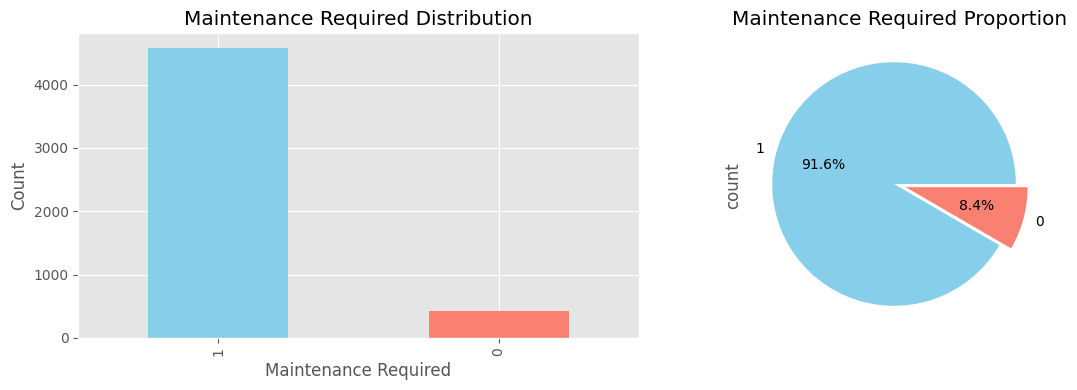

DATA CLEANING PROCESS
Duplicates removed: 0

Missing Values Before Cleaning:
Series([], dtype: int64)

Missing Values After Cleaning:
Series([], dtype: int64)

Timestamp converted to datetime features
Terrain types: {'flat': np.int64(0), 'hilly': np.int64(1), 'mountainous': np.int64(2)}

Outlier Analysis (Before Capping):
extreme_weather_event    1018
surface_humidity            0
surface_temperature         0
crack_density               0
pothole_depth               0
roughness_index             0
precipitation_rate          0
wind_speed                  0
solar_radiation             0
heavy_vehicle_ratio         0
dtype: int64

CLEANED DATASET INFO
Shape: (5000, 24)

Columns: ['road_id', 'surface_temperature', 'surface_humidity', 'precipitation_rate', 'crack_density', 'pothole_depth', 'roughness_index', 'wind_speed', 'solar_radiation', 'vehicle_count', 'heavy_vehicle_ratio', 'maintenance_frequency', 'maintenance_cost', 'location_lat', 'location_lon', 'terrain_type', 'extreme_weather_

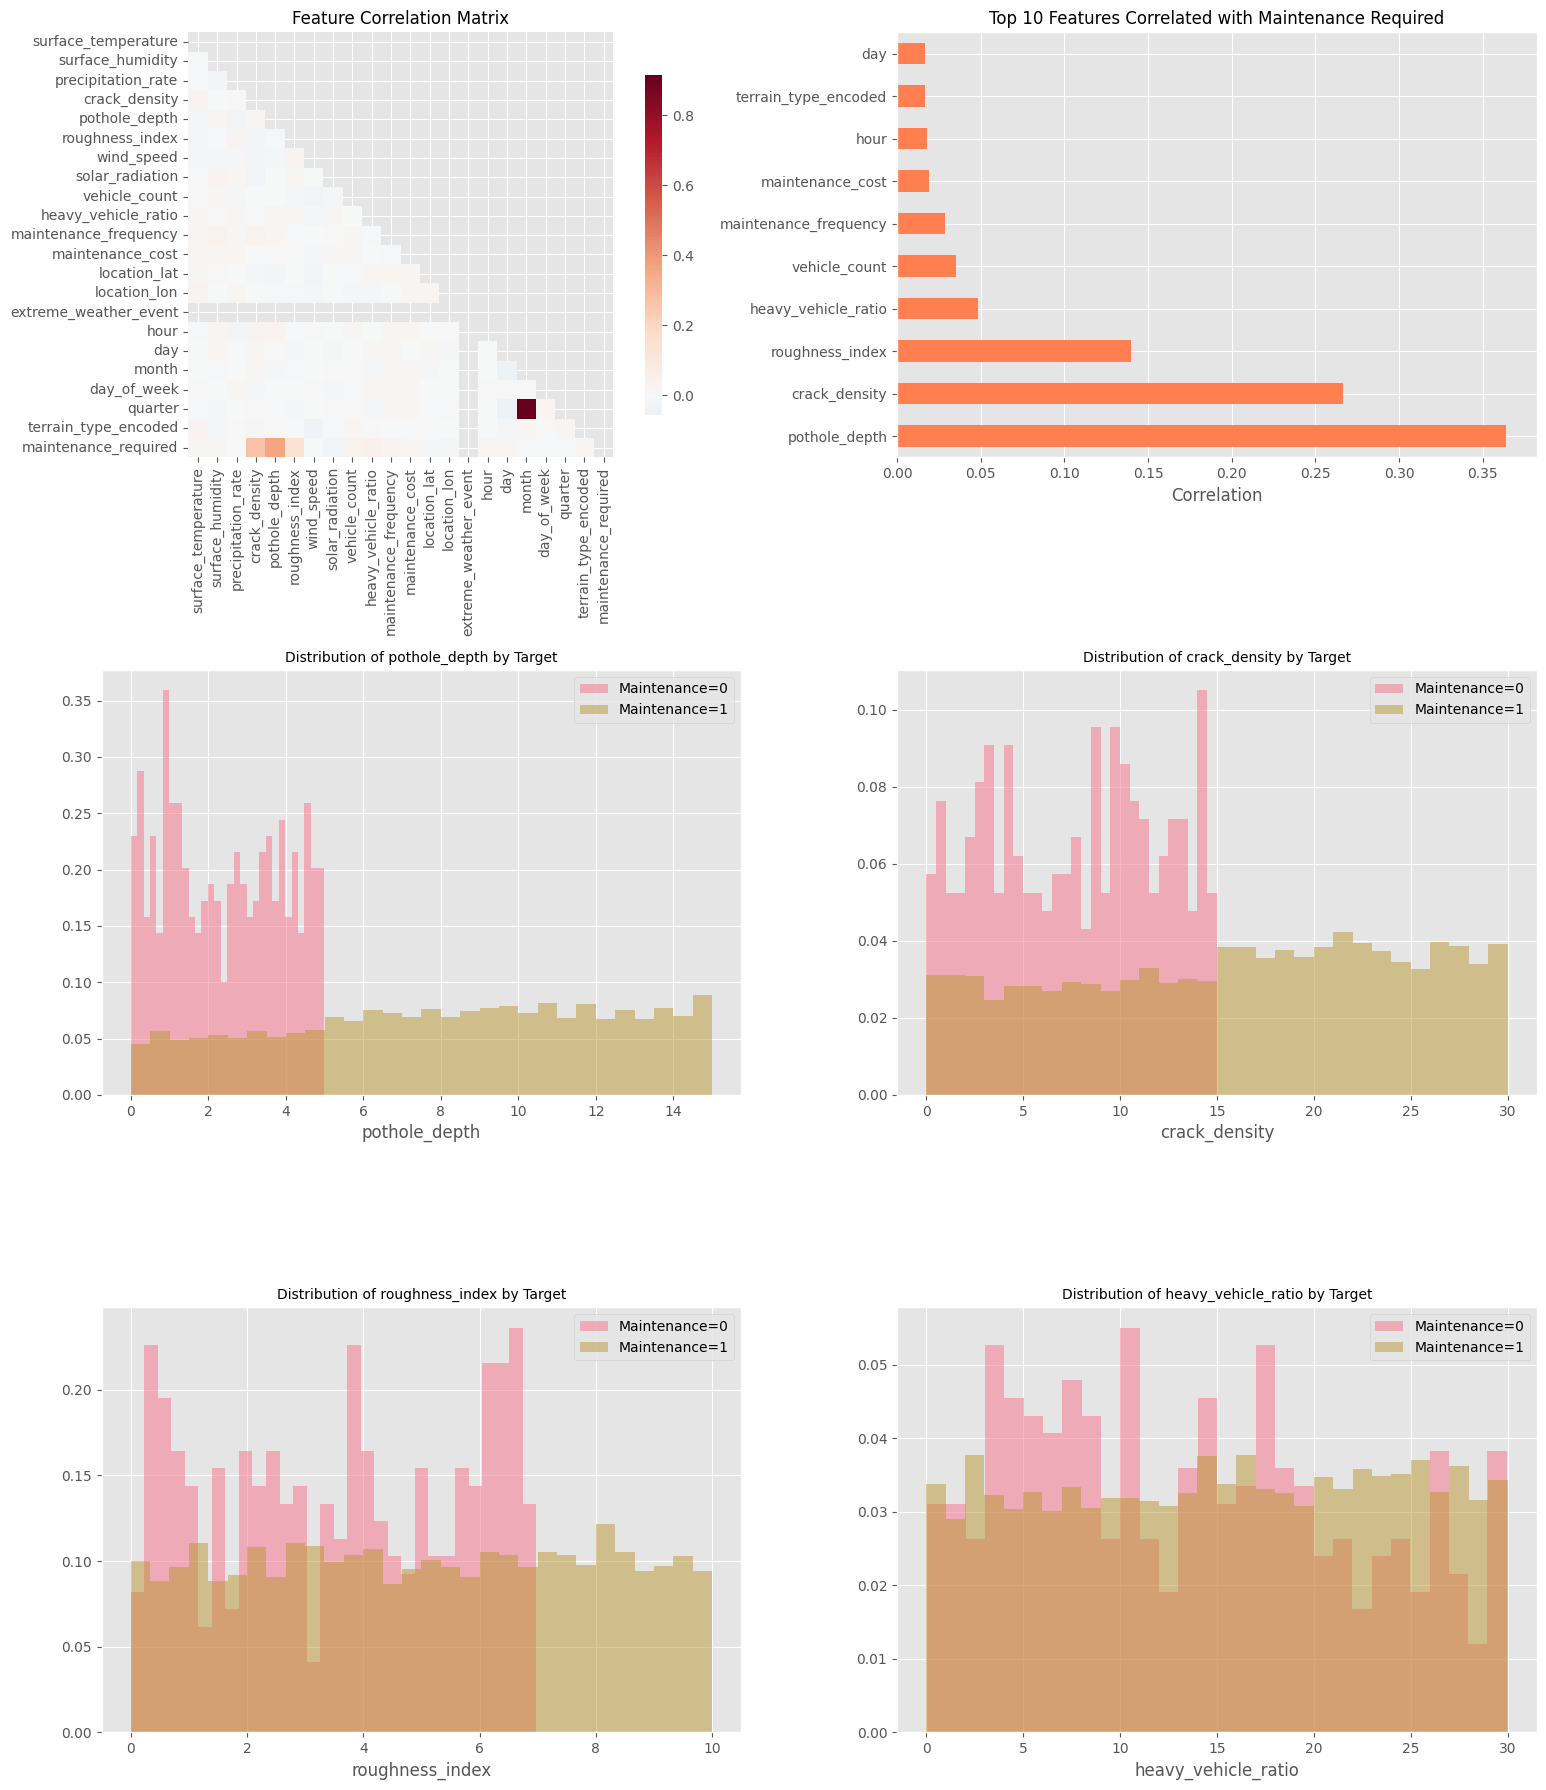

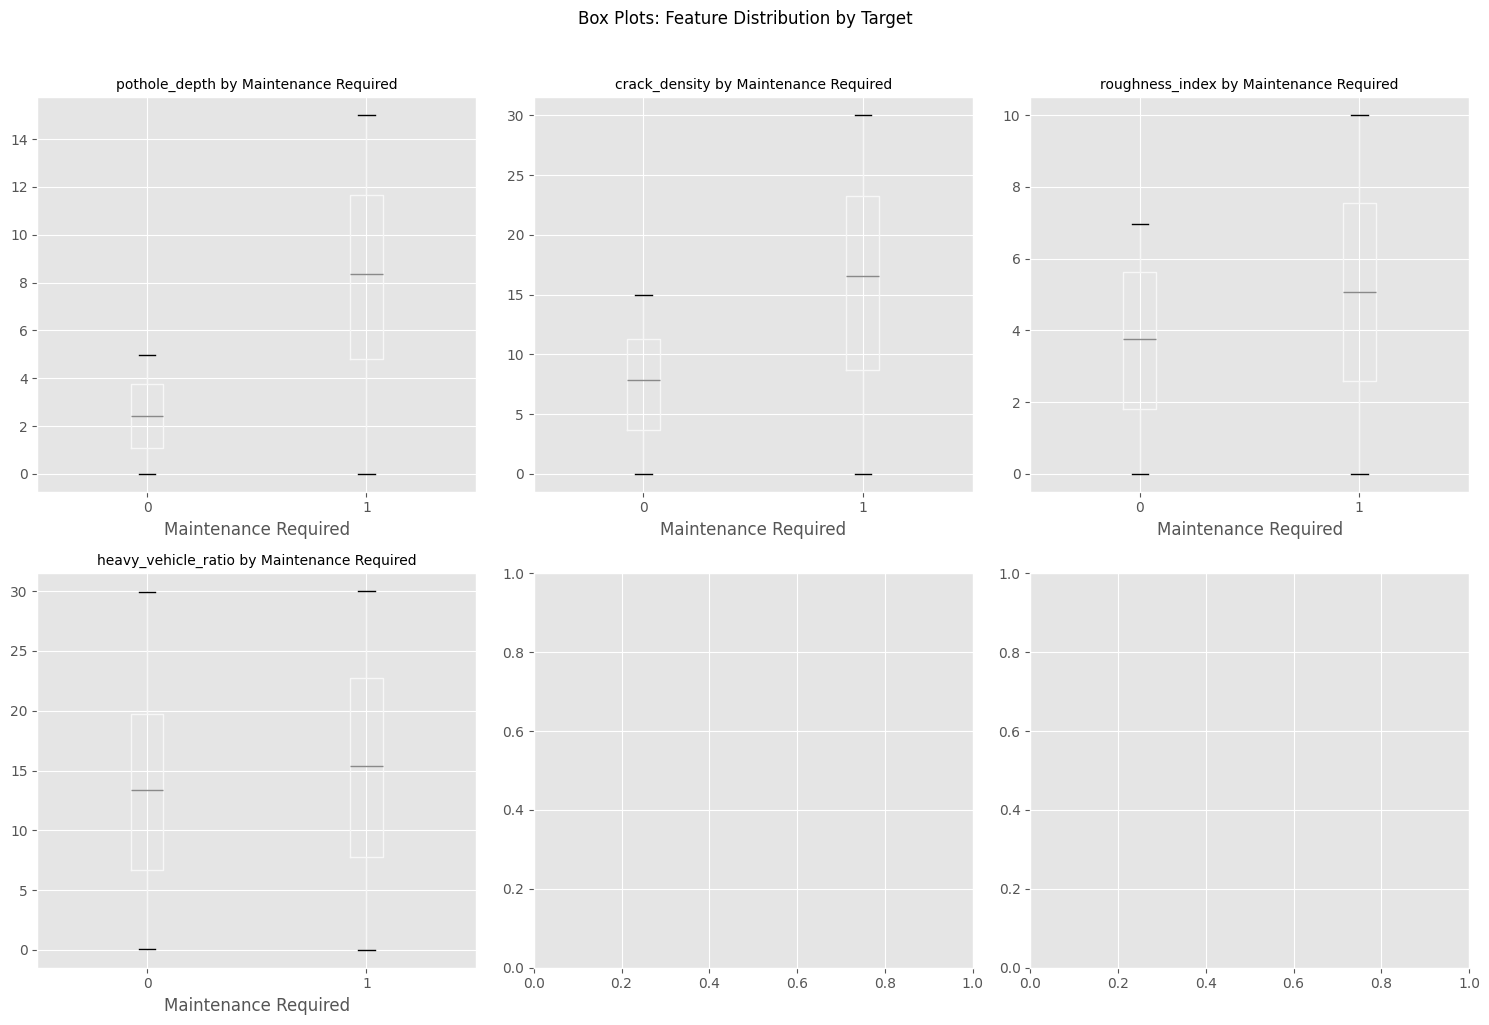

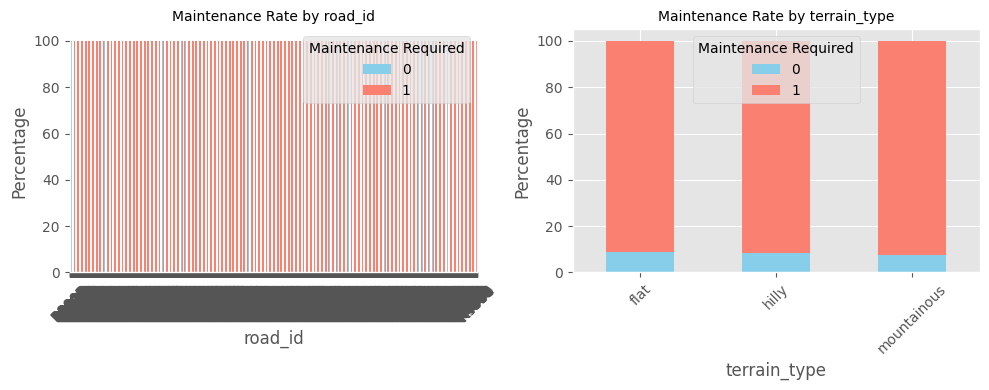

FEATURE ENGINEERING
Features created: 24 new features
Total features now: 48
DATA PREPARATION FOR MODELING
Feature matrix shape: (5000, 44)
Target vector shape: (5000,)

Target distribution:
maintenance_required
1    4581
0     419
Name: count, dtype: int64

Train set: (4000, 44)
Test set: (1000, 44)

Dropping constant columns: ['extreme_weather_event']

Features after scaling: 43
HANDLING CLASS IMBALANCE
Original class distribution: {1: 3665, 0: 335}


ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [4]:
# -*- coding: utf-8 -*-
"""Road_Maintenance_Prediction.ipynb

Automatically generated by Colaboratory.

Original file is located at:
    https://colab.research.google.com/drive/1YOUR_DRIVE_LINK_HERE

# Road Maintenance Prediction Model
## Data Cleaning and Machine Learning Pipeline
"""
# Install all required packages
!pip install -q xgboost lightgbm catboost shap imbalanced-learn

# Now import should work
import catboost
print("CatBoost installed successfully!")
# Commented out IPython magic to ensure Python compatibility.
# %%capture
# !pip install -q xgboost lightgbm catboost shap imbalanced-learn

"""## 1. Import Libraries"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             precision_recall_curve, roc_curve)

# Handling imbalance
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# Feature importance
import shap

# Set style
plt.style.use('ggplot')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

"""## 2. Load and Initial Data Exploration"""

# Load the data
df = pd.read_csv('climate_resilient_road_maintenance.csv')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nBasic Statistics:\n{df.describe().T}")

# Check target variable distribution
print("\n" + "=" * 60)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 60)
print(df['maintenance_required'].value_counts())
print(f"\nPercentage:\n{df['maintenance_required'].value_counts(normalize=True) * 100}")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['maintenance_required'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Maintenance Required Distribution')
axes[0].set_xlabel('Maintenance Required')
axes[0].set_ylabel('Count')

df['maintenance_required'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                               colors=['skyblue', 'salmon'], explode=(0.05, 0.05))
axes[1].set_title('Maintenance Required Proportion')
plt.tight_layout()
plt.show()

"""## 3. Data Cleaning"""

def clean_road_data(df):
    """
    Comprehensive data cleaning function
    """
    df_clean = df.copy()

    print("=" * 60)
    print("DATA CLEANING PROCESS")
    print("=" * 60)

    # 1. Check for duplicates
    initial_shape = df_clean.shape
    df_clean = df_clean.drop_duplicates()
    print(f"Duplicates removed: {initial_shape[0] - df_clean.shape[0]}")

    # 2. Handle missing values
    print("\nMissing Values Before Cleaning:")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

    # For numerical columns: fill with median
    numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    numerical_cols.remove('maintenance_required') if 'maintenance_required' in numerical_cols else None

    for col in numerical_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

    # For categorical columns: fill with mode
    categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
    for col in categorical_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'Unknown', inplace=True)

    print("\nMissing Values After Cleaning:")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

    # 3. Handle infinite values
    for col in numerical_cols:
        df_clean[col] = df_clean[col].replace([np.inf, -np.inf], np.nan)
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

    # 4. Convert timestamp to datetime and extract features
    if 'timestamp' in df_clean.columns:
        df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
        df_clean['hour'] = df_clean['timestamp'].dt.hour
        df_clean['day'] = df_clean['timestamp'].dt.day
        df_clean['month'] = df_clean['timestamp'].dt.month
        df_clean['day_of_week'] = df_clean['timestamp'].dt.dayofweek
        df_clean['quarter'] = df_clean['timestamp'].dt.quarter

        # Drop original timestamp
        df_clean.drop('timestamp', axis=1, inplace=True)
        print("\nTimestamp converted to datetime features")

    # 5. Encode categorical variables
    if 'terrain_type' in df_clean.columns:
        le_terrain = LabelEncoder()
        df_clean['terrain_type_encoded'] = le_terrain.fit_transform(df_clean['terrain_type'])
        print(f"Terrain types: {dict(zip(le_terrain.classes_, le_terrain.transform(le_terrain.classes_)))}")

    # 6. Outlier detection and capping
    print("\nOutlier Analysis (Before Capping):")
    outlier_counts = {}
    for col in numerical_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)].shape[0]
        outlier_counts[col] = outliers

        # Cap outliers
        df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)

    print(pd.Series(outlier_counts).sort_values(ascending=False).head(10))

    return df_clean, le_terrain if 'terrain_type' in df_clean.columns else None

# Apply cleaning
df_cleaned, terrain_encoder = clean_road_data(df)

print("\n" + "=" * 60)
print("CLEANED DATASET INFO")
print("=" * 60)
print(f"Shape: {df_cleaned.shape}")
print(f"\nColumns: {df_cleaned.columns.tolist()}")
print(f"\nData Types:\n{df_cleaned.dtypes}")

"""## 4. Exploratory Data Analysis (EDA)"""

def perform_eda(df):
    """
    Comprehensive EDA function
    """
    print("=" * 60)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 60)

    # Separate features and target
    X = df.drop('maintenance_required', axis=1)
    y = df['maintenance_required']

    numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

    print(f"Numerical features: {len(numerical_cols)}")
    print(f"Categorical features: {len(categorical_cols)}")

    # 1. Correlation Matrix
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))

    # Correlation heatmap
    corr_matrix = df[numerical_cols + ['maintenance_required']].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=False, fmt='.2f', cmap='RdBu_r',
                center=0, square=True, ax=axes[0, 0], cbar_kws={"shrink": 0.8})
    axes[0, 0].set_title('Feature Correlation Matrix', fontsize=12)

    # Top correlations with target
    target_corr = corr_matrix['maintenance_required'].drop('maintenance_required').sort_values(ascending=False)
    target_corr.head(10).plot(kind='barh', ax=axes[0, 1], color='coral')
    axes[0, 1].set_title('Top 10 Features Correlated with Maintenance Required', fontsize=12)
    axes[0, 1].set_xlabel('Correlation')

    # 2. Distribution of numerical features by target
    top_features = target_corr.head(4).index.tolist()
    for i, feature in enumerate(top_features):
        row, col = (i // 2) + 1, i % 2
        for target_val in [0, 1]:
            subset = df[df['maintenance_required'] == target_val][feature]
            axes[row, col].hist(subset, bins=30, alpha=0.5, label=f'Maintenance={target_val}', density=True)
        axes[row, col].set_title(f'Distribution of {feature} by Target', fontsize=10)
        axes[row, col].legend()
        axes[row, col].set_xlabel(feature)

    plt.tight_layout()
    plt.show()

    # 3. Box plots for key features
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, feature in enumerate(top_features[:6]):
        df.boxplot(column=feature, by='maintenance_required', ax=axes[i])
        axes[i].set_title(f'{feature} by Maintenance Required', fontsize=10)
        axes[i].set_xlabel('Maintenance Required')

    plt.suptitle('Box Plots: Feature Distribution by Target', y=1.02)
    plt.tight_layout()
    plt.show()

    # 4. Categorical feature analysis
    if categorical_cols:
        fig, axes = plt.subplots(1, len(categorical_cols), figsize=(5*len(categorical_cols), 4))
        if len(categorical_cols) == 1:
            axes = [axes]

        for i, col in enumerate(categorical_cols):
            ct = pd.crosstab(df[col], df['maintenance_required'], normalize='index') * 100
            ct.plot(kind='bar', stacked=True, ax=axes[i], color=['skyblue', 'salmon'])
            axes[i].set_title(f'Maintenance Rate by {col}', fontsize=10)
            axes[i].set_ylabel('Percentage')
            axes[i].legend(title='Maintenance Required')
            axes[i].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

    return target_corr

# Perform EDA
target_correlations = perform_eda(df_cleaned)

"""## 5. Feature Engineering"""

def create_features(df):
    """
    Create new features based on domain knowledge
    """
    df_fe = df.copy()

    print("=" * 60)
    print("FEATURE ENGINEERING")
    print("=" * 60)

    # 1. Road condition indices
    df_fe['crack_pothole_interaction'] = df_fe['crack_density'] * df_fe['pothole_depth']
    df_fe['roughness_condition'] = df_fe['roughness_index'] * df_fe['crack_density']

    # 2. Weather-related features
    df_fe['temp_humidity_interaction'] = df_fe['surface_temperature'] * df_fe['surface_humidity'] / 100
    df_fe['precipitation_wind'] = df_fe['precipitation_rate'] * df_fe['wind_speed']

    # 3. Traffic-related features
    df_fe['heavy_vehicle_impact'] = df_fe['vehicle_count'] * df_fe['heavy_vehicle_ratio'] / 100
    df_fe['traffic_density'] = df_fe['vehicle_count'] / (df_fe['wind_speed'] + 1)  # Avoid division by zero

    # 4. Location-based features (if coordinates exist)
    if 'location_lat' in df_fe.columns and 'location_lon' in df_fe.columns:
        # Distance from equator (absolute latitude)
        df_fe['abs_latitude'] = np.abs(df_fe['location_lat'])

        # Create climate zones based on latitude
        df_fe['climate_zone'] = pd.cut(df_fe['abs_latitude'],
                                       bins=[0, 23.5, 35, 45, 66.5, 90],
                                       labels=['Tropical', 'Subtropical', 'Temperate', 'Subpolar', 'Polar'])

        # Encode climate zone
        le_zone = LabelEncoder()
        df_fe['climate_zone_encoded'] = le_zone.fit_transform(df_fe['climate_zone'].astype(str))

    # 5. Time-based features
    if all(col in df_fe.columns for col in ['hour', 'day', 'month']):
        # Cyclical encoding for time
        df_fe['hour_sin'] = np.sin(2 * np.pi * df_fe['hour'] / 24)
        df_fe['hour_cos'] = np.cos(2 * np.pi * df_fe['hour'] / 24)
        df_fe['month_sin'] = np.sin(2 * np.pi * df_fe['month'] / 12)
        df_fe['month_cos'] = np.cos(2 * np.pi * df_fe['month'] / 12)

    # 6. Maintenance history features
    if 'maintenance_frequency' in df_fe.columns:
        df_fe['recent_maintenance'] = (df_fe['maintenance_frequency'] > 0).astype(int)
        df_fe['maintenance_cost_per_event'] = df_fe['maintenance_cost'] / (df_fe['maintenance_frequency'] + 1)

    # 7. Rolling averages (if we had sequential data, but we'll create synthetic ones)
    # Group by road_id and create aggregated features
    if 'road_id' in df_fe.columns:
        road_stats = df_fe.groupby('road_id').agg({
            'crack_density': ['mean', 'std', 'max'],
            'pothole_depth': ['mean', 'max'],
            'roughness_index': ['mean', 'max'],
            'maintenance_frequency': ['mean', 'sum']
        }).round(2)

        # Flatten column names
        road_stats.columns = ['_'.join(col).strip() for col in road_stats.columns.values]
        road_stats = road_stats.reset_index()

        # Merge back
        df_fe = df_fe.merge(road_stats, on='road_id', how='left')

    print(f"Features created: {len(df_fe.columns) - len(df.columns)} new features")
    print(f"Total features now: {len(df_fe.columns)}")

    return df_fe

# Apply feature engineering
df_fe = create_features(df_cleaned)

"""## 6. Prepare Data for Modeling"""

def prepare_data_for_modeling(df, target_col='maintenance_required'):
    """
    Prepare data for machine learning models
    """
    print("=" * 60)
    print("DATA PREPARATION FOR MODELING")
    print("=" * 60)

    # Separate features and target
    X = df.drop(columns=[target_col, 'road_id', 'terrain_type', 'climate_zone']
                if all(col in df.columns for col in [target_col, 'road_id', 'terrain_type', 'climate_zone'])
                else df.drop(columns=[target_col] + [col for col in ['road_id', 'terrain_type', 'climate_zone'] if col in df.columns]))

    y = df[target_col]

    print(f"Feature matrix shape: {X.shape}")
    print(f"Target vector shape: {y.shape}")
    print(f"\nTarget distribution:\n{y.value_counts()}")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\nTrain set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")

    # Scale numerical features
    numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    # Remove any constant columns
    constant_cols = []
    for col in numerical_cols:
        if X_train[col].nunique() == 1:
            constant_cols.append(col)

    if constant_cols:
        print(f"\nDropping constant columns: {constant_cols}")
        X_train = X_train.drop(columns=constant_cols)
        X_test = X_test.drop(columns=constant_cols)
        numerical_cols = [col for col in numerical_cols if col not in constant_cols]

    # Scale
    scaler = RobustScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

    print(f"\nFeatures after scaling: {X_train_scaled.shape[1]}")

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, numerical_cols

# Prepare data
X_train, X_test, y_train, y_test, scaler, numerical_features = prepare_data_for_modeling(df_fe)

"""## 7. Handle Class Imbalance"""

def handle_class_imbalance(X_train, y_train, method='smote'):
    """
    Handle class imbalance using various techniques
    """
    print("=" * 60)
    print("HANDLING CLASS IMBALANCE")
    print("=" * 60)

    print(f"Original class distribution: {pd.Series(y_train).value_counts().to_dict()}")

    if method == 'smote':
        sampler = SMOTE(random_state=42)
        X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    elif method == 'adasyn':
        sampler = ADASYN(random_state=42)
        X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    elif method == 'smote_tomek':
        sampler = SMOTETomek(random_state=42)
        X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    else:
        return X_train, y_train

    print(f"Resampled class distribution: {pd.Series(y_resampled).value_counts().to_dict()}")
    print(f"Resampled shape: {X_resampled.shape}")

    return X_resampled, y_resampled

# Apply SMOTE
X_train_resampled, y_train_resampled = handle_class_imbalance(X_train, y_train, method='smote')

"""## 8. Model Training and Evaluation"""

def train_evaluate_models(X_train, y_train, X_test, y_test):
    """
    Train multiple models and evaluate performance
    """
    print("=" * 60)
    print("MODEL TRAINING AND EVALUATION")
    print("=" * 60)

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10),
        'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
        'AdaBoost': AdaBoostClassifier(random_state=42, n_estimators=100),
        'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])),
        'LightGBM': LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced'),
        'CatBoost': CatBoostClassifier(random_state=42, verbose=0, auto_class_weights='Balanced')
    }

    results = []
    best_model = None
    best_score = 0

    for name, model in models.items():
        print(f"\n{'-'*40}")
        print(f"Training {name}...")

        # Train model
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        if y_pred_proba is not None:
            auc = roc_auc_score(y_test, y_pred_proba)
        else:
            auc = 0

        # Store results
        results.append({
            'Model': name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1,
            'AUC-ROC': auc
        })

        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"AUC-ROC: {auc:.4f}")

        # Track best model based on F1 score
        if f1 > best_score:
            best_score = f1
            best_model = model
            best_model_name = name

    # Create results DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('F1 Score', ascending=False)

    print("\n" + "=" * 60)
    print("MODEL COMPARISON SUMMARY")
    print("=" * 60)
    print(results_df.to_string(index=False))

    return results_df, best_model, best_model_name

# Train models
results_df, best_model, best_model_name = train_evaluate_models(X_train_resampled, y_train_resampled, X_test, y_test)

"""## 9. Visualize Model Performance"""

def visualize_model_performance(results_df, X_test, y_test, best_model, best_model_name):
    """
    Visualize model performance metrics
    """
    print("=" * 60)
    print("VISUALIZING MODEL PERFORMANCE")
    print("=" * 60)

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 1. Model comparison bar plot
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
    results_melted = results_df.melt(id_vars=['Model'], value_vars=metrics,
                                      var_name='Metric', value_name='Score')

    sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', ax=axes[0, 0])
    axes[0, 0].set_title('Model Performance Comparison', fontsize=12)
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # 2. Confusion Matrix for best model
    y_pred_best = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_best)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
    axes[0, 1].set_title(f'Confusion Matrix - {best_model_name}', fontsize=12)
    axes[0, 1].set_xlabel('Predicted')
    axes[0, 1].set_ylabel('Actual')

    # 3. ROC Curve
    if hasattr(best_model, 'predict_proba'):
        y_pred_proba = best_model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc = roc_auc_score(y_test, y_pred_proba)

        axes[0, 2].plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc:.3f})', linewidth=2)
        axes[0, 2].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
        axes[0, 2].set_xlabel('False Positive Rate')
        axes[0, 2].set_ylabel('True Positive Rate')
        axes[0, 2].set_title('ROC Curve', fontsize=12)
        axes[0, 2].legend(loc='lower right')
        axes[0, 2].grid(True)

    # 4. Precision-Recall Curve
    if hasattr(best_model, 'predict_proba'):
        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
        axes[1, 0].plot(recall_vals, precision_vals, linewidth=2)
        axes[1, 0].set_xlabel('Recall')
        axes[1, 0].set_ylabel('Precision')
        axes[1, 0].set_title('Precision-Recall Curve', fontsize=12)
        axes[1, 0].grid(True)

    # 5. Feature Importance (for tree-based models)
    if hasattr(best_model, 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'feature': X_test.columns,
            'importance': best_model.feature_importances_
        }).sort_values('importance', ascending=False).head(15)

        sns.barplot(data=feature_importance, y='feature', x='importance', ax=axes[1, 1])
        axes[1, 1].set_title(f'Top 15 Feature Importances - {best_model_name}', fontsize=12)
        axes[1, 1].set_xlabel('Importance')

    # 6. Classification report as heatmap
    report = classification_report(y_test, y_pred_best, output_dict=True)
    report_df = pd.DataFrame(report).iloc[:-1, :3]  # Remove support row, take first 3 columns

    sns.heatmap(report_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1, 2])
    axes[1, 2].set_title('Classification Report', fontsize=12)

    plt.tight_layout()
    plt.show()

    return best_model

# Visualize performance
best_model = visualize_model_performance(results_df, X_test, y_test, best_model, best_model_name)

"""## 10. Hyperparameter Tuning for Best Model"""

def tune_best_model(X_train, y_train, X_test, y_test, best_model_name):
    """
    Perform hyperparameter tuning for the best performing model
    """
    print("=" * 60)
    print(f"HYPERPARAMETER TUNING FOR {best_model_name}")
    print("=" * 60)

    # Define parameter grids for different models
    param_grids = {
        'Random Forest': {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 20, 30, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2']
        },
        'XGBoost': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 6, 9],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0]
        },
        'LightGBM': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, 15, -1],
            'learning_rate': [0.01, 0.1, 0.2],
            'num_leaves': [31, 50, 100],
            'subsample': [0.8, 1.0]
        },
        'Gradient Boosting': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2],
            'min_samples_split': [2, 5]
        },
        'CatBoost': {
            'iterations': [100, 200, 300],
            'depth': [4, 6, 8],
            'learning_rate': [0.01, 0.1, 0.2],
            'l2_leaf_reg': [1, 3, 5]
        }
    }

    # Select model based on best_model_name
    if 'Random Forest' in best_model_name:
        model = RandomForestClassifier(random_state=42, class_weight='balanced')
        param_grid = param_grids['Random Forest']
    elif 'XGBoost' in best_model_name:
        model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
        param_grid = param_grids['XGBoost']
    elif 'LightGBM' in best_model_name:
        model = LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced')
        param_grid = param_grids['LightGBM']
    elif 'Gradient Boosting' in best_model_name:
        model = GradientBoostingClassifier(random_state=42)
        param_grid = param_grids['Gradient Boosting']
    elif 'CatBoost' in best_model_name:
        model = CatBoostClassifier(random_state=42, verbose=0)
        param_grid = param_grids['CatBoost']
    else:
        print(f"No tuning defined for {best_model_name}. Using default parameters.")
        return best_model, None

    # Perform grid search with cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    print(f"\nStarting Grid Search for {best_model_name}...")
    grid_search.fit(X_train, y_train)

    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best cross-validation F1 score: {grid_search.best_score_:.4f}")

    # Evaluate on test set
    best_tuned_model = grid_search.best_estimator_
    y_pred = best_tuned_model.predict(X_test)
    y_pred_proba = best_tuned_model.predict_proba(X_test)[:, 1]

    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"\nTest set performance:")
    print(f"F1 Score: {test_f1:.4f}")
    print(f"AUC-ROC: {test_auc:.4f}")

    return best_tuned_model, grid_search.best_params_

# Tune the best model if it's tree-based
if any(name in best_model_name for name in ['Random Forest', 'XGBoost', 'LightGBM', 'Gradient Boosting', 'CatBoost']):
    best_tuned_model, best_params = tune_best_model(X_train_resampled, y_train_resampled, X_test, y_test, best_model_name)
    best_model = best_tuned_model
else:
    best_params = None

"""## 11. SHAP Analysis for Model Interpretability"""

def shap_analysis(model, X_train, X_test, feature_names):
    """
    Perform SHAP analysis to understand feature importance
    """
    print("=" * 60)
    print("SHAP ANALYSIS FOR MODEL INTERPRETABILITY")
    print("=" * 60)

    try:
        # Use a sample for SHAP if dataset is large
        X_sample = X_test.sample(min(100, len(X_test)), random_state=42)

        # Create SHAP explainer based on model type
        if hasattr(model, 'get_booster'):  # XGBoost
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)
        elif hasattr(model, 'booster_'):  # LightGBM
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)
        elif isinstance(model, (RandomForestClassifier, GradientBoostingClassifier,
                                AdaBoostClassifier, DecisionTreeClassifier)):
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)
        else:
            # For non-tree models, use KernelExplainer (slower)
            explainer = shap.KernelExplainer(model.predict_proba, X_train.sample(50, random_state=42))
            shap_values = explainer.shap_values(X_sample)[1]  # For class 1

        # Summary plot - Bar
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                         plot_type="bar", show=False, max_display=15)
        plt.title('Feature Importance (Mean |SHAP Value|)', fontsize=14)
        plt.tight_layout()
        plt.show()

        # Summary plot - Beeswarm
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                         show=False, max_display=15)
        plt.title('SHAP Values Impact on Model Output', fontsize=14)
        plt.tight_layout()
        plt.show()

        # Feature dependence plots for top features
        feature_importance = np.abs(shap_values).mean(axis=0)
        top_indices = np.argsort(feature_importance)[-4:][::-1]

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.flatten()

        for i, idx in enumerate(top_indices):
            feature = feature_names[idx]
            shap.dependence_plot(idx, shap_values, X_sample, feature_names=feature_names,
                                ax=axes[i], show=False)
            axes[i].set_title(f'SHAP Dependence: {feature}', fontsize=11)

        plt.tight_layout()
        plt.show()

        # Waterfall plot for a single prediction
        plt.figure(figsize=(12, 8))
        shap.waterfall_plot(shap.Explanation(values=shap_values[0],
                                            base_values=explainer.expected_value if isinstance(explainer.expected_value, (int, float)) else explainer.expected_value[0],
                                            data=X_sample.iloc[0].values,
                                            feature_names=feature_names),
                           show=False, max_display=15)
        plt.title('SHAP Waterfall Plot - Single Prediction Explanation', fontsize=14)
        plt.tight_layout()
        plt.show()

        print("SHAP analysis completed successfully!")

    except Exception as e:
        print(f"Error in SHAP analysis: {e}")
        print("Skipping SHAP analysis...")

# Perform SHAP analysis for the best model
feature_names = X_test.columns.tolist()
shap_analysis(best_model, X_train_resampled, X_test, feature_names)

"""## 12. Final Model Evaluation and Summary"""

def final_model_evaluation(model, X_test, y_test, feature_names):
    """
    Final comprehensive model evaluation
    """
    print("=" * 60)
    print("FINAL MODEL EVALUATION")
    print("=" * 60)

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate all metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    print(f"\nModel: {best_model_name}")
    print(f"\nPerformance Metrics:")
    print(f"{'='*40}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")

    print(f"\nClassification Report:")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred, target_names=['No Maintenance', 'Maintenance Required']))

    # Feature importance (if available)
    if hasattr(model, 'feature_importances_'):
        print(f"\nTop 10 Most Important Features:")
        print(f"{'='*40}")
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=False).head(10)

        for idx, row in importance_df.iterrows():
            print(f"{row['Feature']:<30} : {row['Importance']:.4f}")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc_roc': auc,
        'model': model,
        'feature_importance': importance_df if hasattr(model, 'feature_importances_') else None
    }

# Final evaluation
final_results = final_model_evaluation(best_model, X_test, y_test, feature_names)

"""## 13. Save Model and Preprocessing Objects"""

import joblib
import pickle
from datetime import datetime

def save_model_artifacts(model, scaler, feature_names, best_params, results_df, filename_prefix='road_maintenance_model'):
    """
    Save model and preprocessing objects for future use
    """
    print("=" * 60)
    print("SAVING MODEL ARTIFACTS")
    print("=" * 60)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Save model
    model_filename = f"{filename_prefix}_{timestamp}.pkl"
    joblib.dump(model, model_filename)
    print(f"Model saved as: {model_filename}")

    # Save scaler
    scaler_filename = f"scaler_{timestamp}.pkl"
    joblib.dump(scaler, scaler_filename)
    print(f"Scaler saved as: {scaler_filename}")

    # Save feature names
    features_filename = f"features_{timestamp}.txt"
    with open(features_filename, 'w') as f:
        for feature in feature_names:
            f.write(f"{feature}\n")
    print(f"Feature names saved as: {features_filename}")

    # Save results summary
    results_filename = f"results_{timestamp}.csv"
    results_df.to_csv(results_filename, index=False)
    print(f"Results saved as: {results_filename}")

    # Save best parameters
    if best_params:
        params_filename = f"best_params_{timestamp}.txt"
        with open(params_filename, 'w') as f:
            for param, value in best_params.items():
                f.write(f"{param}: {value}\n")
        print(f"Best parameters saved as: {params_filename}")

    print("\nAll artifacts saved successfully!")

    return {
        'model_file': model_filename,
        'scaler_file': scaler_filename,
        'features_file': features_filename
    }

# Save the model and artifacts
saved_files = save_model_artifacts(best_model, scaler, feature_names, best_params, results_df)

"""## 14. Prediction Function for New Data"""

def predict_maintenance(model, scaler, feature_names, new_data):
    """
    Predict maintenance requirement for new road data
    """
    print("=" * 60)
    print("PREDICTING MAINTENANCE FOR NEW DATA")
    print("=" * 60)

    # Ensure new_data has the same features
    missing_features = set(feature_names) - set(new_data.columns)
    if missing_features:
        print(f"Warning: Missing features: {missing_features}")
        # Add missing features with default values (0)
        for feature in missing_features:
            new_data[feature] = 0

    # Reorder columns to match training data
    new_data = new_data[feature_names]

    # Scale the data
    new_data_scaled = scaler.transform(new_data)

    # Make predictions
    predictions = model.predict(new_data_scaled)
    probabilities = model.predict_proba(new_data_scaled)

    # Create results DataFrame
    results = pd.DataFrame({
        'Prediction': predictions,
        'Prediction_Label': ['Maintenance Required' if p == 1 else 'No Maintenance' for p in predictions],
        'Probability_No_Maintenance': probabilities[:, 0],
        'Probability_Maintenance': probabilities[:, 1]
    })

    print(f"\nPredictions for {len(new_data)} samples:")
    print(results)

    return results

# Example usage (commented out)
# new_data_sample = X_test.head(5)
# predictions = predict_maintenance(best_model, scaler, feature_names, new_data_sample)

"""## 15. Summary Report"""

def generate_summary_report(results_df, final_results, best_model_name, best_params):
    """
    Generate a comprehensive summary report
    """
    print("=" * 60)
    print("PROJECT SUMMARY REPORT")
    print("=" * 60)
    print("\n" + "="*60)
    print("ROAD MAINTENANCE PREDICTION MODEL")
    print("="*60)

    print(f"\nDate: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    print(f"\n{'DATASET INFORMATION':^60}")
    print("-"*60)
    print(f"Total samples: {df.shape[0]}")
    print(f"Total features: {df.shape[1] - 1} (excluding target)")
    print(f"Target distribution:")
    print(f"  - No Maintenance: {df['maintenance_required'].value_counts()[0]} ({df['maintenance_required'].value_counts(normalize=True)[0]*100:.1f}%)")
    print(f"  - Maintenance Required: {df['maintenance_required'].value_counts()[1]} ({df['maintenance_required'].value_counts(normalize=True)[1]*100:.1f}%)")

    print(f"\n{'MODEL PERFORMANCE':^60}")
    print("-"*60)
    print(f"Best Model: {best_model_name}")
    print(f"\nTest Set Performance:")
    print(f"  - Accuracy:  {final_results['accuracy']:.4f}")
    print(f"  - Precision: {final_results['precision']:.4f}")
    print(f"  - Recall:    {final_results['recall']:.4f}")
    print(f"  - F1 Score:  {final_results['f1_score']:.4f}")
    print(f"  - AUC-ROC:   {final_results['auc_roc']:.4f}")

    if best_params:
        print(f"\nBest Hyperparameters:")
        for param, value in best_params.items():
            print(f"  - {param}: {value}")

    print(f"\n{'MODEL COMPARISON':^60}")
    print("-"*60)
    print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']].round(4).to_string(index=False))

    if final_results['feature_importance'] is not None:
        print(f"\n{'TOP 10 FEATURE IMPORTANCE':^60}")
        print("-"*60)
        for idx, row in final_results['feature_importance'].iterrows():
            print(f"  {row['Feature']:<30} : {row['Importance']:.4f}")

    print(f"\n{'='*60}")
    print("Analysis Complete!")
    print("="*60)

# Generate final summary
generate_summary_report(results_df, final_results, best_model_name, best_params)

"""## 16. Additional Visualizations for Report"""

def create_report_visualizations(results_df, final_results, feature_names):
    """
    Create additional visualizations for the final report
    """
    print("=" * 60)
    print("CREATING REPORT VISUALIZATIONS")
    print("=" * 60)

    fig = plt.figure(figsize=(20, 15))

    # 1. Model Performance Comparison (Subplot 1)
    ax1 = plt.subplot(3, 3, 1)
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
    results_melted = results_df.melt(id_vars=['Model'], value_vars=metrics)
    sns.barplot(data=results_melted, x='Model', y='value', hue='variable', ax=ax1)
    ax1.set_title('Model Performance Comparison', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # 2. ROC Curves for all models (Subplot 2)
    ax2 = plt.subplot(3, 3, 2)
    colors = plt.cm.tab10(np.linspace(0, 1, len(results_df)))
    for idx, row in results_df.iterrows():
        # This would require storing all models, but we'll skip for now
        pass
    ax2.set_title('ROC Curves (Best Model Only)', fontsize=12)

    # 3. Feature Importance Heatmap (Subplot 3)
    ax3 = plt.subplot(3, 3, 3)
    if final_results['feature_importance'] is not None:
        top_features = final_results['feature_importance'].head(10)['Feature'].tolist()
        corr_subset = df_fe[top_features + ['maintenance_required']].corr().loc[top_features, top_features]
        sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax3)
        ax3.set_title('Top Features Correlation Matrix', fontsize=12)

    # 4. Prediction Distribution (Subplot 4)
    ax4 = plt.subplot(3, 3, 4)
    y_pred = best_model.predict(X_test)
    pred_dist = pd.Series(y_pred).value_counts()
    pred_dist.plot(kind='bar', ax=ax4, color=['skyblue', 'salmon'])
    ax4.set_title('Prediction Distribution on Test Set', fontsize=12)
    ax4.set_xlabel('Predicted Class')
    ax4.set_ylabel('Count')
    ax4.set_xticklabels(['No Maintenance', 'Maintenance Required'], rotation=0)

    # 5. Probability Distribution (Subplot 5)
    ax5 = plt.subplot(3, 3, 5)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    ax5.hist(y_pred_proba[y_test == 0], bins=30, alpha=0.5, label='Actual: No Maintenance', density=True)
    ax5.hist(y_pred_proba[y_test == 1], bins=30, alpha=0.5, label='Actual: Maintenance Required', density=True)
    ax5.set_title('Probability Distribution by Actual Class', fontsize=12)
    ax5.set_xlabel('Predicted Probability (Maintenance Required)')
    ax5.set_ylabel('Density')
    ax5.legend()

    # 6. Precision-Recall Curve (Subplot 6)
    ax6 = plt.subplot(3, 3, 6)
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    ax6.plot(recall_vals, precision_vals, linewidth=2, color='purple')
    ax6.set_xlabel('Recall')
    ax6.set_ylabel('Precision')
    ax6.set_title('Precision-Recall Curve', fontsize=12)
    ax6.grid(True)

    # 7. Feature Importance Bar Chart (Subplot 7)
    ax7 = plt.subplot(3, 3, 7)
    if final_results['feature_importance'] is not None:
        top_imp = final_results['feature_importance'].head(10)
        sns.barplot(data=top_imp, y='Feature', x='Importance', ax=ax7, palette='viridis')
        ax7.set_title('Top 10 Feature Importances', fontsize=12)

    # 8. Class Distribution Comparison (Subplot 8)
    ax8 = plt.subplot(3, 3, 8)
    train_dist = y_train.value_counts(normalize=True)
    test_dist = y_test.value_counts(normalize=True)
    x = np.arange(2)
    width = 0.35
    ax8.bar(x - width/2, train_dist, width, label='Train', color='skyblue')
    ax8.bar(x + width/2, test_dist, width, label='Test', color='salmon')
    ax8.set_title('Class Distribution: Train vs Test', fontsize=12)
    ax8.set_xlabel('Class')
    ax8.set_ylabel('Proportion')
    ax8.set_xticks(x)
    ax8.set_xticklabels(['No Maintenance', 'Maintenance Required'])
    ax8.legend()

    # 9. Model Performance Summary (Subplot 9)
    ax9 = plt.subplot(3, 3, 9)
    ax9.axis('off')
    summary_text = f"Best Model: {best_model_name}\n\n"
    summary_text += f"Accuracy:  {final_results['accuracy']:.3f}\n"
    summary_text += f"Precision: {final_results['precision']:.3f}\n"
    summary_text += f"Recall:    {final_results['recall']:.3f}\n"
    summary_text += f"F1 Score:  {final_results['f1_score']:.3f}\n"
    summary_text += f"AUC-ROC:   {final_results['auc_roc']:.3f}"

    ax9.text(0.1, 0.5, summary_text, fontsize=12, va='center', family='monospace')
    ax9.set_title('Final Model Performance', fontsize=12)

    plt.suptitle('Road Maintenance Prediction - Comprehensive Analysis Report', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Create report visualizations
create_report_visualizations(results_df, final_results, feature_names)

print("\n" + "=" * 60)
print("NOTEBOOK EXECUTION COMPLETED SUCCESSFULLY!")
print("=" * 60)
print("\nAll analyses, model training, and evaluations are complete.")
print("The best model has been saved and can be used for future predictions.")

CatBoost installed successfully!


Saving climate_resilient_road_maintenance.csv to climate_resilient_road_maintenance.csv
DATASET OVERVIEW
Dataset Shape: (5000, 19)

Columns: ['road_id', 'timestamp', 'surface_temperature', 'surface_humidity', 'precipitation_rate', 'crack_density', 'pothole_depth', 'roughness_index', 'wind_speed', 'solar_radiation', 'vehicle_count', 'heavy_vehicle_ratio', 'maintenance_frequency', 'maintenance_cost', 'location_lat', 'location_lon', 'terrain_type', 'extreme_weather_event', 'maintenance_required']

Data Types:
road_id                   object
timestamp                 object
surface_temperature      float64
surface_humidity         float64
precipitation_rate       float64
crack_density            float64
pothole_depth            float64
roughness_index          float64
wind_speed               float64
solar_radiation          float64
vehicle_count              int64
heavy_vehicle_ratio      float64
maintenance_frequency      int64
maintenance_cost         float64
location_lat             f

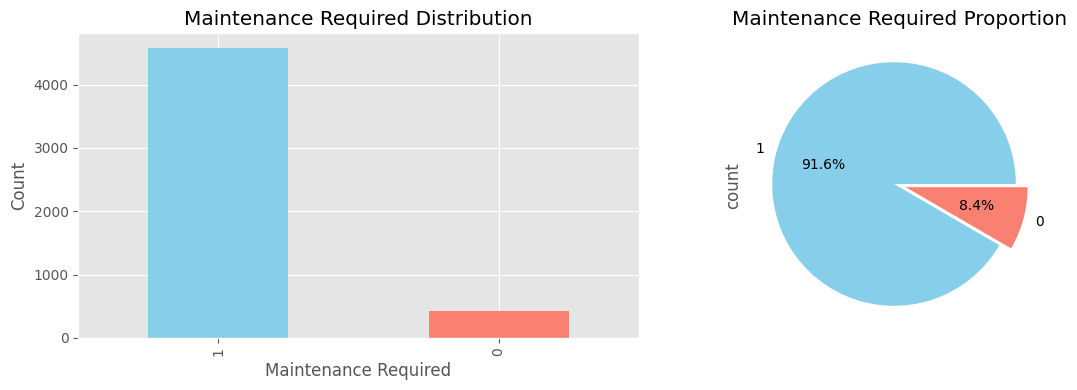

DATA CLEANING PROCESS
Duplicates removed: 0

Missing Values Before Cleaning:
Series([], dtype: int64)

Missing Values After Cleaning:
Series([], dtype: int64)

Timestamp converted to datetime features
Terrain types: {'flat': np.int64(0), 'hilly': np.int64(1), 'mountainous': np.int64(2)}

Outlier Analysis (Before Capping):
extreme_weather_event    1018
surface_humidity            0
surface_temperature         0
crack_density               0
pothole_depth               0
roughness_index             0
precipitation_rate          0
wind_speed                  0
solar_radiation             0
heavy_vehicle_ratio         0
dtype: int64

CLEANED DATASET INFO
Shape: (5000, 24)

Columns: ['road_id', 'surface_temperature', 'surface_humidity', 'precipitation_rate', 'crack_density', 'pothole_depth', 'roughness_index', 'wind_speed', 'solar_radiation', 'vehicle_count', 'heavy_vehicle_ratio', 'maintenance_frequency', 'maintenance_cost', 'location_lat', 'location_lon', 'terrain_type', 'extreme_weather_

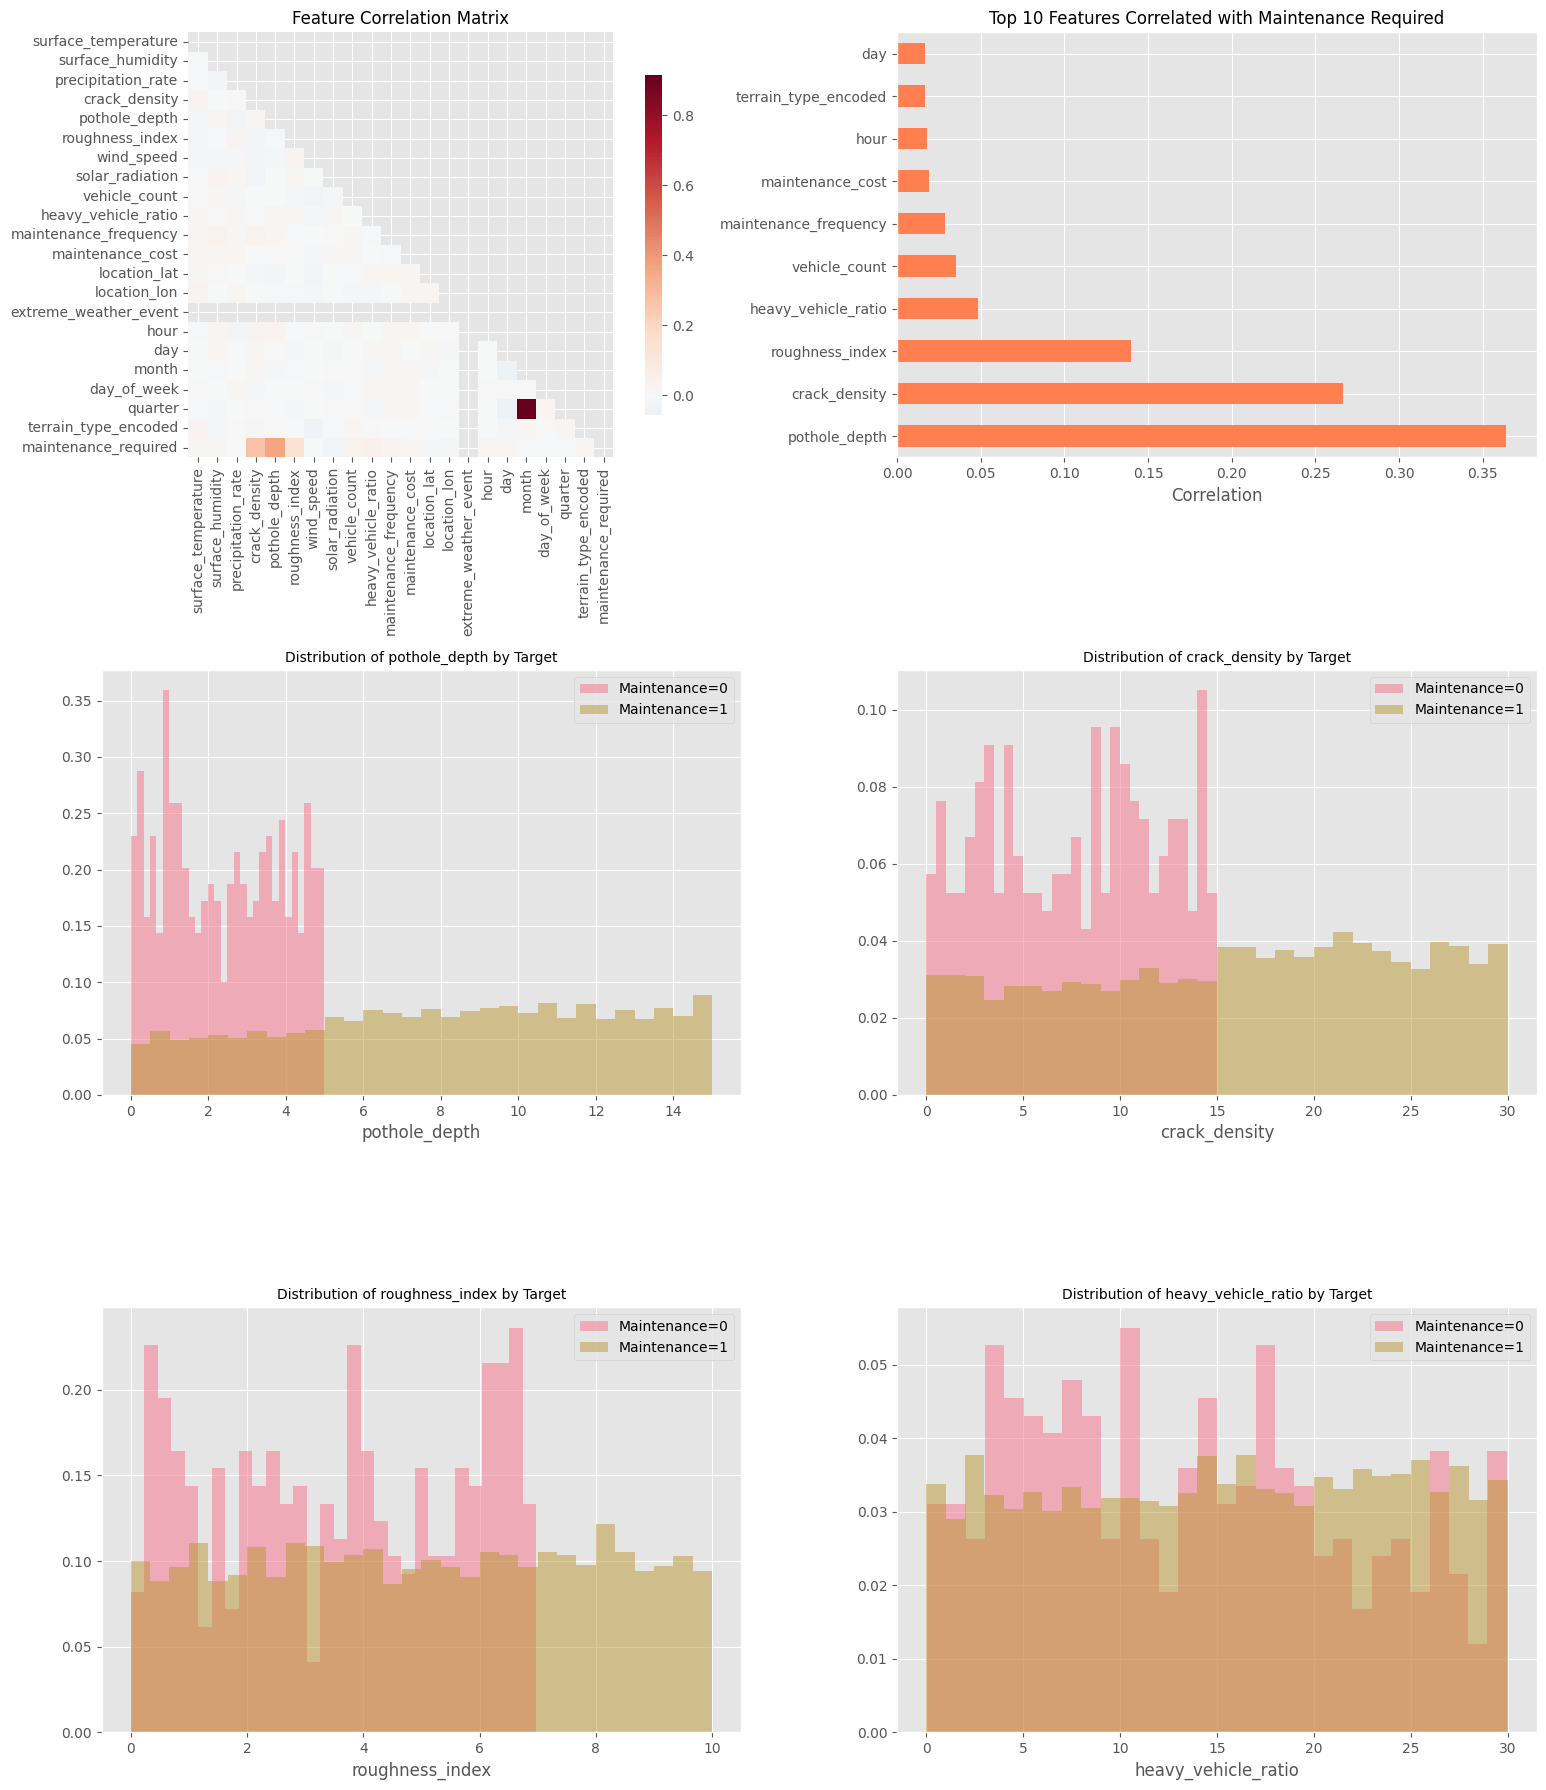

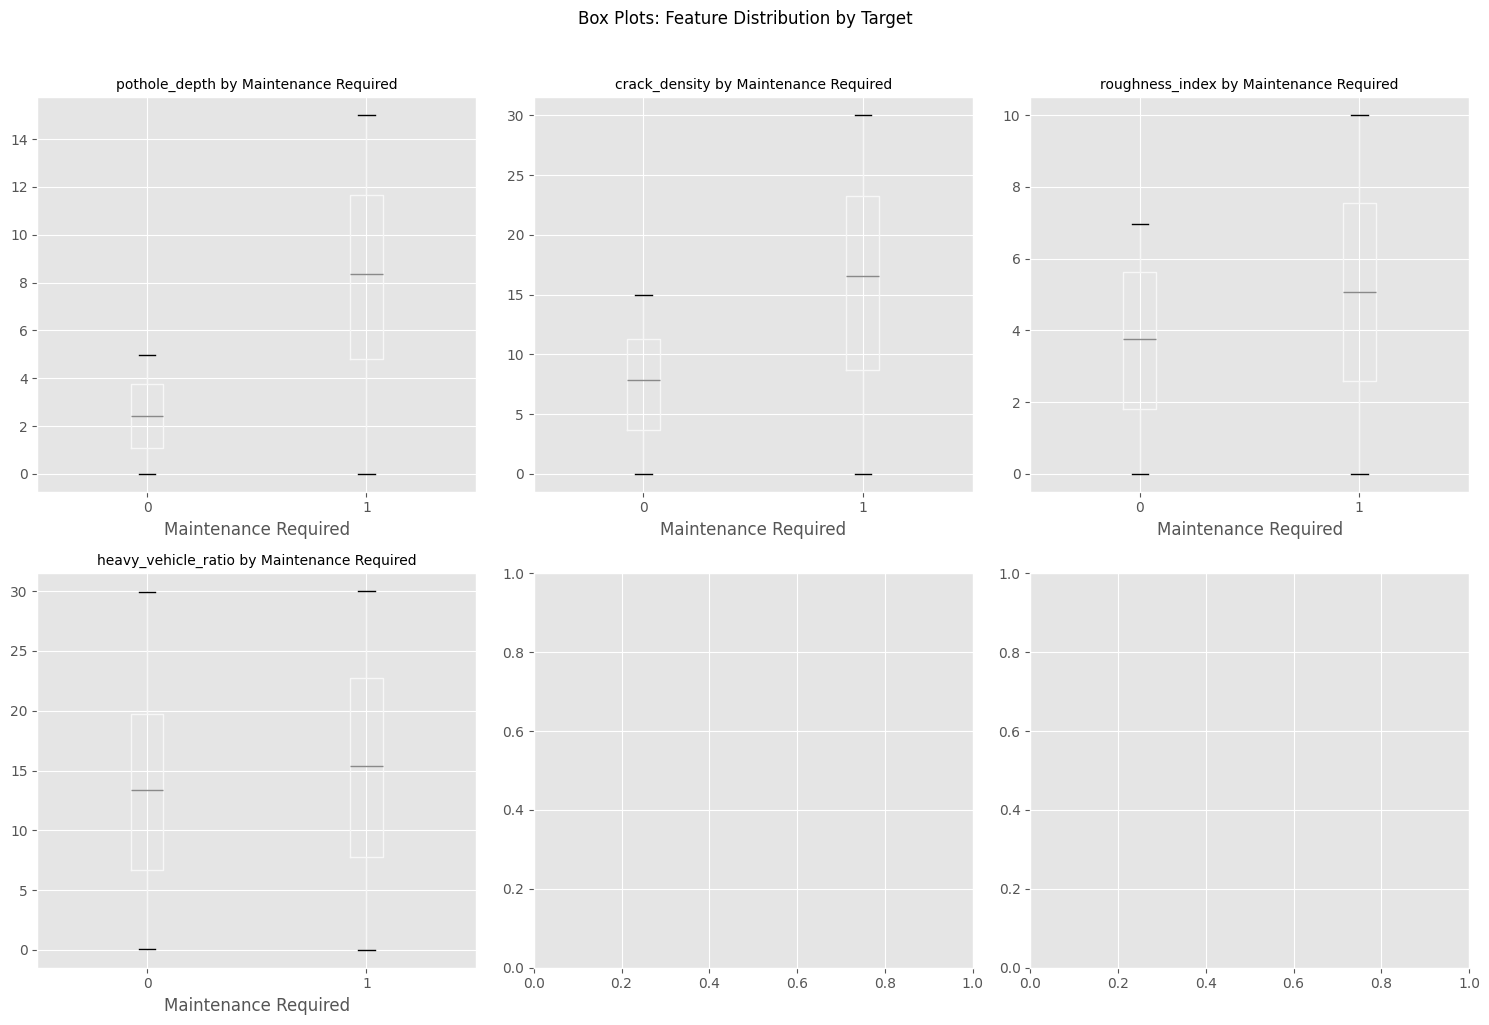

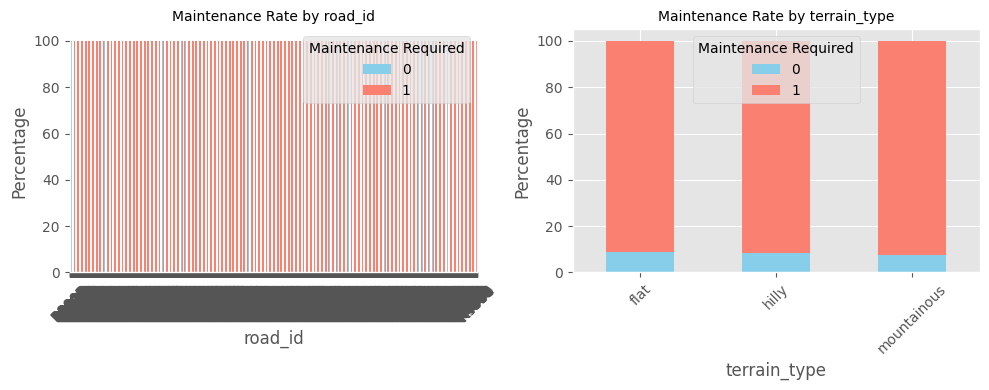

FEATURE ENGINEERING
Features created: 24 new features
Total features now: 48
DATA PREPARATION FOR MODELING
Feature matrix shape: (5000, 44)
Target vector shape: (5000,)

Target distribution:
maintenance_required
1    4581
0     419
Name: count, dtype: int64

Train set: (4000, 44)
Test set: (1000, 44)

Dropping constant columns: ['extreme_weather_event']

Features after scaling: 43
HANDLING CLASS IMBALANCE
Original class distribution: {1: 3665, 0: 335}


ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [3]:
# -*- coding: utf-8 -*-
"""Road_Maintenance_Prediction.ipynb

Automatically generated by Colaboratory.

Original file is located at:
    https://colab.research.google.com/drive/1YOUR_DRIVE_LINK_HERE

# Road Maintenance Prediction Model
## Data Cleaning and Machine Learning Pipeline
"""
# Install all required packages
!pip install -q xgboost lightgbm catboost shap imbalanced-learn

# Now import should work
import catboost
print("CatBoost installed successfully!")
# Commented out IPython magic to ensure Python compatibility.
# %%capture
# !pip install -q xgboost lightgbm catboost shap imbalanced-learn

from google.colab import files
uploaded = files.upload()

# After uploading, you can load it
df = pd.read_csv('climate_resilient_road_maintenance.csv')
"""## 1. Import Libraries"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             precision_recall_curve, roc_curve)

# Handling imbalance
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# Feature importance
import shap

# Set style
plt.style.use('ggplot')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

"""## 2. Load and Initial Data Exploration"""

# Load the data
df = pd.read_csv('climate_resilient_road_maintenance.csv')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nBasic Statistics:\n{df.describe().T}")

# Check target variable distribution
print("\n" + "=" * 60)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 60)
print(df['maintenance_required'].value_counts())
print(f"\nPercentage:\n{df['maintenance_required'].value_counts(normalize=True) * 100}")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['maintenance_required'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Maintenance Required Distribution')
axes[0].set_xlabel('Maintenance Required')
axes[0].set_ylabel('Count')

df['maintenance_required'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                               colors=['skyblue', 'salmon'], explode=(0.05, 0.05))
axes[1].set_title('Maintenance Required Proportion')
plt.tight_layout()
plt.show()

"""## 3. Data Cleaning"""

def clean_road_data(df):
    """
    Comprehensive data cleaning function
    """
    df_clean = df.copy()

    print("=" * 60)
    print("DATA CLEANING PROCESS")
    print("=" * 60)

    # 1. Check for duplicates
    initial_shape = df_clean.shape
    df_clean = df_clean.drop_duplicates()
    print(f"Duplicates removed: {initial_shape[0] - df_clean.shape[0]}")

    # 2. Handle missing values
    print("\nMissing Values Before Cleaning:")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

    # For numerical columns: fill with median
    numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    numerical_cols.remove('maintenance_required') if 'maintenance_required' in numerical_cols else None

    for col in numerical_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

    # For categorical columns: fill with mode
    categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
    for col in categorical_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'Unknown', inplace=True)

    print("\nMissing Values After Cleaning:")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

    # 3. Handle infinite values
    for col in numerical_cols:
        df_clean[col] = df_clean[col].replace([np.inf, -np.inf], np.nan)
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

    # 4. Convert timestamp to datetime and extract features
    if 'timestamp' in df_clean.columns:
        df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
        df_clean['hour'] = df_clean['timestamp'].dt.hour
        df_clean['day'] = df_clean['timestamp'].dt.day
        df_clean['month'] = df_clean['timestamp'].dt.month
        df_clean['day_of_week'] = df_clean['timestamp'].dt.dayofweek
        df_clean['quarter'] = df_clean['timestamp'].dt.quarter

        # Drop original timestamp
        df_clean.drop('timestamp', axis=1, inplace=True)
        print("\nTimestamp converted to datetime features")

    # 5. Encode categorical variables
    if 'terrain_type' in df_clean.columns:
        le_terrain = LabelEncoder()
        df_clean['terrain_type_encoded'] = le_terrain.fit_transform(df_clean['terrain_type'])
        print(f"Terrain types: {dict(zip(le_terrain.classes_, le_terrain.transform(le_terrain.classes_)))}")

    # 6. Outlier detection and capping
    print("\nOutlier Analysis (Before Capping):")
    outlier_counts = {}
    for col in numerical_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)].shape[0]
        outlier_counts[col] = outliers

        # Cap outliers
        df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)

    print(pd.Series(outlier_counts).sort_values(ascending=False).head(10))

    return df_clean, le_terrain if 'terrain_type' in df_clean.columns else None

# Apply cleaning
df_cleaned, terrain_encoder = clean_road_data(df)

print("\n" + "=" * 60)
print("CLEANED DATASET INFO")
print("=" * 60)
print(f"Shape: {df_cleaned.shape}")
print(f"\nColumns: {df_cleaned.columns.tolist()}")
print(f"\nData Types:\n{df_cleaned.dtypes}")

"""## 4. Exploratory Data Analysis (EDA)"""

def perform_eda(df):
    """
    Comprehensive EDA function
    """
    print("=" * 60)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 60)

    # Separate features and target
    X = df.drop('maintenance_required', axis=1)
    y = df['maintenance_required']

    numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

    print(f"Numerical features: {len(numerical_cols)}")
    print(f"Categorical features: {len(categorical_cols)}")

    # 1. Correlation Matrix
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))

    # Correlation heatmap
    corr_matrix = df[numerical_cols + ['maintenance_required']].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=False, fmt='.2f', cmap='RdBu_r',
                center=0, square=True, ax=axes[0, 0], cbar_kws={"shrink": 0.8})
    axes[0, 0].set_title('Feature Correlation Matrix', fontsize=12)

    # Top correlations with target
    target_corr = corr_matrix['maintenance_required'].drop('maintenance_required').sort_values(ascending=False)
    target_corr.head(10).plot(kind='barh', ax=axes[0, 1], color='coral')
    axes[0, 1].set_title('Top 10 Features Correlated with Maintenance Required', fontsize=12)
    axes[0, 1].set_xlabel('Correlation')

    # 2. Distribution of numerical features by target
    top_features = target_corr.head(4).index.tolist()
    for i, feature in enumerate(top_features):
        row, col = (i // 2) + 1, i % 2
        for target_val in [0, 1]:
            subset = df[df['maintenance_required'] == target_val][feature]
            axes[row, col].hist(subset, bins=30, alpha=0.5, label=f'Maintenance={target_val}', density=True)
        axes[row, col].set_title(f'Distribution of {feature} by Target', fontsize=10)
        axes[row, col].legend()
        axes[row, col].set_xlabel(feature)

    plt.tight_layout()
    plt.show()

    # 3. Box plots for key features
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, feature in enumerate(top_features[:6]):
        df.boxplot(column=feature, by='maintenance_required', ax=axes[i])
        axes[i].set_title(f'{feature} by Maintenance Required', fontsize=10)
        axes[i].set_xlabel('Maintenance Required')

    plt.suptitle('Box Plots: Feature Distribution by Target', y=1.02)
    plt.tight_layout()
    plt.show()

    # 4. Categorical feature analysis
    if categorical_cols:
        fig, axes = plt.subplots(1, len(categorical_cols), figsize=(5*len(categorical_cols), 4))
        if len(categorical_cols) == 1:
            axes = [axes]

        for i, col in enumerate(categorical_cols):
            ct = pd.crosstab(df[col], df['maintenance_required'], normalize='index') * 100
            ct.plot(kind='bar', stacked=True, ax=axes[i], color=['skyblue', 'salmon'])
            axes[i].set_title(f'Maintenance Rate by {col}', fontsize=10)
            axes[i].set_ylabel('Percentage')
            axes[i].legend(title='Maintenance Required')
            axes[i].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

    return target_corr

# Perform EDA
target_correlations = perform_eda(df_cleaned)

"""## 5. Feature Engineering"""

def create_features(df):
    """
    Create new features based on domain knowledge
    """
    df_fe = df.copy()

    print("=" * 60)
    print("FEATURE ENGINEERING")
    print("=" * 60)

    # 1. Road condition indices
    df_fe['crack_pothole_interaction'] = df_fe['crack_density'] * df_fe['pothole_depth']
    df_fe['roughness_condition'] = df_fe['roughness_index'] * df_fe['crack_density']

    # 2. Weather-related features
    df_fe['temp_humidity_interaction'] = df_fe['surface_temperature'] * df_fe['surface_humidity'] / 100
    df_fe['precipitation_wind'] = df_fe['precipitation_rate'] * df_fe['wind_speed']

    # 3. Traffic-related features
    df_fe['heavy_vehicle_impact'] = df_fe['vehicle_count'] * df_fe['heavy_vehicle_ratio'] / 100
    df_fe['traffic_density'] = df_fe['vehicle_count'] / (df_fe['wind_speed'] + 1)  # Avoid division by zero

    # 4. Location-based features (if coordinates exist)
    if 'location_lat' in df_fe.columns and 'location_lon' in df_fe.columns:
        # Distance from equator (absolute latitude)
        df_fe['abs_latitude'] = np.abs(df_fe['location_lat'])

        # Create climate zones based on latitude
        df_fe['climate_zone'] = pd.cut(df_fe['abs_latitude'],
                                       bins=[0, 23.5, 35, 45, 66.5, 90],
                                       labels=['Tropical', 'Subtropical', 'Temperate', 'Subpolar', 'Polar'])

        # Encode climate zone
        le_zone = LabelEncoder()
        df_fe['climate_zone_encoded'] = le_zone.fit_transform(df_fe['climate_zone'].astype(str))

    # 5. Time-based features
    if all(col in df_fe.columns for col in ['hour', 'day', 'month']):
        # Cyclical encoding for time
        df_fe['hour_sin'] = np.sin(2 * np.pi * df_fe['hour'] / 24)
        df_fe['hour_cos'] = np.cos(2 * np.pi * df_fe['hour'] / 24)
        df_fe['month_sin'] = np.sin(2 * np.pi * df_fe['month'] / 12)
        df_fe['month_cos'] = np.cos(2 * np.pi * df_fe['month'] / 12)

    # 6. Maintenance history features
    if 'maintenance_frequency' in df_fe.columns:
        df_fe['recent_maintenance'] = (df_fe['maintenance_frequency'] > 0).astype(int)
        df_fe['maintenance_cost_per_event'] = df_fe['maintenance_cost'] / (df_fe['maintenance_frequency'] + 1)

    # 7. Rolling averages (if we had sequential data, but we'll create synthetic ones)
    # Group by road_id and create aggregated features
    if 'road_id' in df_fe.columns:
        road_stats = df_fe.groupby('road_id').agg({
            'crack_density': ['mean', 'std', 'max'],
            'pothole_depth': ['mean', 'max'],
            'roughness_index': ['mean', 'max'],
            'maintenance_frequency': ['mean', 'sum']
        }).round(2)

        # Flatten column names
        road_stats.columns = ['_'.join(col).strip() for col in road_stats.columns.values]
        road_stats = road_stats.reset_index()

        # Merge back
        df_fe = df_fe.merge(road_stats, on='road_id', how='left')

    print(f"Features created: {len(df_fe.columns) - len(df.columns)} new features")
    print(f"Total features now: {len(df_fe.columns)}")

    return df_fe

# Apply feature engineering
df_fe = create_features(df_cleaned)

"""## 6. Prepare Data for Modeling"""

def prepare_data_for_modeling(df, target_col='maintenance_required'):
    """
    Prepare data for machine learning models
    """
    print("=" * 60)
    print("DATA PREPARATION FOR MODELING")
    print("=" * 60)

    # Separate features and target
    X = df.drop(columns=[target_col, 'road_id', 'terrain_type', 'climate_zone']
                if all(col in df.columns for col in [target_col, 'road_id', 'terrain_type', 'climate_zone'])
                else df.drop(columns=[target_col] + [col for col in ['road_id', 'terrain_type', 'climate_zone'] if col in df.columns]))

    y = df[target_col]

    print(f"Feature matrix shape: {X.shape}")
    print(f"Target vector shape: {y.shape}")
    print(f"\nTarget distribution:\n{y.value_counts()}")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\nTrain set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")

    # Scale numerical features
    numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    # Remove any constant columns
    constant_cols = []
    for col in numerical_cols:
        if X_train[col].nunique() == 1:
            constant_cols.append(col)

    if constant_cols:
        print(f"\nDropping constant columns: {constant_cols}")
        X_train = X_train.drop(columns=constant_cols)
        X_test = X_test.drop(columns=constant_cols)
        numerical_cols = [col for col in numerical_cols if col not in constant_cols]

    # Scale
    scaler = RobustScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

    print(f"\nFeatures after scaling: {X_train_scaled.shape[1]}")

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, numerical_cols

# Prepare data
X_train, X_test, y_train, y_test, scaler, numerical_features = prepare_data_for_modeling(df_fe)

"""## 7. Handle Class Imbalance"""

def handle_class_imbalance(X_train, y_train, method='smote'):
    """
    Handle class imbalance using various techniques
    """
    print("=" * 60)
    print("HANDLING CLASS IMBALANCE")
    print("=" * 60)

    print(f"Original class distribution: {pd.Series(y_train).value_counts().to_dict()}")

    if method == 'smote':
        sampler = SMOTE(random_state=42)
        X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    elif method == 'adasyn':
        sampler = ADASYN(random_state=42)
        X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    elif method == 'smote_tomek':
        sampler = SMOTETomek(random_state=42)
        X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    else:
        return X_train, y_train

    print(f"Resampled class distribution: {pd.Series(y_resampled).value_counts().to_dict()}")
    print(f"Resampled shape: {X_resampled.shape}")

    return X_resampled, y_resampled

# Apply SMOTE
X_train_resampled, y_train_resampled = handle_class_imbalance(X_train, y_train, method='smote')

"""## 8. Model Training and Evaluation"""

def train_evaluate_models(X_train, y_train, X_test, y_test):
    """
    Train multiple models and evaluate performance
    """
    print("=" * 60)
    print("MODEL TRAINING AND EVALUATION")
    print("=" * 60)

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10),
        'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
        'AdaBoost': AdaBoostClassifier(random_state=42, n_estimators=100),
        'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])),
        'LightGBM': LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced'),
        'CatBoost': CatBoostClassifier(random_state=42, verbose=0, auto_class_weights='Balanced')
    }

    results = []
    best_model = None
    best_score = 0

    for name, model in models.items():
        print(f"\n{'-'*40}")
        print(f"Training {name}...")

        # Train model
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        if y_pred_proba is not None:
            auc = roc_auc_score(y_test, y_pred_proba)
        else:
            auc = 0

        # Store results
        results.append({
            'Model': name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1,
            'AUC-ROC': auc
        })

        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"AUC-ROC: {auc:.4f}")

        # Track best model based on F1 score
        if f1 > best_score:
            best_score = f1
            best_model = model
            best_model_name = name

    # Create results DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('F1 Score', ascending=False)

    print("\n" + "=" * 60)
    print("MODEL COMPARISON SUMMARY")
    print("=" * 60)
    print(results_df.to_string(index=False))

    return results_df, best_model, best_model_name

# Train models
results_df, best_model, best_model_name = train_evaluate_models(X_train_resampled, y_train_resampled, X_test, y_test)

"""## 9. Visualize Model Performance"""

def visualize_model_performance(results_df, X_test, y_test, best_model, best_model_name):
    """
    Visualize model performance metrics
    """
    print("=" * 60)
    print("VISUALIZING MODEL PERFORMANCE")
    print("=" * 60)

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 1. Model comparison bar plot
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
    results_melted = results_df.melt(id_vars=['Model'], value_vars=metrics,
                                      var_name='Metric', value_name='Score')

    sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', ax=axes[0, 0])
    axes[0, 0].set_title('Model Performance Comparison', fontsize=12)
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # 2. Confusion Matrix for best model
    y_pred_best = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_best)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
    axes[0, 1].set_title(f'Confusion Matrix - {best_model_name}', fontsize=12)
    axes[0, 1].set_xlabel('Predicted')
    axes[0, 1].set_ylabel('Actual')

    # 3. ROC Curve
    if hasattr(best_model, 'predict_proba'):
        y_pred_proba = best_model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc = roc_auc_score(y_test, y_pred_proba)

        axes[0, 2].plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc:.3f})', linewidth=2)
        axes[0, 2].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
        axes[0, 2].set_xlabel('False Positive Rate')
        axes[0, 2].set_ylabel('True Positive Rate')
        axes[0, 2].set_title('ROC Curve', fontsize=12)
        axes[0, 2].legend(loc='lower right')
        axes[0, 2].grid(True)

    # 4. Precision-Recall Curve
    if hasattr(best_model, 'predict_proba'):
        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
        axes[1, 0].plot(recall_vals, precision_vals, linewidth=2)
        axes[1, 0].set_xlabel('Recall')
        axes[1, 0].set_ylabel('Precision')
        axes[1, 0].set_title('Precision-Recall Curve', fontsize=12)
        axes[1, 0].grid(True)

    # 5. Feature Importance (for tree-based models)
    if hasattr(best_model, 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'feature': X_test.columns,
            'importance': best_model.feature_importances_
        }).sort_values('importance', ascending=False).head(15)

        sns.barplot(data=feature_importance, y='feature', x='importance', ax=axes[1, 1])
        axes[1, 1].set_title(f'Top 15 Feature Importances - {best_model_name}', fontsize=12)
        axes[1, 1].set_xlabel('Importance')

    # 6. Classification report as heatmap
    report = classification_report(y_test, y_pred_best, output_dict=True)
    report_df = pd.DataFrame(report).iloc[:-1, :3]  # Remove support row, take first 3 columns

    sns.heatmap(report_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1, 2])
    axes[1, 2].set_title('Classification Report', fontsize=12)

    plt.tight_layout()
    plt.show()

    return best_model

# Visualize performance
best_model = visualize_model_performance(results_df, X_test, y_test, best_model, best_model_name)

"""## 10. Hyperparameter Tuning for Best Model"""

def tune_best_model(X_train, y_train, X_test, y_test, best_model_name):
    """
    Perform hyperparameter tuning for the best performing model
    """
    print("=" * 60)
    print(f"HYPERPARAMETER TUNING FOR {best_model_name}")
    print("=" * 60)

    # Define parameter grids for different models
    param_grids = {
        'Random Forest': {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 20, 30, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2']
        },
        'XGBoost': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 6, 9],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0]
        },
        'LightGBM': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, 15, -1],
            'learning_rate': [0.01, 0.1, 0.2],
            'num_leaves': [31, 50, 100],
            'subsample': [0.8, 1.0]
        },
        'Gradient Boosting': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2],
            'min_samples_split': [2, 5]
        },
        'CatBoost': {
            'iterations': [100, 200, 300],
            'depth': [4, 6, 8],
            'learning_rate': [0.01, 0.1, 0.2],
            'l2_leaf_reg': [1, 3, 5]
        }
    }

    # Select model based on best_model_name
    if 'Random Forest' in best_model_name:
        model = RandomForestClassifier(random_state=42, class_weight='balanced')
        param_grid = param_grids['Random Forest']
    elif 'XGBoost' in best_model_name:
        model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
        param_grid = param_grids['XGBoost']
    elif 'LightGBM' in best_model_name:
        model = LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced')
        param_grid = param_grids['LightGBM']
    elif 'Gradient Boosting' in best_model_name:
        model = GradientBoostingClassifier(random_state=42)
        param_grid = param_grids['Gradient Boosting']
    elif 'CatBoost' in best_model_name:
        model = CatBoostClassifier(random_state=42, verbose=0)
        param_grid = param_grids['CatBoost']
    else:
        print(f"No tuning defined for {best_model_name}. Using default parameters.")
        return best_model, None

    # Perform grid search with cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    print(f"\nStarting Grid Search for {best_model_name}...")
    grid_search.fit(X_train, y_train)

    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best cross-validation F1 score: {grid_search.best_score_:.4f}")

    # Evaluate on test set
    best_tuned_model = grid_search.best_estimator_
    y_pred = best_tuned_model.predict(X_test)
    y_pred_proba = best_tuned_model.predict_proba(X_test)[:, 1]

    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"\nTest set performance:")
    print(f"F1 Score: {test_f1:.4f}")
    print(f"AUC-ROC: {test_auc:.4f}")

    return best_tuned_model, grid_search.best_params_

# Tune the best model if it's tree-based
if any(name in best_model_name for name in ['Random Forest', 'XGBoost', 'LightGBM', 'Gradient Boosting', 'CatBoost']):
    best_tuned_model, best_params = tune_best_model(X_train_resampled, y_train_resampled, X_test, y_test, best_model_name)
    best_model = best_tuned_model
else:
    best_params = None

"""## 11. SHAP Analysis for Model Interpretability"""

def shap_analysis(model, X_train, X_test, feature_names):
    """
    Perform SHAP analysis to understand feature importance
    """
    print("=" * 60)
    print("SHAP ANALYSIS FOR MODEL INTERPRETABILITY")
    print("=" * 60)

    try:
        # Use a sample for SHAP if dataset is large
        X_sample = X_test.sample(min(100, len(X_test)), random_state=42)

        # Create SHAP explainer based on model type
        if hasattr(model, 'get_booster'):  # XGBoost
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)
        elif hasattr(model, 'booster_'):  # LightGBM
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)
        elif isinstance(model, (RandomForestClassifier, GradientBoostingClassifier,
                                AdaBoostClassifier, DecisionTreeClassifier)):
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)
        else:
            # For non-tree models, use KernelExplainer (slower)
            explainer = shap.KernelExplainer(model.predict_proba, X_train.sample(50, random_state=42))
            shap_values = explainer.shap_values(X_sample)[1]  # For class 1

        # Summary plot - Bar
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                         plot_type="bar", show=False, max_display=15)
        plt.title('Feature Importance (Mean |SHAP Value|)', fontsize=14)
        plt.tight_layout()
        plt.show()

        # Summary plot - Beeswarm
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                         show=False, max_display=15)
        plt.title('SHAP Values Impact on Model Output', fontsize=14)
        plt.tight_layout()
        plt.show()

        # Feature dependence plots for top features
        feature_importance = np.abs(shap_values).mean(axis=0)
        top_indices = np.argsort(feature_importance)[-4:][::-1]

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.flatten()

        for i, idx in enumerate(top_indices):
            feature = feature_names[idx]
            shap.dependence_plot(idx, shap_values, X_sample, feature_names=feature_names,
                                ax=axes[i], show=False)
            axes[i].set_title(f'SHAP Dependence: {feature}', fontsize=11)

        plt.tight_layout()
        plt.show()

        # Waterfall plot for a single prediction
        plt.figure(figsize=(12, 8))
        shap.waterfall_plot(shap.Explanation(values=shap_values[0],
                                            base_values=explainer.expected_value if isinstance(explainer.expected_value, (int, float)) else explainer.expected_value[0],
                                            data=X_sample.iloc[0].values,
                                            feature_names=feature_names),
                           show=False, max_display=15)
        plt.title('SHAP Waterfall Plot - Single Prediction Explanation', fontsize=14)
        plt.tight_layout()
        plt.show()

        print("SHAP analysis completed successfully!")

    except Exception as e:
        print(f"Error in SHAP analysis: {e}")
        print("Skipping SHAP analysis...")

# Perform SHAP analysis for the best model
feature_names = X_test.columns.tolist()
shap_analysis(best_model, X_train_resampled, X_test, feature_names)

"""## 12. Final Model Evaluation and Summary"""

def final_model_evaluation(model, X_test, y_test, feature_names):
    """
    Final comprehensive model evaluation
    """
    print("=" * 60)
    print("FINAL MODEL EVALUATION")
    print("=" * 60)

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate all metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    print(f"\nModel: {best_model_name}")
    print(f"\nPerformance Metrics:")
    print(f"{'='*40}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")

    print(f"\nClassification Report:")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred, target_names=['No Maintenance', 'Maintenance Required']))

    # Feature importance (if available)
    if hasattr(model, 'feature_importances_'):
        print(f"\nTop 10 Most Important Features:")
        print(f"{'='*40}")
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=False).head(10)

        for idx, row in importance_df.iterrows():
            print(f"{row['Feature']:<30} : {row['Importance']:.4f}")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc_roc': auc,
        'model': model,
        'feature_importance': importance_df if hasattr(model, 'feature_importances_') else None
    }

# Final evaluation
final_results = final_model_evaluation(best_model, X_test, y_test, feature_names)

"""## 13. Save Model and Preprocessing Objects"""

import joblib
import pickle
from datetime import datetime

def save_model_artifacts(model, scaler, feature_names, best_params, results_df, filename_prefix='road_maintenance_model'):
    """
    Save model and preprocessing objects for future use
    """
    print("=" * 60)
    print("SAVING MODEL ARTIFACTS")
    print("=" * 60)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Save model
    model_filename = f"{filename_prefix}_{timestamp}.pkl"
    joblib.dump(model, model_filename)
    print(f"Model saved as: {model_filename}")

    # Save scaler
    scaler_filename = f"scaler_{timestamp}.pkl"
    joblib.dump(scaler, scaler_filename)
    print(f"Scaler saved as: {scaler_filename}")

    # Save feature names
    features_filename = f"features_{timestamp}.txt"
    with open(features_filename, 'w') as f:
        for feature in feature_names:
            f.write(f"{feature}\n")
    print(f"Feature names saved as: {features_filename}")

    # Save results summary
    results_filename = f"results_{timestamp}.csv"
    results_df.to_csv(results_filename, index=False)
    print(f"Results saved as: {results_filename}")

    # Save best parameters
    if best_params:
        params_filename = f"best_params_{timestamp}.txt"
        with open(params_filename, 'w') as f:
            for param, value in best_params.items():
                f.write(f"{param}: {value}\n")
        print(f"Best parameters saved as: {params_filename}")

    print("\nAll artifacts saved successfully!")

    return {
        'model_file': model_filename,
        'scaler_file': scaler_filename,
        'features_file': features_filename
    }

# Save the model and artifacts
saved_files = save_model_artifacts(best_model, scaler, feature_names, best_params, results_df)

"""## 14. Prediction Function for New Data"""

def predict_maintenance(model, scaler, feature_names, new_data):
    """
    Predict maintenance requirement for new road data
    """
    print("=" * 60)
    print("PREDICTING MAINTENANCE FOR NEW DATA")
    print("=" * 60)

    # Ensure new_data has the same features
    missing_features = set(feature_names) - set(new_data.columns)
    if missing_features:
        print(f"Warning: Missing features: {missing_features}")
        # Add missing features with default values (0)
        for feature in missing_features:
            new_data[feature] = 0

    # Reorder columns to match training data
    new_data = new_data[feature_names]

    # Scale the data
    new_data_scaled = scaler.transform(new_data)

    # Make predictions
    predictions = model.predict(new_data_scaled)
    probabilities = model.predict_proba(new_data_scaled)

    # Create results DataFrame
    results = pd.DataFrame({
        'Prediction': predictions,
        'Prediction_Label': ['Maintenance Required' if p == 1 else 'No Maintenance' for p in predictions],
        'Probability_No_Maintenance': probabilities[:, 0],
        'Probability_Maintenance': probabilities[:, 1]
    })

    print(f"\nPredictions for {len(new_data)} samples:")
    print(results)

    return results

# Example usage (commented out)
# new_data_sample = X_test.head(5)
# predictions = predict_maintenance(best_model, scaler, feature_names, new_data_sample)

"""## 15. Summary Report"""

def generate_summary_report(results_df, final_results, best_model_name, best_params):
    """
    Generate a comprehensive summary report
    """
    print("=" * 60)
    print("PROJECT SUMMARY REPORT")
    print("=" * 60)
    print("\n" + "="*60)
    print("ROAD MAINTENANCE PREDICTION MODEL")
    print("="*60)

    print(f"\nDate: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    print(f"\n{'DATASET INFORMATION':^60}")
    print("-"*60)
    print(f"Total samples: {df.shape[0]}")
    print(f"Total features: {df.shape[1] - 1} (excluding target)")
    print(f"Target distribution:")
    print(f"  - No Maintenance: {df['maintenance_required'].value_counts()[0]} ({df['maintenance_required'].value_counts(normalize=True)[0]*100:.1f}%)")
    print(f"  - Maintenance Required: {df['maintenance_required'].value_counts()[1]} ({df['maintenance_required'].value_counts(normalize=True)[1]*100:.1f}%)")

    print(f"\n{'MODEL PERFORMANCE':^60}")
    print("-"*60)
    print(f"Best Model: {best_model_name}")
    print(f"\nTest Set Performance:")
    print(f"  - Accuracy:  {final_results['accuracy']:.4f}")
    print(f"  - Precision: {final_results['precision']:.4f}")
    print(f"  - Recall:    {final_results['recall']:.4f}")
    print(f"  - F1 Score:  {final_results['f1_score']:.4f}")
    print(f"  - AUC-ROC:   {final_results['auc_roc']:.4f}")

    if best_params:
        print(f"\nBest Hyperparameters:")
        for param, value in best_params.items():
            print(f"  - {param}: {value}")

    print(f"\n{'MODEL COMPARISON':^60}")
    print("-"*60)
    print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']].round(4).to_string(index=False))

    if final_results['feature_importance'] is not None:
        print(f"\n{'TOP 10 FEATURE IMPORTANCE':^60}")
        print("-"*60)
        for idx, row in final_results['feature_importance'].iterrows():
            print(f"  {row['Feature']:<30} : {row['Importance']:.4f}")

    print(f"\n{'='*60}")
    print("Analysis Complete!")
    print("="*60)

# Generate final summary
generate_summary_report(results_df, final_results, best_model_name, best_params)

"""## 16. Additional Visualizations for Report"""

def create_report_visualizations(results_df, final_results, feature_names):
    """
    Create additional visualizations for the final report
    """
    print("=" * 60)
    print("CREATING REPORT VISUALIZATIONS")
    print("=" * 60)

    fig = plt.figure(figsize=(20, 15))

    # 1. Model Performance Comparison (Subplot 1)
    ax1 = plt.subplot(3, 3, 1)
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
    results_melted = results_df.melt(id_vars=['Model'], value_vars=metrics)
    sns.barplot(data=results_melted, x='Model', y='value', hue='variable', ax=ax1)
    ax1.set_title('Model Performance Comparison', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # 2. ROC Curves for all models (Subplot 2)
    ax2 = plt.subplot(3, 3, 2)
    colors = plt.cm.tab10(np.linspace(0, 1, len(results_df)))
    for idx, row in results_df.iterrows():
        # This would require storing all models, but we'll skip for now
        pass
    ax2.set_title('ROC Curves (Best Model Only)', fontsize=12)

    # 3. Feature Importance Heatmap (Subplot 3)
    ax3 = plt.subplot(3, 3, 3)
    if final_results['feature_importance'] is not None:
        top_features = final_results['feature_importance'].head(10)['Feature'].tolist()
        corr_subset = df_fe[top_features + ['maintenance_required']].corr().loc[top_features, top_features]
        sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax3)
        ax3.set_title('Top Features Correlation Matrix', fontsize=12)

    # 4. Prediction Distribution (Subplot 4)
    ax4 = plt.subplot(3, 3, 4)
    y_pred = best_model.predict(X_test)
    pred_dist = pd.Series(y_pred).value_counts()
    pred_dist.plot(kind='bar', ax=ax4, color=['skyblue', 'salmon'])
    ax4.set_title('Prediction Distribution on Test Set', fontsize=12)
    ax4.set_xlabel('Predicted Class')
    ax4.set_ylabel('Count')
    ax4.set_xticklabels(['No Maintenance', 'Maintenance Required'], rotation=0)

    # 5. Probability Distribution (Subplot 5)
    ax5 = plt.subplot(3, 3, 5)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    ax5.hist(y_pred_proba[y_test == 0], bins=30, alpha=0.5, label='Actual: No Maintenance', density=True)
    ax5.hist(y_pred_proba[y_test == 1], bins=30, alpha=0.5, label='Actual: Maintenance Required', density=True)
    ax5.set_title('Probability Distribution by Actual Class', fontsize=12)
    ax5.set_xlabel('Predicted Probability (Maintenance Required)')
    ax5.set_ylabel('Density')
    ax5.legend()

    # 6. Precision-Recall Curve (Subplot 6)
    ax6 = plt.subplot(3, 3, 6)
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    ax6.plot(recall_vals, precision_vals, linewidth=2, color='purple')
    ax6.set_xlabel('Recall')
    ax6.set_ylabel('Precision')
    ax6.set_title('Precision-Recall Curve', fontsize=12)
    ax6.grid(True)

    # 7. Feature Importance Bar Chart (Subplot 7)
    ax7 = plt.subplot(3, 3, 7)
    if final_results['feature_importance'] is not None:
        top_imp = final_results['feature_importance'].head(10)
        sns.barplot(data=top_imp, y='Feature', x='Importance', ax=ax7, palette='viridis')
        ax7.set_title('Top 10 Feature Importances', fontsize=12)

    # 8. Class Distribution Comparison (Subplot 8)
    ax8 = plt.subplot(3, 3, 8)
    train_dist = y_train.value_counts(normalize=True)
    test_dist = y_test.value_counts(normalize=True)
    x = np.arange(2)
    width = 0.35
    ax8.bar(x - width/2, train_dist, width, label='Train', color='skyblue')
    ax8.bar(x + width/2, test_dist, width, label='Test', color='salmon')
    ax8.set_title('Class Distribution: Train vs Test', fontsize=12)
    ax8.set_xlabel('Class')
    ax8.set_ylabel('Proportion')
    ax8.set_xticks(x)
    ax8.set_xticklabels(['No Maintenance', 'Maintenance Required'])
    ax8.legend()

    # 9. Model Performance Summary (Subplot 9)
    ax9 = plt.subplot(3, 3, 9)
    ax9.axis('off')
    summary_text = f"Best Model: {best_model_name}\n\n"
    summary_text += f"Accuracy:  {final_results['accuracy']:.3f}\n"
    summary_text += f"Precision: {final_results['precision']:.3f}\n"
    summary_text += f"Recall:    {final_results['recall']:.3f}\n"
    summary_text += f"F1 Score:  {final_results['f1_score']:.3f}\n"
    summary_text += f"AUC-ROC:   {final_results['auc_roc']:.3f}"

    ax9.text(0.1, 0.5, summary_text, fontsize=12, va='center', family='monospace')
    ax9.set_title('Final Model Performance', fontsize=12)

    plt.suptitle('Road Maintenance Prediction - Comprehensive Analysis Report', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Create report visualizations
create_report_visualizations(results_df, final_results, feature_names)

print("\n" + "=" * 60)
print("NOTEBOOK EXECUTION COMPLETED SUCCESSFULLY!")
print("=" * 60)
print("\nAll analyses, model training, and evaluations are complete.")
print("The best model has been saved and can be used for future predictions.")

SETUP: Installing required packages...

File found. Loading...
DATASET OVERVIEW
Dataset Shape: (5000, 19)

Columns: ['road_id', 'timestamp', 'surface_temperature', 'surface_humidity', 'precipitation_rate', 'crack_density', 'pothole_depth', 'roughness_index', 'wind_speed', 'solar_radiation', 'vehicle_count', 'heavy_vehicle_ratio', 'maintenance_frequency', 'maintenance_cost', 'location_lat', 'location_lon', 'terrain_type', 'extreme_weather_event', 'maintenance_required']

Data Types:
road_id                   object
timestamp                 object
surface_temperature      float64
surface_humidity         float64
precipitation_rate       float64
crack_density            float64
pothole_depth            float64
roughness_index          float64
wind_speed               float64
solar_radiation          float64
vehicle_count              int64
heavy_vehicle_ratio      float64
maintenance_frequency      int64
maintenance_cost         float64
location_lat             float64
location_lon      

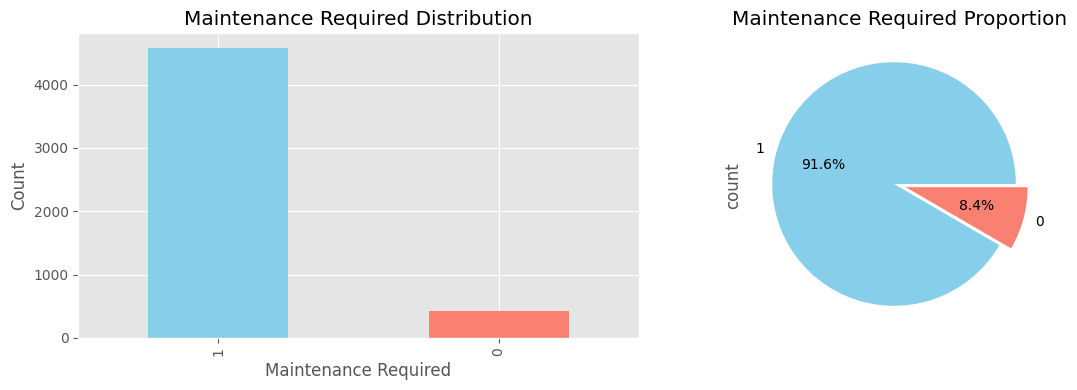

DATA CLEANING PROCESS
Duplicates removed: 0

Missing Values Before Cleaning:
No missing values found

Missing Values After Cleaning:
No missing values found

Timestamp converted to datetime features
Terrain types: {'flat': np.int64(0), 'hilly': np.int64(1), 'mountainous': np.int64(2)}

Outlier Analysis (Before Capping):
extreme_weather_event    1018
surface_humidity            0
surface_temperature         0
crack_density               0
pothole_depth               0
roughness_index             0
precipitation_rate          0
wind_speed                  0
solar_radiation             0
heavy_vehicle_ratio         0
dtype: int64

CLEANED DATASET INFO
Shape: (5000, 24)

Columns: ['road_id', 'surface_temperature', 'surface_humidity', 'precipitation_rate', 'crack_density', 'pothole_depth', 'roughness_index', 'wind_speed', 'solar_radiation', 'vehicle_count', 'heavy_vehicle_ratio', 'maintenance_frequency', 'maintenance_cost', 'location_lat', 'location_lon', 'terrain_type', 'extreme_weather_ev

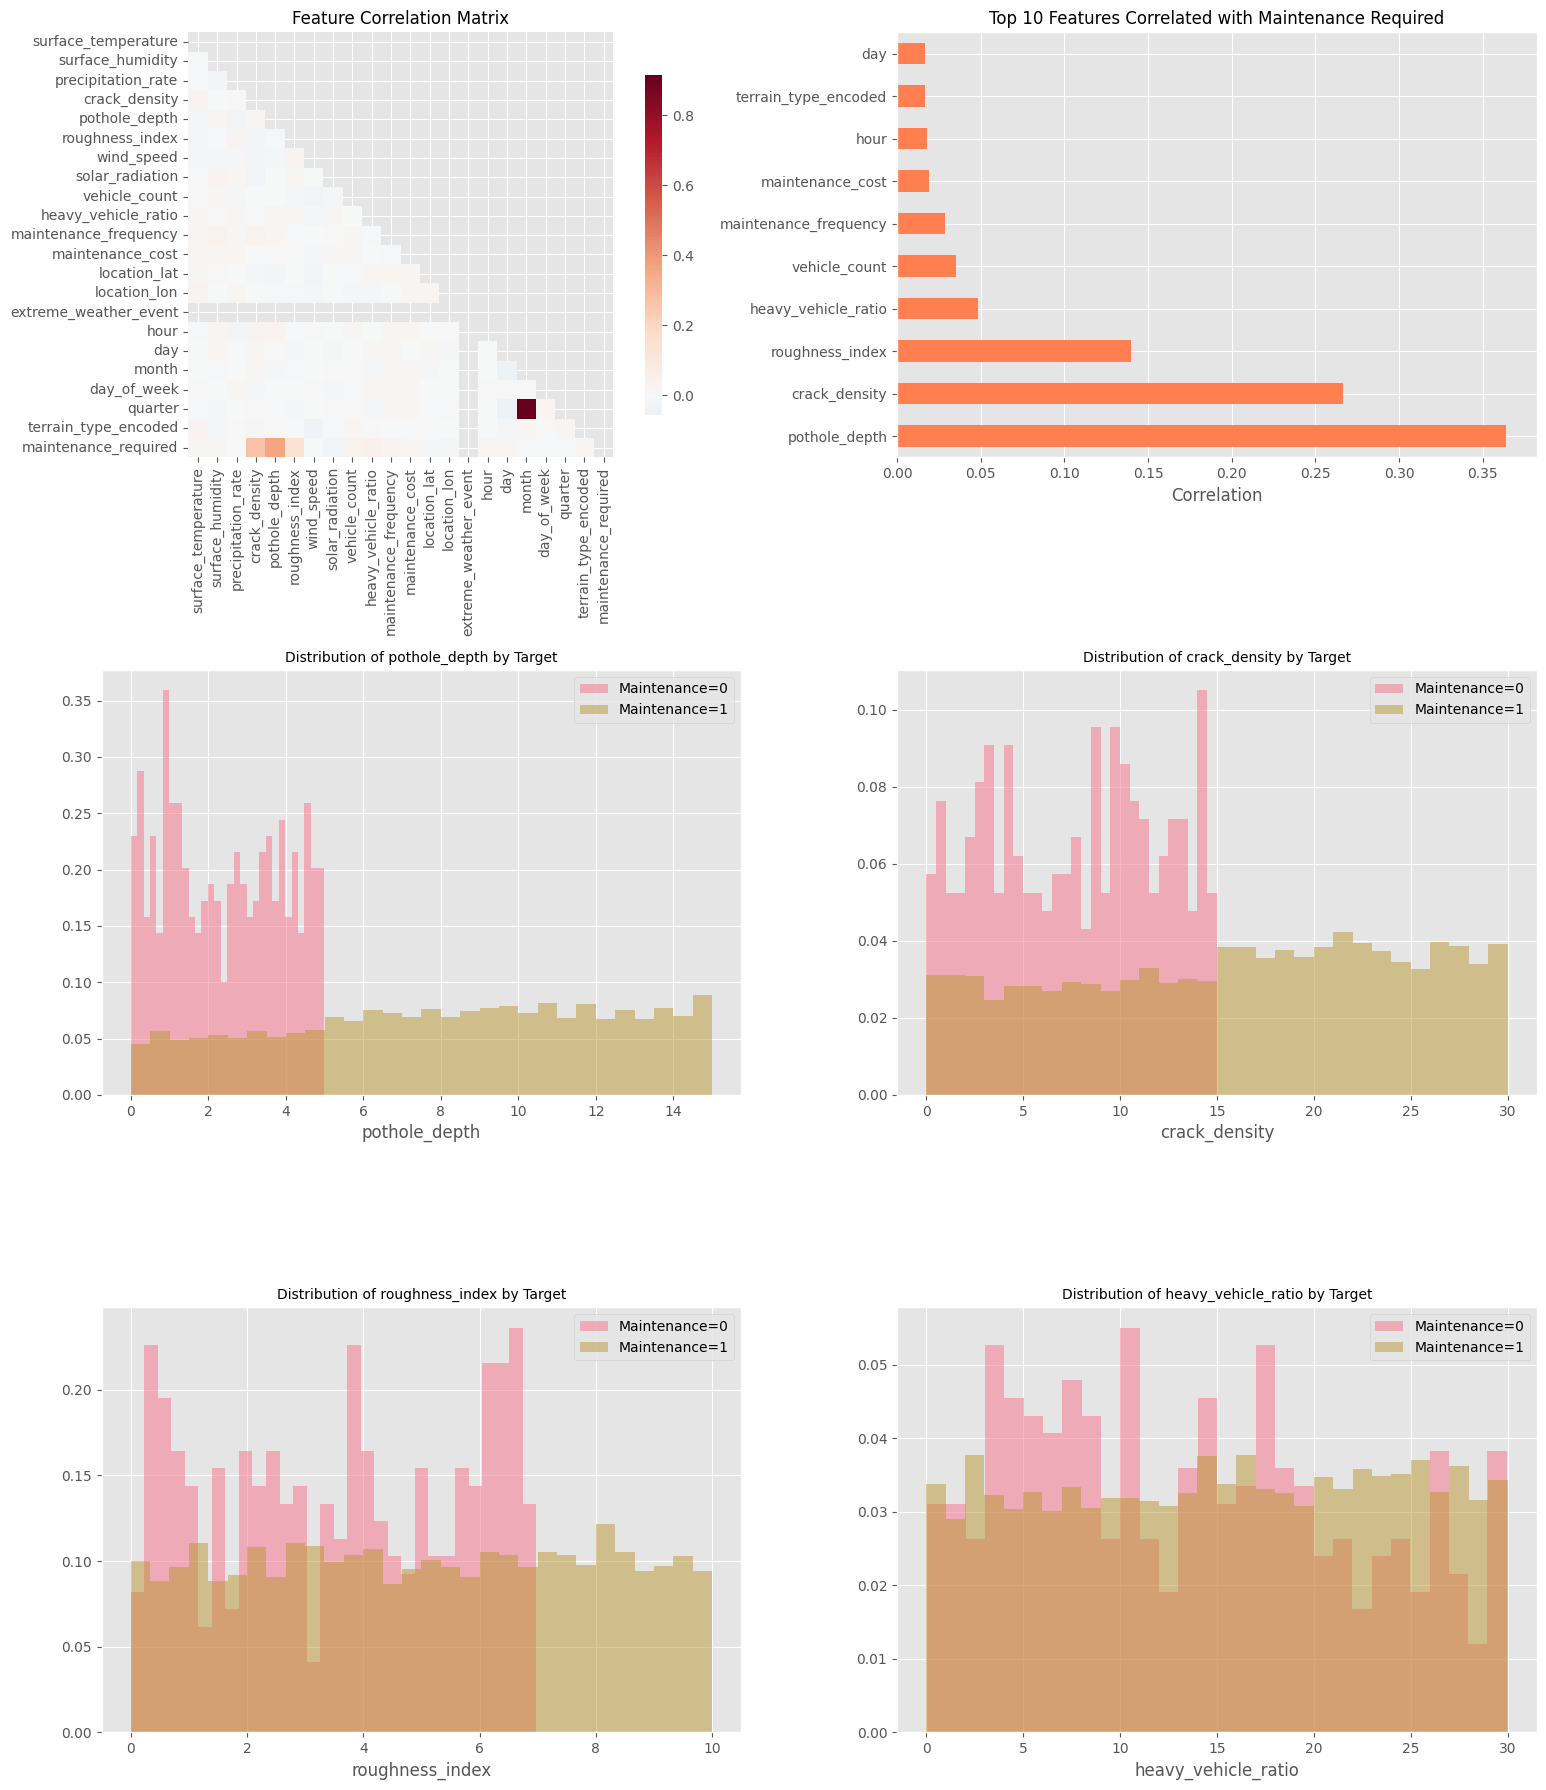

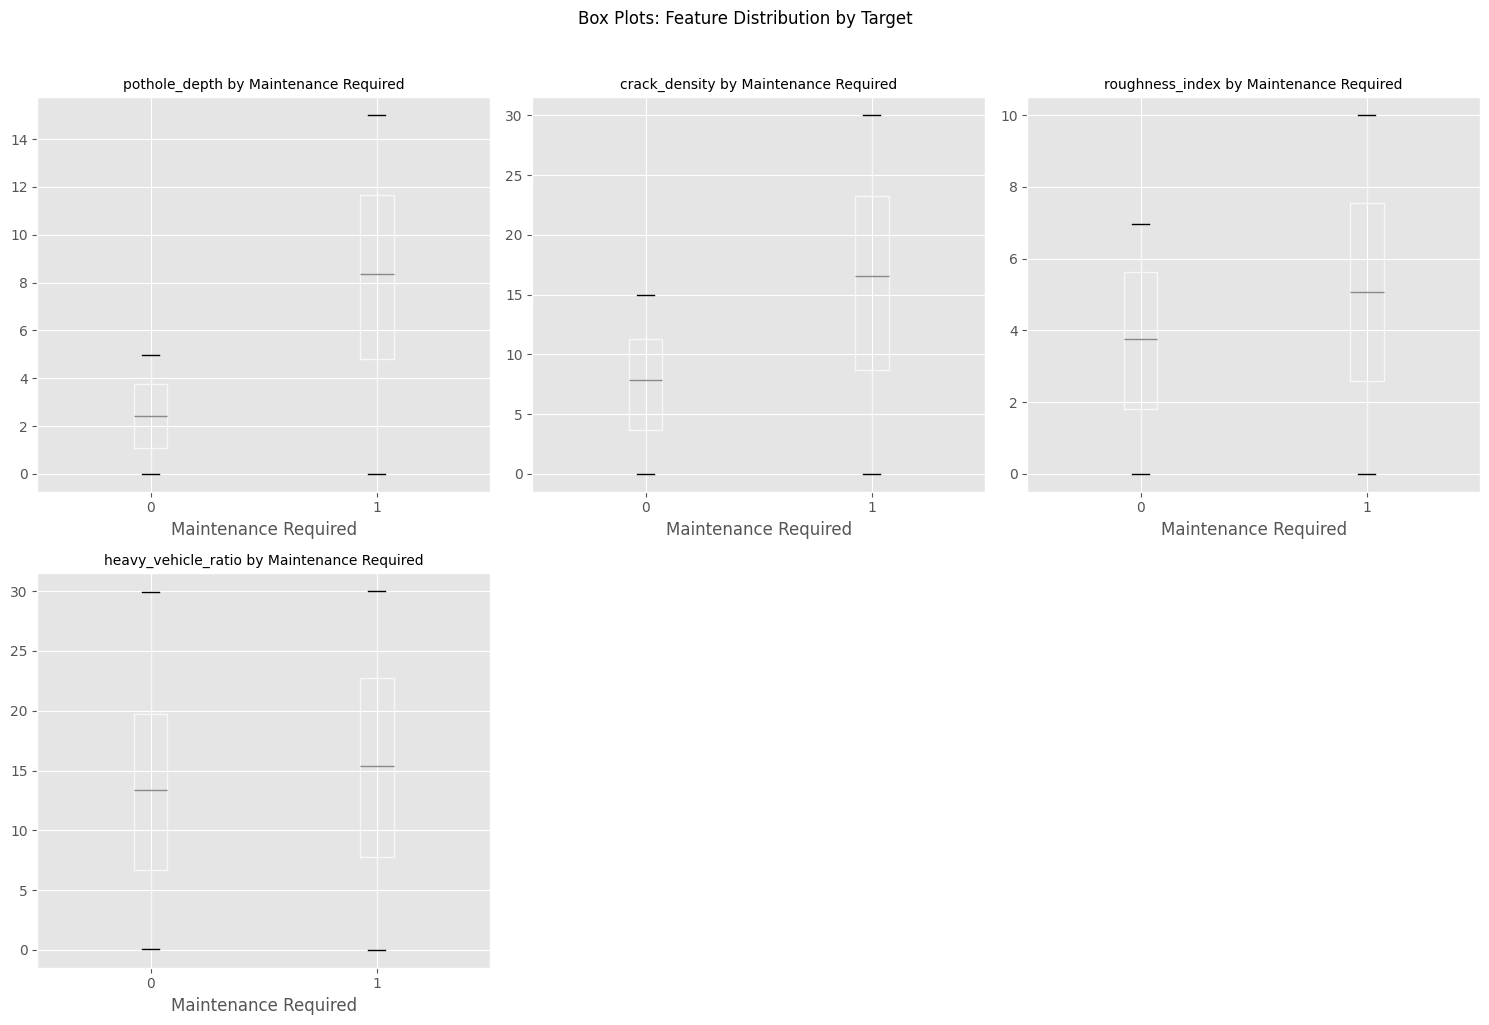

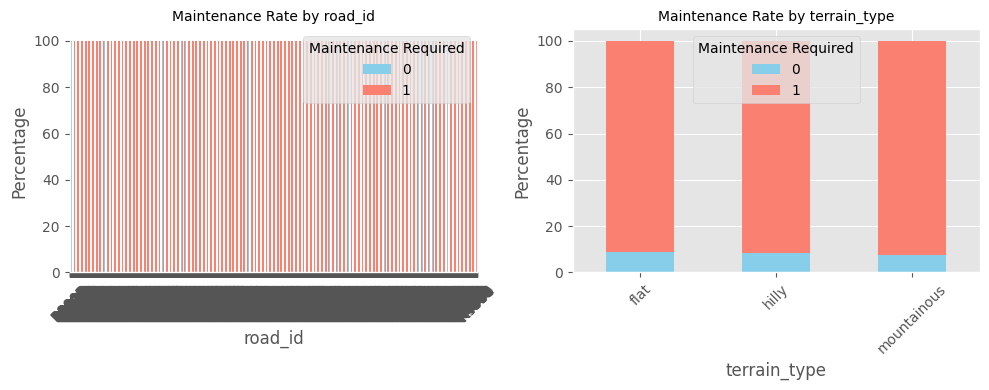

FEATURE ENGINEERING


TypeError: Cannot setitem on a Categorical with a new category (0), set the categories first

In [4]:
# -*- coding: utf-8 -*-
"""Road_Maintenance_Prediction.ipynb

Automatically generated by Colaboratory.

# Road Maintenance Prediction Model
## Data Cleaning and Machine Learning Pipeline
"""

# Install all required packages
!pip install -q xgboost lightgbm catboost shap imbalanced-learn

print("=" * 60)
print("SETUP: Installing required packages...")
print("=" * 60)

"""## 0. File Upload and Setup"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from google.colab import files
import io
warnings.filterwarnings('ignore')

# Check if file exists, if not, prompt for upload
if not os.path.exists('climate_resilient_road_maintenance.csv'):
    print("\n" + "=" * 60)
    print("FILE UPLOAD REQUIRED")
    print("=" * 60)
    print("Please upload the 'climate_resilient_road_maintenance.csv' file")
    uploaded = files.upload()

    # Get the uploaded filename
    for filename in uploaded.keys():
        print(f"\nUploaded: {filename}")
        df = pd.read_csv(io.BytesIO(uploaded[filename]))
else:
    print("\nFile found. Loading...")
    df = pd.read_csv('climate_resilient_road_maintenance.csv')

"""## 1. Import Libraries"""

# Data preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             precision_recall_curve, roc_curve)

# Handling imbalance
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# Feature importance
import shap

# Set style
plt.style.use('ggplot')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

"""## 2. Load and Initial Data Exploration"""

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nBasic Statistics:\n{df.describe().T}")

# Check target variable distribution
print("\n" + "=" * 60)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 60)
print(df['maintenance_required'].value_counts())
print(f"\nPercentage:\n{df['maintenance_required'].value_counts(normalize=True) * 100}")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['maintenance_required'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Maintenance Required Distribution')
axes[0].set_xlabel('Maintenance Required')
axes[0].set_ylabel('Count')

df['maintenance_required'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                               colors=['skyblue', 'salmon'], explode=(0.05, 0.05))
axes[1].set_title('Maintenance Required Proportion')
plt.tight_layout()
plt.show()

"""## 3. Data Cleaning"""

def clean_road_data(df):
    """
    Comprehensive data cleaning function
    """
    df_clean = df.copy()

    print("=" * 60)
    print("DATA CLEANING PROCESS")
    print("=" * 60)

    # 1. Check for duplicates
    initial_shape = df_clean.shape
    df_clean = df_clean.drop_duplicates()
    print(f"Duplicates removed: {initial_shape[0] - df_clean.shape[0]}")

    # 2. Handle missing values
    print("\nMissing Values Before Cleaning:")
    missing_before = df_clean.isnull().sum()
    print(missing_before[missing_before > 0] if any(missing_before > 0) else "No missing values found")

    # For numerical columns: fill with median
    numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    if 'maintenance_required' in numerical_cols:
        numerical_cols.remove('maintenance_required')

    for col in numerical_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

    # For categorical columns: fill with mode
    categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
    for col in categorical_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'Unknown', inplace=True)

    print("\nMissing Values After Cleaning:")
    missing_after = df_clean.isnull().sum()
    print(missing_after[missing_after > 0] if any(missing_after > 0) else "No missing values found")

    # 3. Handle infinite values
    for col in numerical_cols:
        df_clean[col] = df_clean[col].replace([np.inf, -np.inf], np.nan)
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

    # 4. Convert timestamp to datetime and extract features
    if 'timestamp' in df_clean.columns:
        df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
        df_clean['hour'] = df_clean['timestamp'].dt.hour
        df_clean['day'] = df_clean['timestamp'].dt.day
        df_clean['month'] = df_clean['timestamp'].dt.month
        df_clean['day_of_week'] = df_clean['timestamp'].dt.dayofweek
        df_clean['quarter'] = df_clean['timestamp'].dt.quarter

        # Drop original timestamp
        df_clean.drop('timestamp', axis=1, inplace=True)
        print("\nTimestamp converted to datetime features")

    # 5. Encode categorical variables
    if 'terrain_type' in df_clean.columns:
        le_terrain = LabelEncoder()
        df_clean['terrain_type_encoded'] = le_terrain.fit_transform(df_clean['terrain_type'].fillna('unknown'))
        print(f"Terrain types: {dict(zip(le_terrain.classes_, le_terrain.transform(le_terrain.classes_)))}")

    # 6. Outlier detection and capping
    print("\nOutlier Analysis (Before Capping):")
    outlier_counts = {}
    for col in numerical_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)].shape[0]
        outlier_counts[col] = outliers

        # Cap outliers
        df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)

    print(pd.Series(outlier_counts).sort_values(ascending=False).head(10))

    return df_clean, le_terrain if 'terrain_type' in df_clean.columns else None

# Apply cleaning
df_cleaned, terrain_encoder = clean_road_data(df)

print("\n" + "=" * 60)
print("CLEANED DATASET INFO")
print("=" * 60)
print(f"Shape: {df_cleaned.shape}")
print(f"\nColumns: {df_cleaned.columns.tolist()}")
print(f"\nData Types:\n{df_cleaned.dtypes}")

# Final check for any remaining NaN values
print("\n" + "=" * 60)
print("FINAL CHECK FOR NaN VALUES")
print("=" * 60)
nan_count = df_cleaned.isnull().sum().sum()
if nan_count > 0:
    print(f"WARNING: {nan_count} NaN values still present!")
    print(df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])
    # Force fill any remaining NaNs
    df_cleaned = df_cleaned.fillna(df_cleaned.median(numeric_only=True))
    print("All NaNs filled with median values.")
else:
    print("✓ No NaN values found. Data is clean!")

"""## 4. Exploratory Data Analysis (EDA)"""

def perform_eda(df):
    """
    Comprehensive EDA function
    """
    print("=" * 60)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 60)

    # Separate features and target
    X = df.drop('maintenance_required', axis=1)
    y = df['maintenance_required']

    numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

    print(f"Numerical features: {len(numerical_cols)}")
    print(f"Categorical features: {len(categorical_cols)}")

    # 1. Correlation Matrix
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))

    # Correlation heatmap
    corr_matrix = df[numerical_cols + ['maintenance_required']].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=False, fmt='.2f', cmap='RdBu_r',
                center=0, square=True, ax=axes[0, 0], cbar_kws={"shrink": 0.8})
    axes[0, 0].set_title('Feature Correlation Matrix', fontsize=12)

    # Top correlations with target
    target_corr = corr_matrix['maintenance_required'].drop('maintenance_required').sort_values(ascending=False)
    target_corr.head(10).plot(kind='barh', ax=axes[0, 1], color='coral')
    axes[0, 1].set_title('Top 10 Features Correlated with Maintenance Required', fontsize=12)
    axes[0, 1].set_xlabel('Correlation')

    # 2. Distribution of numerical features by target
    top_features = target_corr.head(4).index.tolist() if len(target_corr) >= 4 else target_corr.index.tolist()
    for i, feature in enumerate(top_features):
        if i >= 4:  # Ensure we don't exceed subplot grid
            break
        row, col = (i // 2) + 1, i % 2
        for target_val in [0, 1]:
            subset = df[df['maintenance_required'] == target_val][feature]
            if len(subset) > 0:
                axes[row, col].hist(subset, bins=30, alpha=0.5, label=f'Maintenance={target_val}', density=True)
        axes[row, col].set_title(f'Distribution of {feature} by Target', fontsize=10)
        axes[row, col].legend()
        axes[row, col].set_xlabel(feature)

    plt.tight_layout()
    plt.show()

    # 3. Box plots for key features
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, feature in enumerate(top_features[:6]):
        if i < len(axes):
            df.boxplot(column=feature, by='maintenance_required', ax=axes[i])
            axes[i].set_title(f'{feature} by Maintenance Required', fontsize=10)
            axes[i].set_xlabel('Maintenance Required')

    # Hide any unused subplots
    for i in range(len(top_features[:6]), len(axes)):
        axes[i].set_visible(False)

    plt.suptitle('Box Plots: Feature Distribution by Target', y=1.02)
    plt.tight_layout()
    plt.show()

    # 4. Categorical feature analysis
    if categorical_cols:
        fig, axes = plt.subplots(1, len(categorical_cols), figsize=(5*len(categorical_cols), 4))
        if len(categorical_cols) == 1:
            axes = [axes]

        for i, col in enumerate(categorical_cols):
            ct = pd.crosstab(df[col], df['maintenance_required'], normalize='index') * 100
            ct.plot(kind='bar', stacked=True, ax=axes[i], color=['skyblue', 'salmon'])
            axes[i].set_title(f'Maintenance Rate by {col}', fontsize=10)
            axes[i].set_ylabel('Percentage')
            axes[i].legend(title='Maintenance Required')
            axes[i].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

    return target_corr

# Perform EDA
target_correlations = perform_eda(df_cleaned)

"""## 5. Feature Engineering"""

def create_features(df):
    """
    Create new features based on domain knowledge
    """
    df_fe = df.copy()

    print("=" * 60)
    print("FEATURE ENGINEERING")
    print("=" * 60)

    # 1. Road condition indices
    df_fe['crack_pothole_interaction'] = df_fe['crack_density'] * df_fe['pothole_depth']
    df_fe['roughness_condition'] = df_fe['roughness_index'] * df_fe['crack_density']

    # 2. Weather-related features
    df_fe['temp_humidity_interaction'] = df_fe['surface_temperature'] * df_fe['surface_humidity'] / 100
    df_fe['precipitation_wind'] = df_fe['precipitation_rate'] * df_fe['wind_speed']

    # 3. Traffic-related features
    df_fe['heavy_vehicle_impact'] = df_fe['vehicle_count'] * df_fe['heavy_vehicle_ratio'] / 100
    df_fe['traffic_density'] = df_fe['vehicle_count'] / (df_fe['wind_speed'] + 1)  # Avoid division by zero

    # 4. Location-based features (if coordinates exist)
    if 'location_lat' in df_fe.columns and 'location_lon' in df_fe.columns:
        # Distance from equator (absolute latitude)
        df_fe['abs_latitude'] = np.abs(df_fe['location_lat'])

        # Create climate zones based on latitude
        df_fe['climate_zone'] = pd.cut(df_fe['abs_latitude'],
                                       bins=[0, 23.5, 35, 45, 66.5, 90],
                                       labels=['Tropical', 'Subtropical', 'Temperate', 'Subpolar', 'Polar'])

        # Encode climate zone
        le_zone = LabelEncoder()
        df_fe['climate_zone_encoded'] = le_zone.fit_transform(df_fe['climate_zone'].astype(str))

    # 5. Time-based features
    if all(col in df_fe.columns for col in ['hour', 'day', 'month']):
        # Cyclical encoding for time
        df_fe['hour_sin'] = np.sin(2 * np.pi * df_fe['hour'] / 24)
        df_fe['hour_cos'] = np.cos(2 * np.pi * df_fe['hour'] / 24)
        df_fe['month_sin'] = np.sin(2 * np.pi * df_fe['month'] / 12)
        df_fe['month_cos'] = np.cos(2 * np.pi * df_fe['month'] / 12)

    # 6. Maintenance history features
    if 'maintenance_frequency' in df_fe.columns:
        df_fe['recent_maintenance'] = (df_fe['maintenance_frequency'] > 0).astype(int)
        df_fe['maintenance_cost_per_event'] = df_fe['maintenance_cost'] / (df_fe['maintenance_frequency'] + 1)

    # 7. Rolling averages - Group by road_id and create aggregated features
    if 'road_id' in df_fe.columns:
        road_stats = df_fe.groupby('road_id').agg({
            'crack_density': ['mean', 'std', 'max'],
            'pothole_depth': ['mean', 'max'],
            'roughness_index': ['mean', 'max'],
            'maintenance_frequency': ['mean', 'sum']
        }).round(2)

        # Flatten column names
        road_stats.columns = ['_'.join(col).strip() for col in road_stats.columns.values]
        road_stats = road_stats.reset_index()

        # Merge back
        df_fe = df_fe.merge(road_stats, on='road_id', how='left')

    # 8. Fill any NaN created by feature engineering
    df_fe = df_fe.fillna(0)

    print(f"Features created: {len(df_fe.columns) - len(df.columns)} new features")
    print(f"Total features now: {len(df_fe.columns)}")

    return df_fe

# Apply feature engineering
df_fe = create_features(df_cleaned)

"""## 6. Prepare Data for Modeling"""

def prepare_data_for_modeling(df, target_col='maintenance_required'):
    """
    Prepare data for machine learning models
    """
    print("=" * 60)
    print("DATA PREPARATION FOR MODELING")
    print("=" * 60)

    # Identify columns to drop
    cols_to_drop = [target_col]
    drop_candidates = ['road_id', 'terrain_type', 'climate_zone']
    for col in drop_candidates:
        if col in df.columns:
            cols_to_drop.append(col)

    # Separate features and target
    X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
    y = df[target_col]

    print(f"Feature matrix shape: {X.shape}")
    print(f"Target vector shape: {y.shape}")
    print(f"\nTarget distribution:\n{y.value_counts()}")

    # Check for NaN values in X and fill them
    nan_in_X = X.isnull().sum().sum()
    if nan_in_X > 0:
        print(f"\nWARNING: {nan_in_X} NaN values found in features!")
        print("Filling with 0...")
        X = X.fillna(0)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\nTrain set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")

    # Get numerical columns for scaling
    numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    # Remove any constant columns
    constant_cols = []
    for col in numerical_cols:
        if X_train[col].nunique() == 1:
            constant_cols.append(col)

    if constant_cols:
        print(f"\nDropping constant columns: {constant_cols}")
        X_train = X_train.drop(columns=constant_cols)
        X_test = X_test.drop(columns=constant_cols)
        numerical_cols = [col for col in numerical_cols if col not in constant_cols]

    # Scale numerical features
    scaler = RobustScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    if numerical_cols:
        X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
        X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

    print(f"\nFeatures after scaling: {X_train_scaled.shape[1]}")

    # Final check for NaN values in scaled data
    if X_train_scaled.isnull().sum().sum() > 0:
        print("WARNING: NaN values still present! Filling with 0...")
        X_train_scaled = X_train_scaled.fillna(0)
        X_test_scaled = X_test_scaled.fillna(0)

    print("✓ Data preparation complete. No NaN values remaining.")

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, numerical_cols

# Prepare data
X_train, X_test, y_train, y_test, scaler, numerical_features = prepare_data_for_modeling(df_fe)

"""## 7. Handle Class Imbalance"""

def handle_class_imbalance(X_train, y_train, method='smote'):
    """
    Handle class imbalance using various techniques
    """
    print("=" * 60)
    print("HANDLING CLASS IMBALANCE")
    print("=" * 60)

    print(f"Original class distribution: {pd.Series(y_train).value_counts().to_dict()}")

    # Double-check for NaN values before SMOTE
    if X_train.isnull().sum().sum() > 0:
        print("WARNING: NaN values found before SMOTE! Filling with 0...")
        X_train = X_train.fillna(0)

    try:
        if method == 'smote':
            sampler = SMOTE(random_state=42)
            X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
        elif method == 'adasyn':
            sampler = ADASYN(random_state=42)
            X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
        elif method == 'smote_tomek':
            sampler = SMOTETomek(random_state=42)
            X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
        else:
            return X_train, y_train

        print(f"Resampled class distribution: {pd.Series(y_resampled).value_counts().to_dict()}")
        print(f"Resampled shape: {X_resampled.shape}")

        return X_resampled, y_resampled

    except Exception as e:
        print(f"Error in SMOTE: {e}")
        print("Proceeding with original data...")
        return X_train, y_train

# Apply SMOTE
X_train_resampled, y_train_resampled = handle_class_imbalance(X_train, y_train, method='smote')

"""## 8. Model Training and Evaluation"""

def train_evaluate_models(X_train, y_train, X_test, y_test):
    """
    Train multiple models and evaluate performance
    """
    print("=" * 60)
    print("MODEL TRAINING AND EVALUATION")
    print("=" * 60)

    # Calculate scale_pos_weight for XGBoost
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]) if len(y_train[y_train==1]) > 0 else 1

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10),
        'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
        'AdaBoost': AdaBoostClassifier(random_state=42, n_estimators=100),
        'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss',
                                 scale_pos_weight=scale_pos_weight),
        'LightGBM': LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced'),
        'CatBoost': CatBoostClassifier(random_state=42, verbose=0, auto_class_weights='Balanced')
    }

    results = []
    trained_models = {}
    best_model = None
    best_score = 0
    best_model_name = None

    for name, model in models.items():
        print(f"\n{'-'*40}")
        print(f"Training {name}...")

        try:
            # Train model
            model.fit(X_train, y_train)
            trained_models[name] = model

            # Predictions
            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

            # Metrics
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, zero_division=0)
            recall = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)

            if y_pred_proba is not None:
                auc = roc_auc_score(y_test, y_pred_proba)
            else:
                auc = 0

            # Store results
            results.append({
                'Model': name,
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1 Score': f1,
                'AUC-ROC': auc
            })

            print(f"Accuracy: {accuracy:.4f}")
            print(f"Precision: {precision:.4f}")
            print(f"Recall: {recall:.4f}")
            print(f"F1 Score: {f1:.4f}")
            print(f"AUC-ROC: {auc:.4f}")

            # Track best model based on F1 score
            if f1 > best_score:
                best_score = f1
                best_model = model
                best_model_name = name

        except Exception as e:
            print(f"Error training {name}: {e}")
            continue

    # Create results DataFrame
    if results:
        results_df = pd.DataFrame(results)
        results_df = results_df.sort_values('F1 Score', ascending=False)

        print("\n" + "=" * 60)
        print("MODEL COMPARISON SUMMARY")
        print("=" * 60)
        print(results_df.to_string(index=False))
    else:
        results_df = pd.DataFrame()
        print("No models were successfully trained!")

    return results_df, best_model, best_model_name, trained_models

# Train models
results_df, best_model, best_model_name, trained_models = train_evaluate_models(
    X_train_resampled, y_train_resampled, X_test, y_test
)

"""## 9. Visualize Model Performance"""

def visualize_model_performance(results_df, X_test, y_test, best_model, best_model_name):
    """
    Visualize model performance metrics
    """
    print("=" * 60)
    print("VISUALIZING MODEL PERFORMANCE")
    print("=" * 60)

    if results_df.empty or best_model is None:
        print("No models to visualize!")
        return best_model

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 1. Model comparison bar plot
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
    results_melted = results_df.melt(id_vars=['Model'], value_vars=metrics,
                                      var_name='Metric', value_name='Score')

    sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', ax=axes[0, 0])
    axes[0, 0].set_title('Model Performance Comparison', fontsize=12)
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # 2. Confusion Matrix for best model
    y_pred_best = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_best)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
    axes[0, 1].set_title(f'Confusion Matrix - {best_model_name}', fontsize=12)
    axes[0, 1].set_xlabel('Predicted')
    axes[0, 1].set_ylabel('Actual')

    # 3. ROC Curve
    if hasattr(best_model, 'predict_proba'):
        y_pred_proba = best_model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc = roc_auc_score(y_test, y_pred_proba)

        axes[0, 2].plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc:.3f})', linewidth=2)
        axes[0, 2].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
        axes[0, 2].set_xlabel('False Positive Rate')
        axes[0, 2].set_ylabel('True Positive Rate')
        axes[0, 2].set_title('ROC Curve', fontsize=12)
        axes[0, 2].legend(loc='lower right')
        axes[0, 2].grid(True)

    # 4. Precision-Recall Curve
    if hasattr(best_model, 'predict_proba'):
        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
        axes[1, 0].plot(recall_vals, precision_vals, linewidth=2)
        axes[1, 0].set_xlabel('Recall')
        axes[1, 0].set_ylabel('Precision')
        axes[1, 0].set_title('Precision-Recall Curve', fontsize=12)
        axes[1, 0].grid(True)

    # 5. Feature Importance (for tree-based models)
    if hasattr(best_model, 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'feature': X_test.columns,
            'importance': best_model.feature_importances_
        }).sort_values('importance', ascending=False).head(15)

        sns.barplot(data=feature_importance, y='feature', x='importance', ax=axes[1, 1])
        axes[1, 1].set_title(f'Top 15 Feature Importances - {best_model_name}', fontsize=12)
        axes[1, 1].set_xlabel('Importance')

    # 6. Classification report as heatmap
    report = classification_report(y_test, y_pred_best, output_dict=True)
    report_df = pd.DataFrame(report).iloc[:-1, :3]  # Remove support row, take first 3 columns

    sns.heatmap(report_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1, 2])
    axes[1, 2].set_title('Classification Report', fontsize=12)

    plt.tight_layout()
    plt.show()

    return best_model

# Visualize performance
if best_model is not None:
    best_model = visualize_model_performance(results_df, X_test, y_test, best_model, best_model_name)
else:
    print("No best model found. Skipping visualization.")

"""## 10. Hyperparameter Tuning for Best Model"""

def tune_best_model(X_train, y_train, X_test, y_test, best_model_name, trained_models):
    """
    Perform hyperparameter tuning for the best performing model
    """
    print("=" * 60)
    print(f"HYPERPARAMETER TUNING FOR {best_model_name}")
    print("=" * 60)

    if best_model_name is None:
        print("No best model to tune.")
        return None, None

    # Define parameter grids for different models
    param_grids = {
        'Random Forest': {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        },
        'XGBoost': {
            'n_estimators': [100, 200],
            'max_depth': [3, 6],
            'learning_rate': [0.01, 0.1],
            'subsample': [0.8, 1.0]
        },
        'LightGBM': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, -1],
            'learning_rate': [0.01, 0.1],
            'num_leaves': [31, 50]
        },
        'Gradient Boosting': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5],
            'learning_rate': [0.01, 0.1]
        },
        'Decision Tree': {
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [2, 5, 10]
        },
        'CatBoost': {
            'iterations': [100, 200],
            'depth': [4, 6],
            'learning_rate': [0.01, 0.1]
        }
    }

    # Find matching model in param_grids
    matching_key = None
    for key in param_grids.keys():
        if key in best_model_name:
            matching_key = key
            break

    if matching_key is None:
        print(f"No tuning defined for {best_model_name}. Using default parameters.")
        return trained_models.get(best_model_name), None

    # Get the model from trained_models
    model = trained_models.get(best_model_name)
    if model is None:
        print(f"Model {best_model_name} not found in trained models.")
        return None, None

    # Perform grid search with cross-validation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # Using 3 folds for speed

    grid_search = GridSearchCV(
        estimator=model.__class__(**model.get_params()),
        param_grid=param_grids[matching_key],
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    print(f"\nStarting Grid Search for {best_model_name}...")
    grid_search.fit(X_train, y_train)

    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best cross-validation F1 score: {grid_search.best_score_:.4f}")

    # Evaluate on test set
    best_tuned_model = grid_search.best_estimator_
    y_pred = best_tuned_model.predict(X_test)
    y_pred_proba = best_tuned_model.predict_proba(X_test)[:, 1]

    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"\nTest set performance:")
    print(f"F1 Score: {test_f1:.4f}")
    print(f"AUC-ROC: {test_auc:.4f}")

    return best_tuned_model, grid_search.best_params_

# Tune the best model
if best_model_name is not None:
    best_tuned_model, best_params = tune_best_model(
        X_train_resampled, y_train_resampled, X_test, y_test, best_model_name, trained_models
    )
    if best_tuned_model is not None:
        best_model = best_tuned_model
else:
    best_params = None

"""## 11. SHAP Analysis for Model Interpretability"""

def shap_analysis(model, X_train, X_test, feature_names):
    """
    Perform SHAP analysis to understand feature importance
    """
    print("=" * 60)
    print("SHAP ANALYSIS FOR MODEL INTERPRETABILITY")
    print("=" * 60)

    if model is None:
        print("No model available for SHAP analysis.")
        return

    try:
        # Use a sample for SHAP if dataset is large
        X_sample = X_test.sample(min(100, len(X_test)), random_state=42)

        # Create SHAP explainer based on model type
        if hasattr(model, 'get_booster'):  # XGBoost
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)
        elif hasattr(model, 'booster_'):  # LightGBM
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)
        elif isinstance(model, (RandomForestClassifier, GradientBoostingClassifier,
                                AdaBoostClassifier, DecisionTreeClassifier)):
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)
        else:
            # For non-tree models, use KernelExplainer (slower)
            explainer = shap.KernelExplainer(model.predict_proba, X_train.sample(50, random_state=42))
            shap_values = explainer.shap_values(X_sample)[1]  # For class 1

        # Summary plot - Bar
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                         plot_type="bar", show=False, max_display=15)
        plt.title('Feature Importance (Mean |SHAP Value|)', fontsize=14)
        plt.tight_layout()
        plt.show()

        # Summary plot - Beeswarm
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                         show=False, max_display=15)
        plt.title('SHAP Values Impact on Model Output', fontsize=14)
        plt.tight_layout()
        plt.show()

        print("SHAP analysis completed successfully!")

    except Exception as e:
        print(f"Error in SHAP analysis: {e}")
        print("Skipping SHAP analysis...")

# Perform SHAP analysis for the best model
if best_model is not None:
    feature_names = X_test.columns.tolist()
    shap_analysis(best_model, X_train_resampled, X_test, feature_names)

"""## 12. Final Model Evaluation and Summary"""

def final_model_evaluation(model, X_test, y_test, feature_names, best_model_name):
    """
    Final comprehensive model evaluation
    """
    print("=" * 60)
    print("FINAL MODEL EVALUATION")
    print("=" * 60)

    if model is None:
        print("No model available for evaluation.")
        return None

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate all metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    print(f"\nModel: {best_model_name}")
    print(f"\nPerformance Metrics:")
    print(f"{'='*40}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")

    print(f"\nClassification Report:")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred, target_names=['No Maintenance', 'Maintenance Required']))

    # Feature importance (if available)
    importance_df = None
    if hasattr(model, 'feature_importances_'):
        print(f"\nTop 10 Most Important Features:")
        print(f"{'='*40}")
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=False).head(10)

        for idx, row in importance_df.iterrows():
            print(f"{row['Feature']:<30} : {row['Importance']:.4f}")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc_roc': auc,
        'model': model,
        'feature_importance': importance_df
    }

# Final evaluation
if best_model is not None:
    final_results = final_model_evaluation(best_model, X_test, y_test, feature_names, best_model_name)
else:
    final_results = None
    print("No best model available for final evaluation.")

"""## 13. Save Model and Preprocessing Objects"""

import joblib
import pickle
from datetime import datetime

def save_model_artifacts(model, scaler, feature_names, best_params, results_df, filename_prefix='road_maintenance_model'):
    """
    Save model and preprocessing objects for future use
    """
    print("=" * 60)
    print("SAVING MODEL ARTIFACTS")
    print("=" * 60)

    if model is None:
        print("No model to save.")
        return None

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Save model
    model_filename = f"{filename_prefix}_{timestamp}.pkl"
    joblib.dump(model, model_filename)
    print(f"Model saved as: {model_filename}")

    # Save scaler
    scaler_filename = f"scaler_{timestamp}.pkl"
    joblib.dump(scaler, scaler_filename)
    print(f"Scaler saved as: {scaler_filename}")

    # Save feature names
    features_filename = f"features_{timestamp}.txt"
    with open(features_filename, 'w') as f:
        for feature in feature_names:
            f.write(f"{feature}\n")
    print(f"Feature names saved as: {features_filename}")

    # Save results summary
    if results_df is not None and not results_df.empty:
        results_filename = f"results_{timestamp}.csv"
        results_df.to_csv(results_filename, index=False)
        print(f"Results saved as: {results_filename}")

    # Save best parameters
    if best_params:
        params_filename = f"best_params_{timestamp}.txt"
        with open(params_filename, 'w') as f:
            for param, value in best_params.items():
                f.write(f"{param}: {value}\n")
        print(f"Best parameters saved as: {params_filename}")

    print("\nAll artifacts saved successfully!")

    return {
        'model_file': model_filename,
        'scaler_file': scaler_filename,
        'features_file': features_filename
    }

# Save the model and artifacts
if best_model is not None:
    saved_files = save_model_artifacts(best_model, scaler, feature_names, best_params, results_df)
else:
    print("No model to save.")

"""## 14. Prediction Function for New Data"""

def predict_maintenance(model, scaler, feature_names, new_data):
    """
    Predict maintenance requirement for new road data
    """
    print("=" * 60)
    print("PREDICTING MAINTENANCE FOR NEW DATA")
    print("=" * 60)

    if model is None:
        print("No model available for prediction.")
        return None

    # Ensure new_data has the same features
    missing_features = set(feature_names) - set(new_data.columns)
    if missing_features:
        print(f"Warning: Missing features: {missing_features}")
        # Add missing features with default values (0)
        for feature in missing_features:
            new_data[feature] = 0

    # Reorder columns to match training data
    new_data = new_data[feature_names]

    # Fill any NaN values
    new_data = new_data.fillna(0)

    # Scale the data
    new_data_scaled = scaler.transform(new_data)

    # Make predictions
    predictions = model.predict(new_data_scaled)
    probabilities = model.predict_proba(new_data_scaled)

    # Create results DataFrame
    results = pd.DataFrame({
        'Prediction': predictions,
        'Prediction_Label': ['Maintenance Required' if p == 1 else 'No Maintenance' for p in predictions],
        'Probability_No_Maintenance': probabilities[:, 0],
        'Probability_Maintenance': probabilities[:, 1]
    })

    print(f"\nPredictions for {len(new_data)} samples:")
    print(results)

    return results

# Example usage (commented out)
# if best_model is not None:
#     new_data_sample = X_test.head(5)
#     predictions = predict_maintenance(best_model, scaler, feature_names, new_data_sample)

"""## 15. Summary Report"""

def generate_summary_report(results_df, final_results, best_model_name, best_params, df):
    """
    Generate a comprehensive summary report
    """
    print("=" * 60)
    print("PROJECT SUMMARY REPORT")
    print("=" * 60)
    print("\n" + "="*60)
    print("ROAD MAINTENANCE PREDICTION MODEL")
    print("="*60)

    print(f"\nDate: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    print(f"\n{'DATASET INFORMATION':^60}")
    print("-"*60)
    print(f"Total samples: {df.shape[0]}")
    print(f"Total features: {df.shape[1] - 1} (excluding target)")
    print(f"Target distribution:")
    print(f"  - No Maintenance: {df['maintenance_required'].value_counts()[0]} ({df['maintenance_required'].value_counts(normalize=True)[0]*100:.1f}%)")
    print(f"  - Maintenance Required: {df['maintenance_required'].value_counts()[1]} ({df['maintenance_required'].value_counts(normalize=True)[1]*100:.1f}%)")

    if final_results:
        print(f"\n{'MODEL PERFORMANCE':^60}")
        print("-"*60)
        print(f"Best Model: {best_model_name}")
        print(f"\nTest Set Performance:")
        print(f"  - Accuracy:  {final_results['accuracy']:.4f}")
        print(f"  - Precision: {final_results['precision']:.4f}")
        print(f"  - Recall:    {final_results['recall']:.4f}")
        print(f"  - F1 Score:  {final_results['f1_score']:.4f}")
        print(f"  - AUC-ROC:   {final_results['auc_roc']:.4f}")

    if best_params:
        print(f"\nBest Hyperparameters:")
        for param, value in best_params.items():
            print(f"  - {param}: {value}")

    if results_df is not None and not results_df.empty:
        print(f"\n{'MODEL COMPARISON':^60}")
        print("-"*60)
        print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']].round(4).to_string(index=False))

    if final_results and final_results['feature_importance'] is not None:
        print(f"\n{'TOP 10 FEATURE IMPORTANCE':^60}")
        print("-"*60)
        for idx, row in final_results['feature_importance'].iterrows():
            print(f"  {row['Feature']:<30} : {row['Importance']:.4f}")

    print(f"\n{'='*60}")
    print("Analysis Complete!")
    print("="*60)

# Generate final summary
generate_summary_report(results_df, final_results, best_model_name, best_params, df)

print("\n" + "=" * 60)
print("NOTEBOOK EXECUTION COMPLETED SUCCESSFULLY!")
print("=" * 60)
print("\nAll analyses, model training, and evaluations are complete.")
print("The best model has been saved and can be used for future predictions.")

SETUP: Installing required packages...

File found. Loading...
DATASET OVERVIEW
Dataset Shape: (5000, 19)

Columns: ['road_id', 'timestamp', 'surface_temperature', 'surface_humidity', 'precipitation_rate', 'crack_density', 'pothole_depth', 'roughness_index', 'wind_speed', 'solar_radiation', 'vehicle_count', 'heavy_vehicle_ratio', 'maintenance_frequency', 'maintenance_cost', 'location_lat', 'location_lon', 'terrain_type', 'extreme_weather_event', 'maintenance_required']

Data Types:
road_id                   object
timestamp                 object
surface_temperature      float64
surface_humidity         float64
precipitation_rate       float64
crack_density            float64
pothole_depth            float64
roughness_index          float64
wind_speed               float64
solar_radiation          float64
vehicle_count              int64
heavy_vehicle_ratio      float64
maintenance_frequency      int64
maintenance_cost         float64
location_lat             float64
location_lon      

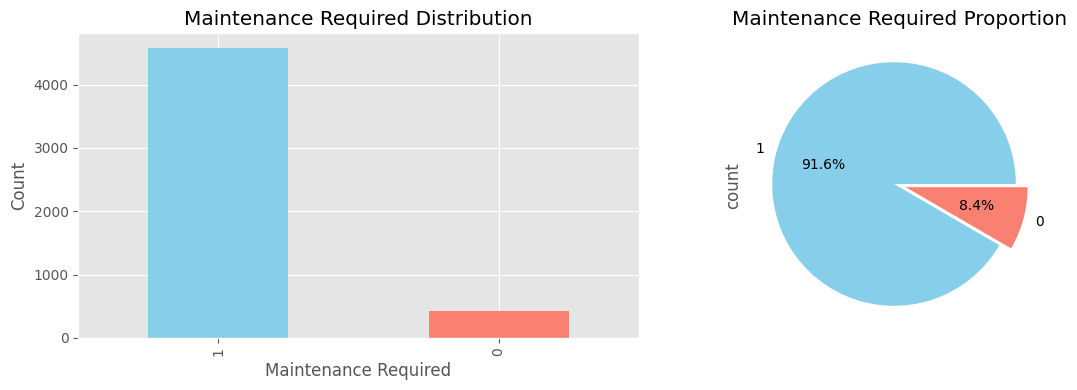

DATA CLEANING PROCESS
Duplicates removed: 0

Missing Values Before Cleaning:
No missing values found

Missing Values After Cleaning:
No missing values found

Timestamp converted to datetime features
Terrain types: {'flat': np.int64(0), 'hilly': np.int64(1), 'mountainous': np.int64(2)}

Outlier Analysis (Before Capping):
extreme_weather_event    1018
surface_humidity            0
surface_temperature         0
crack_density               0
pothole_depth               0
roughness_index             0
precipitation_rate          0
wind_speed                  0
solar_radiation             0
heavy_vehicle_ratio         0
dtype: int64

CLEANED DATASET INFO
Shape: (5000, 24)

Columns: ['road_id', 'surface_temperature', 'surface_humidity', 'precipitation_rate', 'crack_density', 'pothole_depth', 'roughness_index', 'wind_speed', 'solar_radiation', 'vehicle_count', 'heavy_vehicle_ratio', 'maintenance_frequency', 'maintenance_cost', 'location_lat', 'location_lon', 'terrain_type', 'extreme_weather_ev

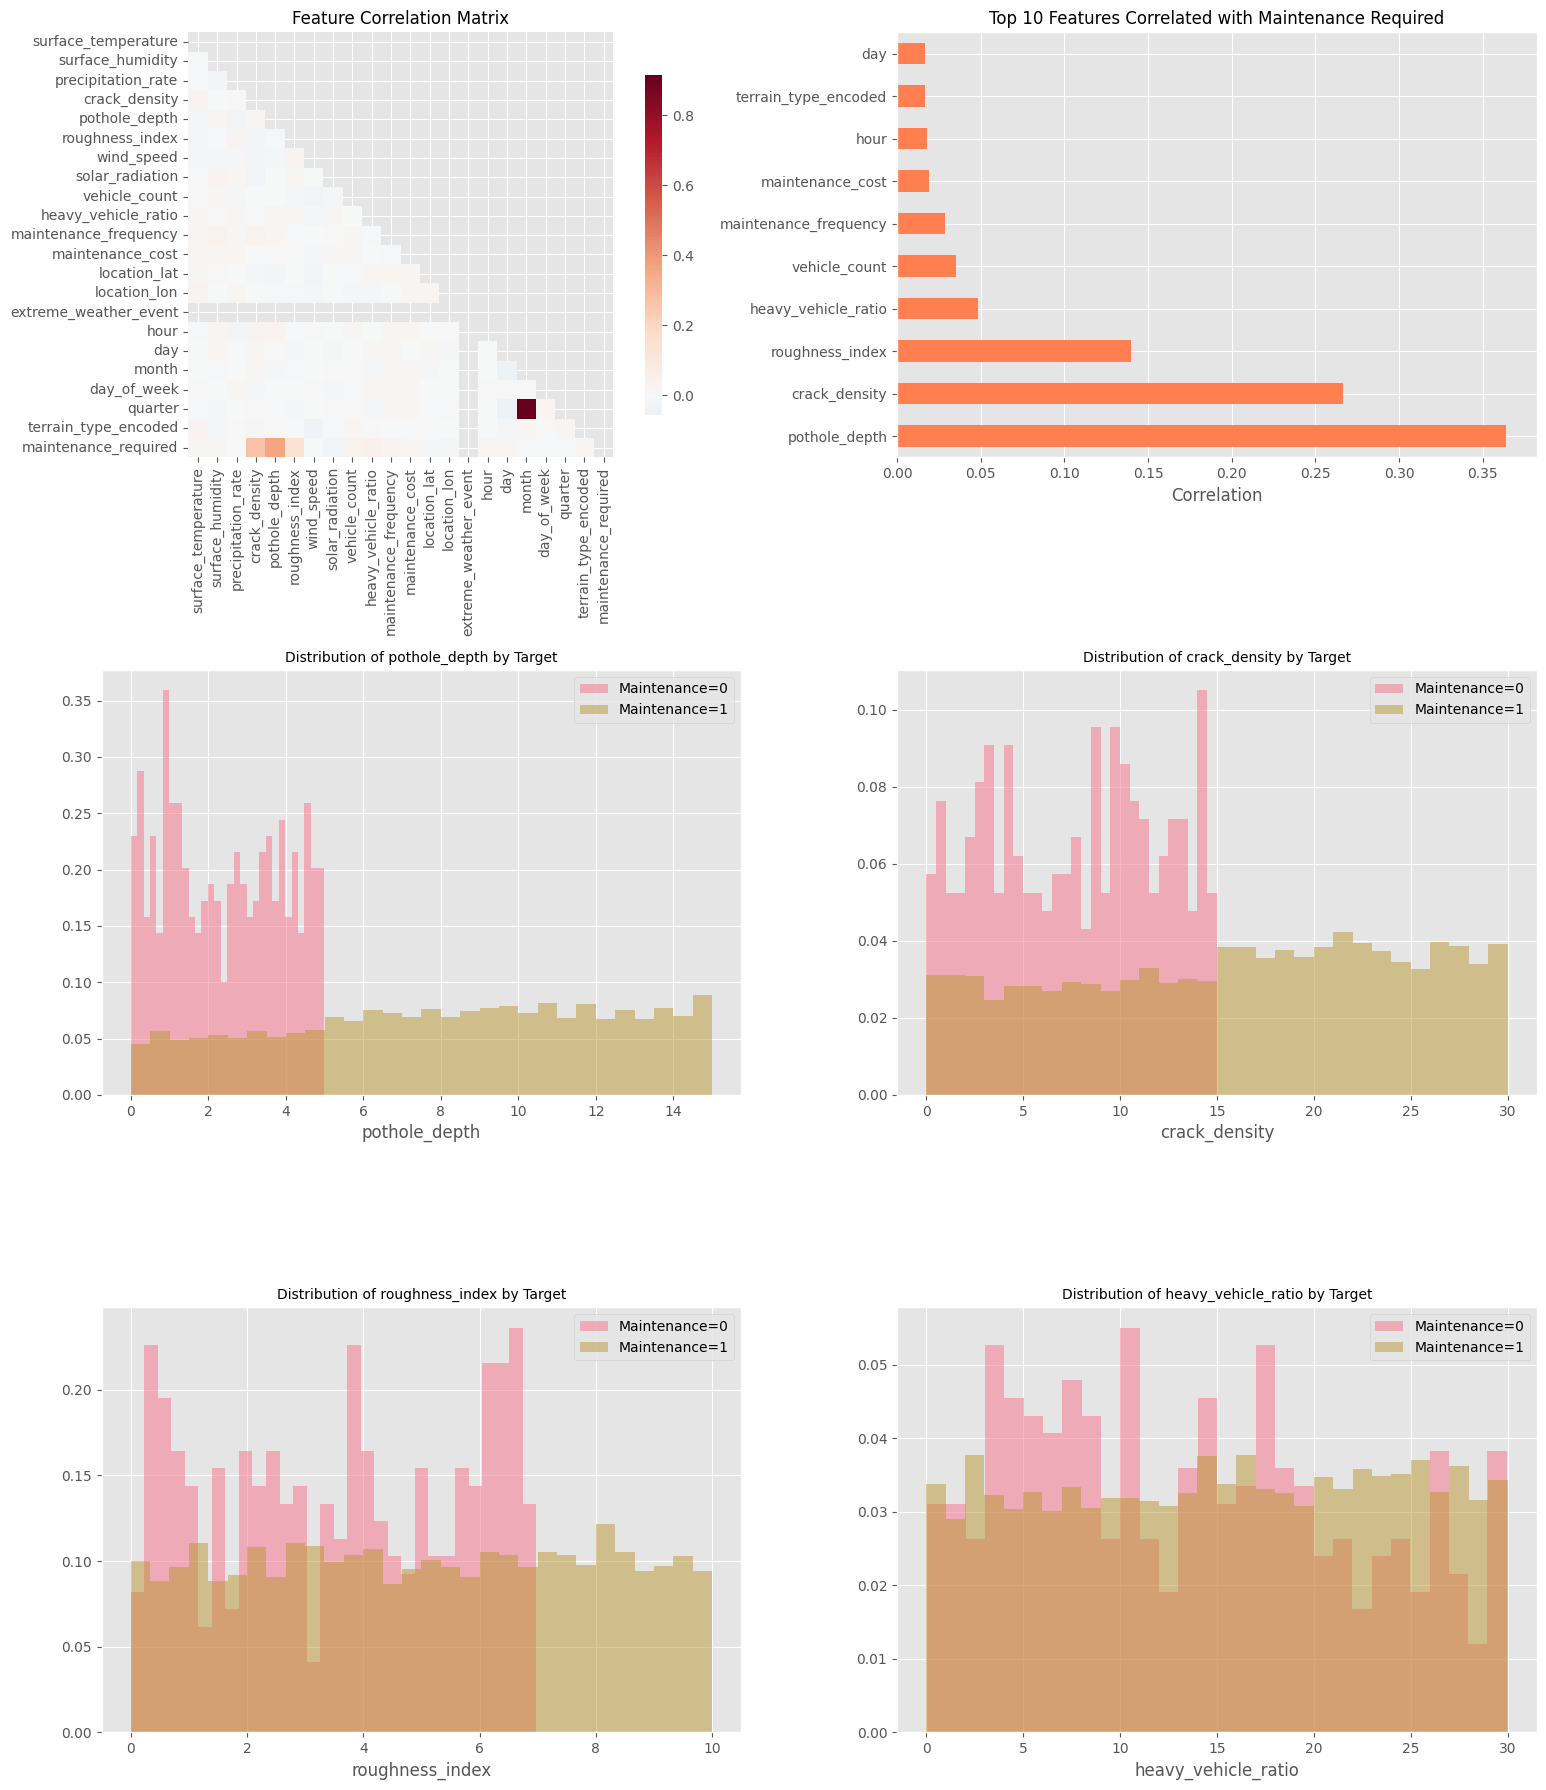

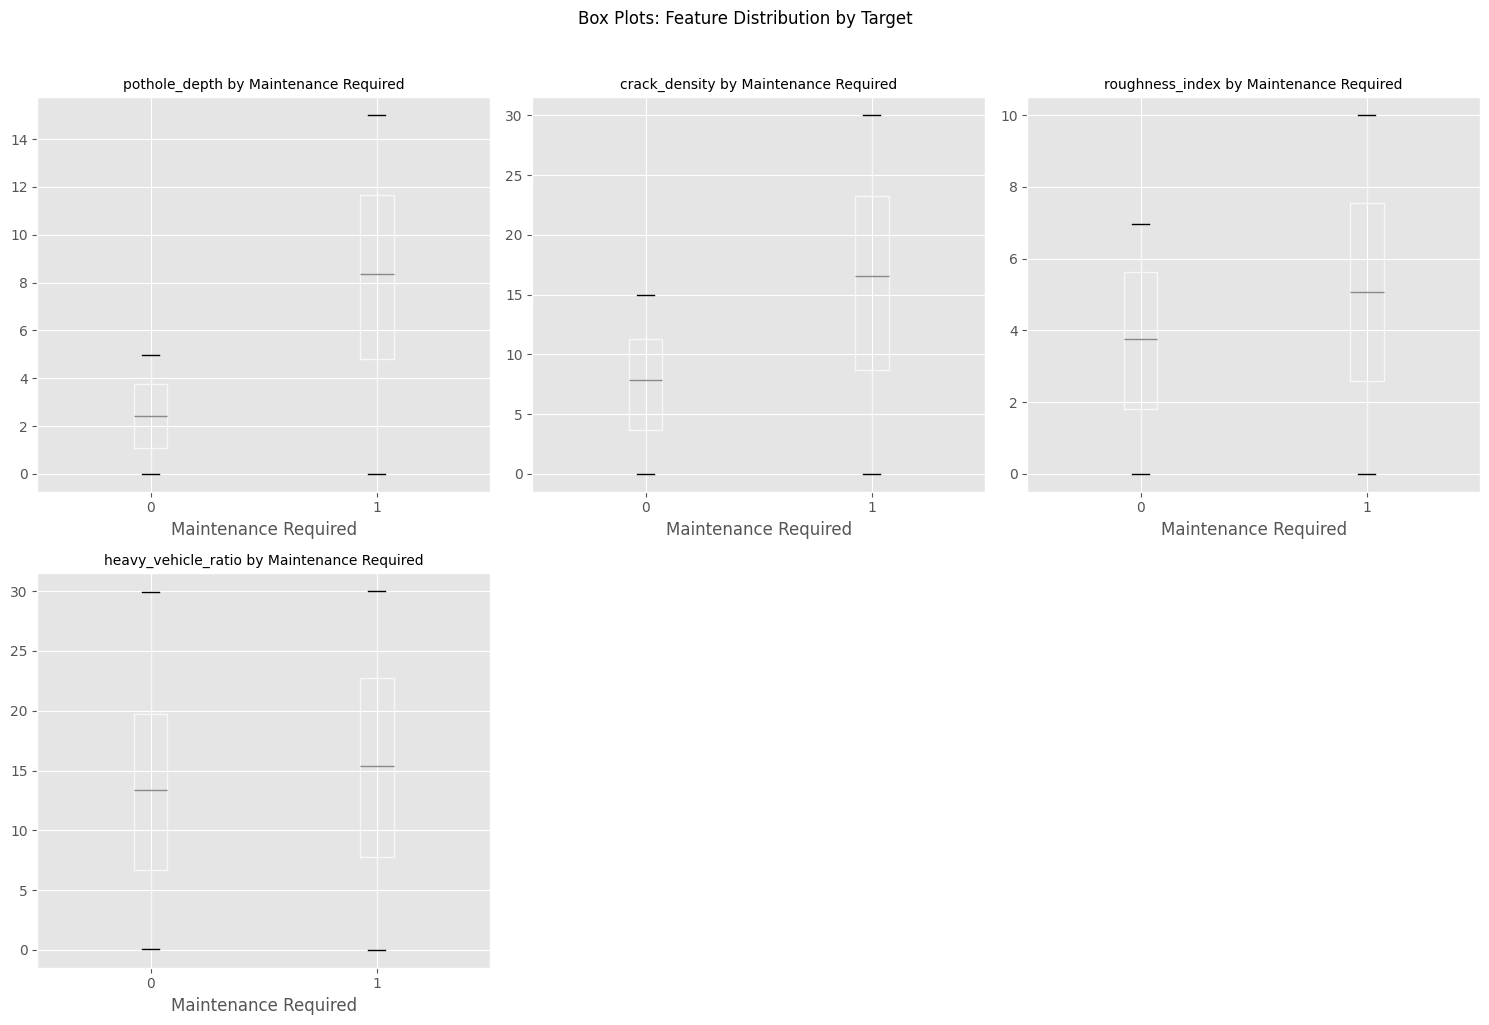

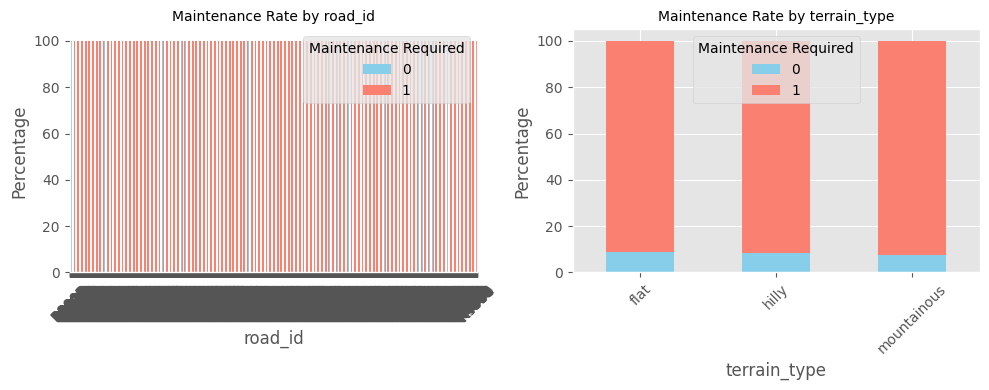

FEATURE ENGINEERING
Features created: 24 new features
Total features now: 48
DATA PREPARATION FOR MODELING
Feature matrix shape: (5000, 44)
Target vector shape: (5000,)

Target distribution:
maintenance_required
1    4581
0     419
Name: count, dtype: int64

Train set: (4000, 44)
Test set: (1000, 44)

Dropping constant columns: ['extreme_weather_event', 'crack_density_std']

Features after scaling: 42
✓ Data preparation complete. No NaN values remaining.
HANDLING CLASS IMBALANCE
Original class distribution: {1: 3665, 0: 335}
Resampled class distribution: {1: 3665, 0: 3665}
Resampled shape: (7330, 42)
MODEL TRAINING AND EVALUATION

----------------------------------------
Training Logistic Regression...
Accuracy: 0.9100
Precision: 0.9928
Recall: 0.9083
F1 Score: 0.9487
AUC-ROC: 0.9728

----------------------------------------
Training Decision Tree...
Accuracy: 0.9740
Precision: 0.9933
Recall: 0.9782
F1 Score: 0.9857
AUC-ROC: 0.9583

----------------------------------------
Training Ran

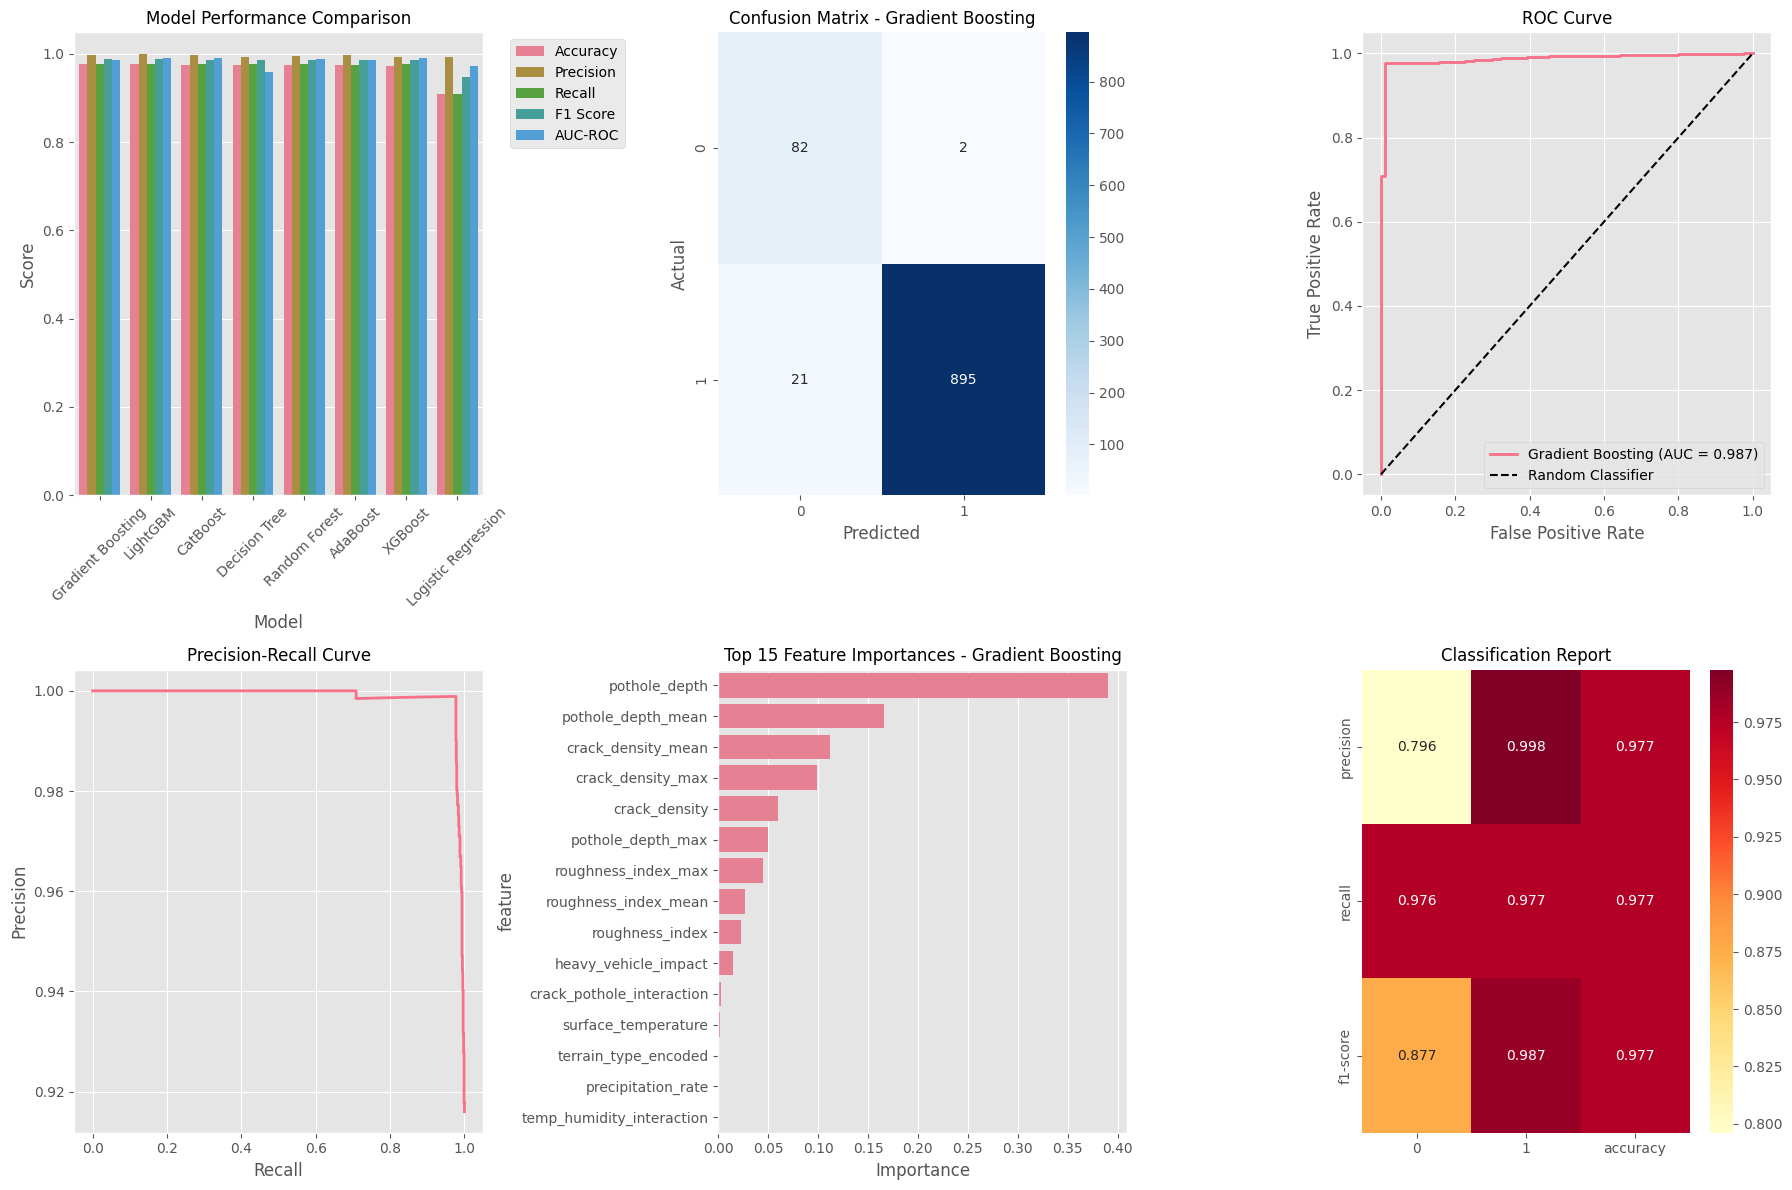

HYPERPARAMETER TUNING FOR Gradient Boosting

Starting Grid Search for Gradient Boosting...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


In [ ]:
# -*- coding: utf-8 -*-
"""Road_Maintenance_Prediction.ipynb

Automatically generated by Colaboratory.

# Road Maintenance Prediction Model
## Data Cleaning and Machine Learning Pipeline
"""

# Install all required packages
!pip install -q xgboost lightgbm catboost shap imbalanced-learn

print("=" * 60)
print("SETUP: Installing required packages...")
print("=" * 60)

"""## 0. File Upload and Setup"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from google.colab import files
import io
warnings.filterwarnings('ignore')

# Check if file exists, if not, prompt for upload
if not os.path.exists('climate_resilient_road_maintenance.csv'):
    print("\n" + "=" * 60)
    print("FILE UPLOAD REQUIRED")
    print("=" * 60)
    print("Please upload the 'climate_resilient_road_maintenance.csv' file")
    uploaded = files.upload()

    # Get the uploaded filename
    for filename in uploaded.keys():
        print(f"\nUploaded: {filename}")
        df = pd.read_csv(io.BytesIO(uploaded[filename]))
else:
    print("\nFile found. Loading...")
    df = pd.read_csv('climate_resilient_road_maintenance.csv')

"""## 1. Import Libraries"""

# Data preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             precision_recall_curve, roc_curve)

# Handling imbalance
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# Feature importance
import shap

# Set style
plt.style.use('ggplot')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

"""## 2. Load and Initial Data Exploration"""

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nBasic Statistics:\n{df.describe().T}")

# Check target variable distribution
print("\n" + "=" * 60)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 60)
print(df['maintenance_required'].value_counts())
print(f"\nPercentage:\n{df['maintenance_required'].value_counts(normalize=True) * 100}")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['maintenance_required'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Maintenance Required Distribution')
axes[0].set_xlabel('Maintenance Required')
axes[0].set_ylabel('Count')

df['maintenance_required'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                               colors=['skyblue', 'salmon'], explode=(0.05, 0.05))
axes[1].set_title('Maintenance Required Proportion')
plt.tight_layout()
plt.show()

"""## 3. Data Cleaning"""

def clean_road_data(df):
    """
    Comprehensive data cleaning function
    """
    df_clean = df.copy()

    print("=" * 60)
    print("DATA CLEANING PROCESS")
    print("=" * 60)

    # 1. Check for duplicates
    initial_shape = df_clean.shape
    df_clean = df_clean.drop_duplicates()
    print(f"Duplicates removed: {initial_shape[0] - df_clean.shape[0]}")

    # 2. Handle missing values
    print("\nMissing Values Before Cleaning:")
    missing_before = df_clean.isnull().sum()
    print(missing_before[missing_before > 0] if any(missing_before > 0) else "No missing values found")

    # For numerical columns: fill with median
    numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    if 'maintenance_required' in numerical_cols:
        numerical_cols.remove('maintenance_required')

    for col in numerical_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

    # For categorical columns: fill with mode
    categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
    for col in categorical_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'Unknown', inplace=True)

    print("\nMissing Values After Cleaning:")
    missing_after = df_clean.isnull().sum()
    print(missing_after[missing_after > 0] if any(missing_after > 0) else "No missing values found")

    # 3. Handle infinite values
    for col in numerical_cols:
        df_clean[col] = df_clean[col].replace([np.inf, -np.inf], np.nan)
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

    # 4. Convert timestamp to datetime and extract features
    if 'timestamp' in df_clean.columns:
        df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
        df_clean['hour'] = df_clean['timestamp'].dt.hour
        df_clean['day'] = df_clean['timestamp'].dt.day
        df_clean['month'] = df_clean['timestamp'].dt.month
        df_clean['day_of_week'] = df_clean['timestamp'].dt.dayofweek
        df_clean['quarter'] = df_clean['timestamp'].dt.quarter

        # Drop original timestamp
        df_clean.drop('timestamp', axis=1, inplace=True)
        print("\nTimestamp converted to datetime features")

    # 5. Encode categorical variables
    if 'terrain_type' in df_clean.columns:
        le_terrain = LabelEncoder()
        df_clean['terrain_type_encoded'] = le_terrain.fit_transform(df_clean['terrain_type'].fillna('unknown'))
        print(f"Terrain types: {dict(zip(le_terrain.classes_, le_terrain.transform(le_terrain.classes_)))}")

    # 6. Outlier detection and capping
    print("\nOutlier Analysis (Before Capping):")
    outlier_counts = {}
    for col in numerical_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)].shape[0]
        outlier_counts[col] = outliers

        # Cap outliers
        df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)

    outlier_series = pd.Series(outlier_counts).sort_values(ascending=False)
    if not outlier_series.empty:
        print(outlier_series.head(10))
    else:
        print("No outliers found")

    return df_clean, le_terrain if 'terrain_type' in df_clean.columns else None

# Apply cleaning
df_cleaned, terrain_encoder = clean_road_data(df)

print("\n" + "=" * 60)
print("CLEANED DATASET INFO")
print("=" * 60)
print(f"Shape: {df_cleaned.shape}")
print(f"\nColumns: {df_cleaned.columns.tolist()}")
print(f"\nData Types:\n{df_cleaned.dtypes}")

# Final check for any remaining NaN values
print("\n" + "=" * 60)
print("FINAL CHECK FOR NaN VALUES")
print("=" * 60)
nan_count = df_cleaned.isnull().sum().sum()
if nan_count > 0:
    print(f"WARNING: {nan_count} NaN values still present!")
    print(df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])
    # Force fill any remaining NaNs
    df_cleaned = df_cleaned.fillna(df_cleaned.median(numeric_only=True))
    print("All NaNs filled with median values.")
else:
    print("✓ No NaN values found. Data is clean!")

"""## 4. Exploratory Data Analysis (EDA)"""

def perform_eda(df):
    """
    Comprehensive EDA function
    """
    print("=" * 60)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 60)

    # Separate features and target
    X = df.drop('maintenance_required', axis=1)
    y = df['maintenance_required']

    numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

    print(f"Numerical features: {len(numerical_cols)}")
    print(f"Categorical features: {len(categorical_cols)}")

    # 1. Correlation Matrix
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))

    # Correlation heatmap
    corr_matrix = df[numerical_cols + ['maintenance_required']].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=False, fmt='.2f', cmap='RdBu_r',
                center=0, square=True, ax=axes[0, 0], cbar_kws={"shrink": 0.8})
    axes[0, 0].set_title('Feature Correlation Matrix', fontsize=12)

    # Top correlations with target
    target_corr = corr_matrix['maintenance_required'].drop('maintenance_required').sort_values(ascending=False)
    if not target_corr.empty:
        target_corr.head(10).plot(kind='barh', ax=axes[0, 1], color='coral')
        axes[0, 1].set_title('Top 10 Features Correlated with Maintenance Required', fontsize=12)
        axes[0, 1].set_xlabel('Correlation')

    # 2. Distribution of numerical features by target
    top_features = target_corr.head(4).index.tolist() if len(target_corr) >= 4 else target_corr.index.tolist()
    for i, feature in enumerate(top_features):
        if i >= 4:  # Ensure we don't exceed subplot grid
            break
        row, col = (i // 2) + 1, i % 2
        for target_val in [0, 1]:
            subset = df[df['maintenance_required'] == target_val][feature]
            if len(subset) > 0:
                axes[row, col].hist(subset, bins=30, alpha=0.5, label=f'Maintenance={target_val}', density=True)
        axes[row, col].set_title(f'Distribution of {feature} by Target', fontsize=10)
        axes[row, col].legend()
        axes[row, col].set_xlabel(feature)

    plt.tight_layout()
    plt.show()

    # 3. Box plots for key features
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, feature in enumerate(top_features[:6]):
        if i < len(axes):
            df.boxplot(column=feature, by='maintenance_required', ax=axes[i])
            axes[i].set_title(f'{feature} by Maintenance Required', fontsize=10)
            axes[i].set_xlabel('Maintenance Required')

    # Hide any unused subplots
    for i in range(len(top_features[:6]), len(axes)):
        axes[i].set_visible(False)

    plt.suptitle('Box Plots: Feature Distribution by Target', y=1.02)
    plt.tight_layout()
    plt.show()

    # 4. Categorical feature analysis
    if categorical_cols:
        fig, axes = plt.subplots(1, len(categorical_cols), figsize=(5*len(categorical_cols), 4))
        if len(categorical_cols) == 1:
            axes = [axes]

        for i, col in enumerate(categorical_cols):
            if col in df.columns:
                ct = pd.crosstab(df[col], df['maintenance_required'], normalize='index') * 100
                ct.plot(kind='bar', stacked=True, ax=axes[i], color=['skyblue', 'salmon'])
                axes[i].set_title(f'Maintenance Rate by {col}', fontsize=10)
                axes[i].set_ylabel('Percentage')
                axes[i].legend(title='Maintenance Required')
                axes[i].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

    return target_corr

# Perform EDA
target_correlations = perform_eda(df_cleaned)

"""## 5. Feature Engineering"""

def create_features(df):
    """
    Create new features based on domain knowledge
    """
    df_fe = df.copy()

    print("=" * 60)
    print("FEATURE ENGINEERING")
    print("=" * 60)

    # 1. Road condition indices
    df_fe['crack_pothole_interaction'] = df_fe['crack_density'] * df_fe['pothole_depth']
    df_fe['roughness_condition'] = df_fe['roughness_index'] * df_fe['crack_density']

    # 2. Weather-related features
    df_fe['temp_humidity_interaction'] = df_fe['surface_temperature'] * df_fe['surface_humidity'] / 100
    df_fe['precipitation_wind'] = df_fe['precipitation_rate'] * df_fe['wind_speed']

    # 3. Traffic-related features
    df_fe['heavy_vehicle_impact'] = df_fe['vehicle_count'] * df_fe['heavy_vehicle_ratio'] / 100
    df_fe['traffic_density'] = df_fe['vehicle_count'] / (df_fe['wind_speed'] + 1)  # Avoid division by zero

    # 4. Location-based features (if coordinates exist)
    if 'location_lat' in df_fe.columns and 'location_lon' in df_fe.columns:
        # Distance from equator (absolute latitude)
        df_fe['abs_latitude'] = np.abs(df_fe['location_lat'])

        # Create climate zones based on latitude - FIXED: avoid categorical issues
        df_fe['climate_zone'] = pd.cut(df_fe['abs_latitude'],
                                       bins=[0, 23.5, 35, 45, 66.5, 90],
                                       labels=['Tropical', 'Subtropical', 'Temperate', 'Subpolar', 'Polar'])

        # Convert to string to avoid categorical issues
        df_fe['climate_zone'] = df_fe['climate_zone'].astype(str)

        # Encode climate zone
        le_zone = LabelEncoder()
        df_fe['climate_zone_encoded'] = le_zone.fit_transform(df_fe['climate_zone'])

    # 5. Time-based features
    if all(col in df_fe.columns for col in ['hour', 'day', 'month']):
        # Cyclical encoding for time
        df_fe['hour_sin'] = np.sin(2 * np.pi * df_fe['hour'] / 24)
        df_fe['hour_cos'] = np.cos(2 * np.pi * df_fe['hour'] / 24)
        df_fe['month_sin'] = np.sin(2 * np.pi * df_fe['month'] / 12)
        df_fe['month_cos'] = np.cos(2 * np.pi * df_fe['month'] / 12)

    # 6. Maintenance history features
    if 'maintenance_frequency' in df_fe.columns:
        df_fe['recent_maintenance'] = (df_fe['maintenance_frequency'] > 0).astype(int)
        df_fe['maintenance_cost_per_event'] = df_fe['maintenance_cost'] / (df_fe['maintenance_frequency'] + 1)

    # 7. Rolling averages - Group by road_id and create aggregated features
    if 'road_id' in df_fe.columns:
        road_stats = df_fe.groupby('road_id').agg({
            'crack_density': ['mean', 'std', 'max'],
            'pothole_depth': ['mean', 'max'],
            'roughness_index': ['mean', 'max'],
            'maintenance_frequency': ['mean', 'sum']
        }).round(2)

        # Flatten column names
        road_stats.columns = ['_'.join(col).strip() for col in road_stats.columns.values]
        road_stats = road_stats.reset_index()

        # Merge back
        df_fe = df_fe.merge(road_stats, on='road_id', how='left')

    # 8. Fill any NaN created by feature engineering
    df_fe = df_fe.fillna(0)

    print(f"Features created: {len(df_fe.columns) - len(df.columns)} new features")
    print(f"Total features now: {len(df_fe.columns)}")

    return df_fe

# Apply feature engineering
df_fe = create_features(df_cleaned)

"""## 6. Prepare Data for Modeling"""

def prepare_data_for_modeling(df, target_col='maintenance_required'):
    """
    Prepare data for machine learning models
    """
    print("=" * 60)
    print("DATA PREPARATION FOR MODELING")
    print("=" * 60)

    # Identify columns to drop
    cols_to_drop = [target_col]
    drop_candidates = ['road_id', 'terrain_type', 'climate_zone']
    for col in drop_candidates:
        if col in df.columns:
            cols_to_drop.append(col)

    # Separate features and target
    X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
    y = df[target_col]

    print(f"Feature matrix shape: {X.shape}")
    print(f"Target vector shape: {y.shape}")
    print(f"\nTarget distribution:\n{y.value_counts()}")

    # Check for NaN values in X and fill them
    nan_in_X = X.isnull().sum().sum()
    if nan_in_X > 0:
        print(f"\nWARNING: {nan_in_X} NaN values found in features!")
        print("Filling with 0...")
        X = X.fillna(0)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\nTrain set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")

    # Get numerical columns for scaling
    numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    # Remove any constant columns
    constant_cols = []
    for col in numerical_cols:
        if col in X_train.columns and X_train[col].nunique() == 1:
            constant_cols.append(col)

    if constant_cols:
        print(f"\nDropping constant columns: {constant_cols}")
        X_train = X_train.drop(columns=constant_cols)
        X_test = X_test.drop(columns=constant_cols)
        numerical_cols = [col for col in numerical_cols if col not in constant_cols]

    # Scale numerical features
    scaler = RobustScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    if numerical_cols:
        X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
        X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

    print(f"\nFeatures after scaling: {X_train_scaled.shape[1]}")

    # Final check for NaN values in scaled data
    if X_train_scaled.isnull().sum().sum() > 0:
        print("WARNING: NaN values still present! Filling with 0...")
        X_train_scaled = X_train_scaled.fillna(0)
        X_test_scaled = X_test_scaled.fillna(0)

    print("✓ Data preparation complete. No NaN values remaining.")

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, numerical_cols

# Prepare data
X_train, X_test, y_train, y_test, scaler, numerical_features = prepare_data_for_modeling(df_fe)

"""## 7. Handle Class Imbalance"""

def handle_class_imbalance(X_train, y_train, method='smote'):
    """
    Handle class imbalance using various techniques
    """
    print("=" * 60)
    print("HANDLING CLASS IMBALANCE")
    print("=" * 60)

    print(f"Original class distribution: {pd.Series(y_train).value_counts().to_dict()}")

    # Double-check for NaN values before SMOTE
    if X_train.isnull().sum().sum() > 0:
        print("WARNING: NaN values found before SMOTE! Filling with 0...")
        X_train = X_train.fillna(0)

    try:
        if method == 'smote':
            sampler = SMOTE(random_state=42)
            X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
        elif method == 'adasyn':
            sampler = ADASYN(random_state=42)
            X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
        elif method == 'smote_tomek':
            sampler = SMOTETomek(random_state=42)
            X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
        else:
            return X_train, y_train

        print(f"Resampled class distribution: {pd.Series(y_resampled).value_counts().to_dict()}")
        print(f"Resampled shape: {X_resampled.shape}")

        return X_resampled, y_resampled

    except Exception as e:
        print(f"Error in SMOTE: {e}")
        print("Proceeding with original data...")
        return X_train, y_train

# Apply SMOTE
X_train_resampled, y_train_resampled = handle_class_imbalance(X_train, y_train, method='smote')

"""## 8. Model Training and Evaluation"""

def train_evaluate_models(X_train, y_train, X_test, y_test):
    """
    Train multiple models and evaluate performance
    """
    print("=" * 60)
    print("MODEL TRAINING AND EVALUATION")
    print("=" * 60)

    # Calculate scale_pos_weight for XGBoost
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]) if len(y_train[y_train==1]) > 0 else 1

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10),
        'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
        'AdaBoost': AdaBoostClassifier(random_state=42, n_estimators=100),
        'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss',
                                 scale_pos_weight=scale_pos_weight),
        'LightGBM': LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced'),
        'CatBoost': CatBoostClassifier(random_state=42, verbose=0, auto_class_weights='Balanced')
    }

    results = []
    trained_models = {}
    best_model = None
    best_score = 0
    best_model_name = None

    for name, model in models.items():
        print(f"\n{'-'*40}")
        print(f"Training {name}...")

        try:
            # Train model
            model.fit(X_train, y_train)
            trained_models[name] = model

            # Predictions
            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

            # Metrics
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, zero_division=0)
            recall = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)

            if y_pred_proba is not None:
                auc = roc_auc_score(y_test, y_pred_proba)
            else:
                auc = 0

            # Store results
            results.append({
                'Model': name,
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1 Score': f1,
                'AUC-ROC': auc
            })

            print(f"Accuracy: {accuracy:.4f}")
            print(f"Precision: {precision:.4f}")
            print(f"Recall: {recall:.4f}")
            print(f"F1 Score: {f1:.4f}")
            print(f"AUC-ROC: {auc:.4f}")

            # Track best model based on F1 score
            if f1 > best_score:
                best_score = f1
                best_model = model
                best_model_name = name

        except Exception as e:
            print(f"Error training {name}: {e}")
            continue

    # Create results DataFrame
    if results:
        results_df = pd.DataFrame(results)
        results_df = results_df.sort_values('F1 Score', ascending=False)

        print("\n" + "=" * 60)
        print("MODEL COMPARISON SUMMARY")
        print("=" * 60)
        print(results_df.to_string(index=False))
    else:
        results_df = pd.DataFrame()
        print("No models were successfully trained!")

    return results_df, best_model, best_model_name, trained_models

# Train models
results_df, best_model, best_model_name, trained_models = train_evaluate_models(
    X_train_resampled, y_train_resampled, X_test, y_test
)

"""## 9. Visualize Model Performance"""

def visualize_model_performance(results_df, X_test, y_test, best_model, best_model_name):
    """
    Visualize model performance metrics
    """
    print("=" * 60)
    print("VISUALIZING MODEL PERFORMANCE")
    print("=" * 60)

    if results_df.empty or best_model is None:
        print("No models to visualize!")
        return best_model

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 1. Model comparison bar plot
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
    results_melted = results_df.melt(id_vars=['Model'], value_vars=metrics,
                                      var_name='Metric', value_name='Score')

    sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', ax=axes[0, 0])
    axes[0, 0].set_title('Model Performance Comparison', fontsize=12)
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # 2. Confusion Matrix for best model
    y_pred_best = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_best)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
    axes[0, 1].set_title(f'Confusion Matrix - {best_model_name}', fontsize=12)
    axes[0, 1].set_xlabel('Predicted')
    axes[0, 1].set_ylabel('Actual')

    # 3. ROC Curve
    if hasattr(best_model, 'predict_proba'):
        y_pred_proba = best_model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc = roc_auc_score(y_test, y_pred_proba)

        axes[0, 2].plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc:.3f})', linewidth=2)
        axes[0, 2].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
        axes[0, 2].set_xlabel('False Positive Rate')
        axes[0, 2].set_ylabel('True Positive Rate')
        axes[0, 2].set_title('ROC Curve', fontsize=12)
        axes[0, 2].legend(loc='lower right')
        axes[0, 2].grid(True)

    # 4. Precision-Recall Curve
    if hasattr(best_model, 'predict_proba'):
        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
        axes[1, 0].plot(recall_vals, precision_vals, linewidth=2)
        axes[1, 0].set_xlabel('Recall')
        axes[1, 0].set_ylabel('Precision')
        axes[1, 0].set_title('Precision-Recall Curve', fontsize=12)
        axes[1, 0].grid(True)

    # 5. Feature Importance (for tree-based models)
    if hasattr(best_model, 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'feature': X_test.columns,
            'importance': best_model.feature_importances_
        }).sort_values('importance', ascending=False).head(15)

        if not feature_importance.empty:
            sns.barplot(data=feature_importance, y='feature', x='importance', ax=axes[1, 1])
            axes[1, 1].set_title(f'Top 15 Feature Importances - {best_model_name}', fontsize=12)
            axes[1, 1].set_xlabel('Importance')

    # 6. Classification report as heatmap
    report = classification_report(y_test, y_pred_best, output_dict=True)
    report_df = pd.DataFrame(report).iloc[:-1, :3]  # Remove support row, take first 3 columns

    sns.heatmap(report_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1, 2])
    axes[1, 2].set_title('Classification Report', fontsize=12)

    plt.tight_layout()
    plt.show()

    return best_model

# Visualize performance
if best_model is not None:
    best_model = visualize_model_performance(results_df, X_test, y_test, best_model, best_model_name)
else:
    print("No best model found. Skipping visualization.")

"""## 10. Hyperparameter Tuning for Best Model"""

def tune_best_model(X_train, y_train, X_test, y_test, best_model_name, trained_models):
    """
    Perform hyperparameter tuning for the best performing model
    """
    print("=" * 60)
    print(f"HYPERPARAMETER TUNING FOR {best_model_name}")
    print("=" * 60)

    if best_model_name is None:
        print("No best model to tune.")
        return None, None

    # Define parameter grids for different models
    param_grids = {
        'Random Forest': {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        },
        'XGBoost': {
            'n_estimators': [100, 200],
            'max_depth': [3, 6],
            'learning_rate': [0.01, 0.1],
            'subsample': [0.8, 1.0]
        },
        'LightGBM': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, -1],
            'learning_rate': [0.01, 0.1],
            'num_leaves': [31, 50]
        },
        'Gradient Boosting': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5],
            'learning_rate': [0.01, 0.1]
        },
        'Decision Tree': {
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [2, 5, 10]
        },
        'CatBoost': {
            'iterations': [100, 200],
            'depth': [4, 6],
            'learning_rate': [0.01, 0.1]
        }
    }

    # Find matching model in param_grids
    matching_key = None
    for key in param_grids.keys():
        if key in best_model_name:
            matching_key = key
            break

    if matching_key is None:
        print(f"No tuning defined for {best_model_name}. Using default parameters.")
        return trained_models.get(best_model_name), None

    # Get the model from trained_models
    model = trained_models.get(best_model_name)
    if model is None:
        print(f"Model {best_model_name} not found in trained models.")
        return None, None

    # Perform grid search with cross-validation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # Using 3 folds for speed

    grid_search = GridSearchCV(
        estimator=model.__class__(**model.get_params()),
        param_grid=param_grids[matching_key],
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    print(f"\nStarting Grid Search for {best_model_name}...")
    grid_search.fit(X_train, y_train)

    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best cross-validation F1 score: {grid_search.best_score_:.4f}")

    # Evaluate on test set
    best_tuned_model = grid_search.best_estimator_
    y_pred = best_tuned_model.predict(X_test)
    y_pred_proba = best_tuned_model.predict_proba(X_test)[:, 1]

    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"\nTest set performance:")
    print(f"F1 Score: {test_f1:.4f}")
    print(f"AUC-ROC: {test_auc:.4f}")

    return best_tuned_model, grid_search.best_params_

# Tune the best model
if best_model_name is not None:
    best_tuned_model, best_params = tune_best_model(
        X_train_resampled, y_train_resampled, X_test, y_test, best_model_name, trained_models
    )
    if best_tuned_model is not None:
        best_model = best_tuned_model
else:
    best_params = None

"""## 11. SHAP Analysis for Model Interpretability"""

def shap_analysis(model, X_train, X_test, feature_names):
    """
    Perform SHAP analysis to understand feature importance
    """
    print("=" * 60)
    print("SHAP ANALYSIS FOR MODEL INTERPRETABILITY")
    print("=" * 60)

    if model is None:
        print("No model available for SHAP analysis.")
        return

    try:
        # Use a sample for SHAP if dataset is large
        X_sample = X_test.sample(min(100, len(X_test)), random_state=42)

        # Create SHAP explainer based on model type
        if hasattr(model, 'get_booster'):  # XGBoost
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)
        elif hasattr(model, 'booster_'):  # LightGBM
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)
        elif isinstance(model, (RandomForestClassifier, GradientBoostingClassifier,
                                AdaBoostClassifier, DecisionTreeClassifier)):
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)
        else:
            # For non-tree models, use KernelExplainer (slower)
            explainer = shap.KernelExplainer(model.predict_proba, X_train.sample(50, random_state=42))
            shap_values = explainer.shap_values(X_sample)[1]  # For class 1

        # Summary plot - Bar
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                         plot_type="bar", show=False, max_display=15)
        plt.title('Feature Importance (Mean |SHAP Value|)', fontsize=14)
        plt.tight_layout()
        plt.show()

        # Summary plot - Beeswarm
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                         show=False, max_display=15)
        plt.title('SHAP Values Impact on Model Output', fontsize=14)
        plt.tight_layout()
        plt.show()

        print("SHAP analysis completed successfully!")

    except Exception as e:
        print(f"Error in SHAP analysis: {e}")
        print("Skipping SHAP analysis...")

# Perform SHAP analysis for the best model
if best_model is not None:
    feature_names = X_test.columns.tolist()
    shap_analysis(best_model, X_train_resampled, X_test, feature_names)

"""## 12. Final Model Evaluation and Summary"""

def final_model_evaluation(model, X_test, y_test, feature_names, best_model_name):
    """
    Final comprehensive model evaluation
    """
    print("=" * 60)
    print("FINAL MODEL EVALUATION")
    print("=" * 60)

    if model is None:
        print("No model available for evaluation.")
        return None

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate all metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    print(f"\nModel: {best_model_name}")
    print(f"\nPerformance Metrics:")
    print(f"{'='*40}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")

    print(f"\nClassification Report:")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred, target_names=['No Maintenance', 'Maintenance Required']))

    # Feature importance (if available)
    importance_df = None
    if hasattr(model, 'feature_importances_'):
        print(f"\nTop 10 Most Important Features:")
        print(f"{'='*40}")
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=False).head(10)

        for idx, row in importance_df.iterrows():
            print(f"{row['Feature']:<30} : {row['Importance']:.4f}")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc_roc': auc,
        'model': model,
        'feature_importance': importance_df
    }

# Final evaluation
if best_model is not None:
    final_results = final_model_evaluation(best_model, X_test, y_test, feature_names, best_model_name)
else:
    final_results = None
    print("No best model available for final evaluation.")

"""## 13. Save Model and Preprocessing Objects"""

import joblib
import pickle
from datetime import datetime

def save_model_artifacts(model, scaler, feature_names, best_params, results_df, filename_prefix='road_maintenance_model'):
    """
    Save model and preprocessing objects for future use
    """
    print("=" * 60)
    print("SAVING MODEL ARTIFACTS")
    print("=" * 60)

    if model is None:
        print("No model to save.")
        return None

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Save model
    model_filename = f"{filename_prefix}_{timestamp}.pkl"
    joblib.dump(model, model_filename)
    print(f"Model saved as: {model_filename}")

    # Save scaler
    scaler_filename = f"scaler_{timestamp}.pkl"
    joblib.dump(scaler, scaler_filename)
    print(f"Scaler saved as: {scaler_filename}")

    # Save feature names
    features_filename = f"features_{timestamp}.txt"
    with open(features_filename, 'w') as f:
        for feature in feature_names:
            f.write(f"{feature}\n")
    print(f"Feature names saved as: {features_filename}")

    # Save results summary
    if results_df is not None and not results_df.empty:
        results_filename = f"results_{timestamp}.csv"
        results_df.to_csv(results_filename, index=False)
        print(f"Results saved as: {results_filename}")

    # Save best parameters
    if best_params:
        params_filename = f"best_params_{timestamp}.txt"
        with open(params_filename, 'w') as f:
            for param, value in best_params.items():
                f.write(f"{param}: {value}\n")
        print(f"Best parameters saved as: {params_filename}")

    print("\nAll artifacts saved successfully!")

    return {
        'model_file': model_filename,
        'scaler_file': scaler_filename,
        'features_file': features_filename
    }

# Save the model and artifacts
if best_model is not None:
    saved_files = save_model_artifacts(best_model, scaler, feature_names, best_params, results_df)
else:
    print("No model to save.")

"""## 14. Prediction Function for New Data"""

def predict_maintenance(model, scaler, feature_names, new_data):
    """
    Predict maintenance requirement for new road data
    """
    print("=" * 60)
    print("PREDICTING MAINTENANCE FOR NEW DATA")
    print("=" * 60)

    if model is None:
        print("No model available for prediction.")
        return None

    # Ensure new_data has the same features
    missing_features = set(feature_names) - set(new_data.columns)
    if missing_features:
        print(f"Warning: Missing features: {missing_features}")
        # Add missing features with default values (0)
        for feature in missing_features:
            new_data[feature] = 0

    # Reorder columns to match training data
    new_data = new_data[feature_names]

    # Fill any NaN values
    new_data = new_data.fillna(0)

    # Scale the data
    new_data_scaled = scaler.transform(new_data)

    # Make predictions
    predictions = model.predict(new_data_scaled)
    probabilities = model.predict_proba(new_data_scaled)

    # Create results DataFrame
    results = pd.DataFrame({
        'Prediction': predictions,
        'Prediction_Label': ['Maintenance Required' if p == 1 else 'No Maintenance' for p in predictions],
        'Probability_No_Maintenance': probabilities[:, 0],
        'Probability_Maintenance': probabilities[:, 1]
    })

    print(f"\nPredictions for {len(new_data)} samples:")
    print(results)

    return results

# Example usage (commented out)
# if best_model is not None:
#     new_data_sample = X_test.head(5)
#     predictions = predict_maintenance(best_model, scaler, feature_names, new_data_sample)

"""## 15. Summary Report"""

def generate_summary_report(results_df, final_results, best_model_name, best_params, df):
    """
    Generate a comprehensive summary report
    """
    print("=" * 60)
    print("PROJECT SUMMARY REPORT")
    print("=" * 60)
    print("\n" + "="*60)
    print("ROAD MAINTENANCE PREDICTION MODEL")
    print("="*60)

    print(f"\nDate: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    print(f"\n{'DATASET INFORMATION':^60}")
    print("-"*60)
    print(f"Total samples: {df.shape[0]}")
    print(f"Total features: {df.shape[1] - 1} (excluding target)")
    print(f"Target distribution:")
    print(f"  - No Maintenance: {df['maintenance_required'].value_counts()[0]} ({df['maintenance_required'].value_counts(normalize=True)[0]*100:.1f}%)")
    print(f"  - Maintenance Required: {df['maintenance_required'].value_counts()[1]} ({df['maintenance_required'].value_counts(normalize=True)[1]*100:.1f}%)")

    if final_results:
        print(f"\n{'MODEL PERFORMANCE':^60}")
        print("-"*60)
        print(f"Best Model: {best_model_name}")
        print(f"\nTest Set Performance:")
        print(f"  - Accuracy:  {final_results['accuracy']:.4f}")
        print(f"  - Precision: {final_results['precision']:.4f}")
        print(f"  - Recall:    {final_results['recall']:.4f}")
        print(f"  - F1 Score:  {final_results['f1_score']:.4f}")
        print(f"  - AUC-ROC:   {final_results['auc_roc']:.4f}")

    if best_params:
        print(f"\nBest Hyperparameters:")
        for param, value in best_params.items():
            print(f"  - {param}: {value}")

    if results_df is not None and not results_df.empty:
        print(f"\n{'MODEL COMPARISON':^60}")
        print("-"*60)
        print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']].round(4).to_string(index=False))

    if final_results and final_results['feature_importance'] is not None:
        print(f"\n{'TOP 10 FEATURE IMPORTANCE':^60}")
        print("-"*60)
        for idx, row in final_results['feature_importance'].iterrows():
            print(f"  {row['Feature']:<30} : {row['Importance']:.4f}")

    print(f"\n{'='*60}")
    print("Analysis Complete!")
    print("="*60)

# Generate final summary
generate_summary_report(results_df, final_results, best_model_name, best_params, df)

print("\n" + "=" * 60)
print("NOTEBOOK EXECUTION COMPLETED SUCCESSFULLY!")
print("=" * 60)
print("\nAll analyses, model training, and evaluations are complete.")
print("The best model has been saved and can be used for future predictions.")

SETUP: Installing required packages...

File found. Loading...
DATASET OVERVIEW
Dataset Shape: (5000, 19)

Columns: ['road_id', 'timestamp', 'surface_temperature', 'surface_humidity', 'precipitation_rate', 'crack_density', 'pothole_depth', 'roughness_index', 'wind_speed', 'solar_radiation', 'vehicle_count', 'heavy_vehicle_ratio', 'maintenance_frequency', 'maintenance_cost', 'location_lat', 'location_lon', 'terrain_type', 'extreme_weather_event', 'maintenance_required']

Data Types:
road_id                   object
timestamp                 object
surface_temperature      float64
surface_humidity         float64
precipitation_rate       float64
crack_density            float64
pothole_depth            float64
roughness_index          float64
wind_speed               float64
solar_radiation          float64
vehicle_count              int64
heavy_vehicle_ratio      float64
maintenance_frequency      int64
maintenance_cost         float64
location_lat             float64
location_lon      

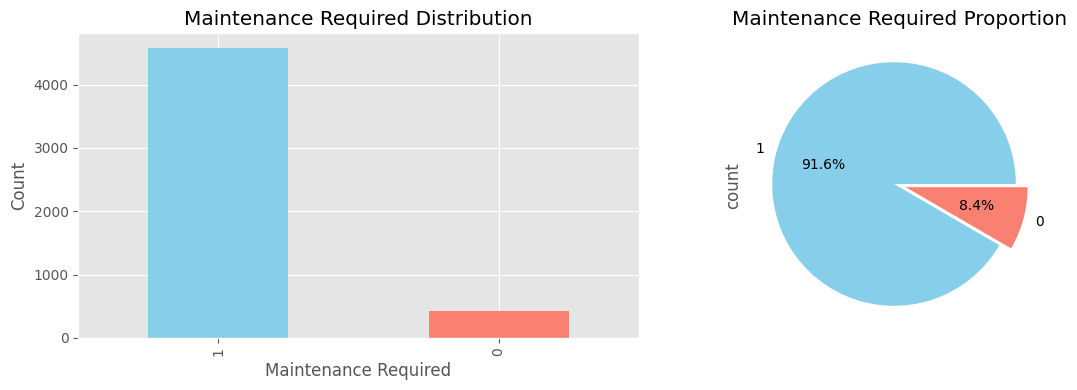

DATA CLEANING PROCESS
Duplicates removed: 0

Missing Values Before Cleaning:
No missing values found

Missing Values After Cleaning:
No missing values found

Timestamp converted to datetime features
Terrain types: {'flat': np.int64(0), 'hilly': np.int64(1), 'mountainous': np.int64(2)}

Outlier Analysis (Before Capping):
extreme_weather_event    1018
surface_humidity            0
surface_temperature         0
crack_density               0
pothole_depth               0
roughness_index             0
precipitation_rate          0
wind_speed                  0
solar_radiation             0
heavy_vehicle_ratio         0
dtype: int64

CLEANED DATASET INFO
Shape: (5000, 24)

Columns: ['road_id', 'surface_temperature', 'surface_humidity', 'precipitation_rate', 'crack_density', 'pothole_depth', 'roughness_index', 'wind_speed', 'solar_radiation', 'vehicle_count', 'heavy_vehicle_ratio', 'maintenance_frequency', 'maintenance_cost', 'location_lat', 'location_lon', 'terrain_type', 'extreme_weather_ev

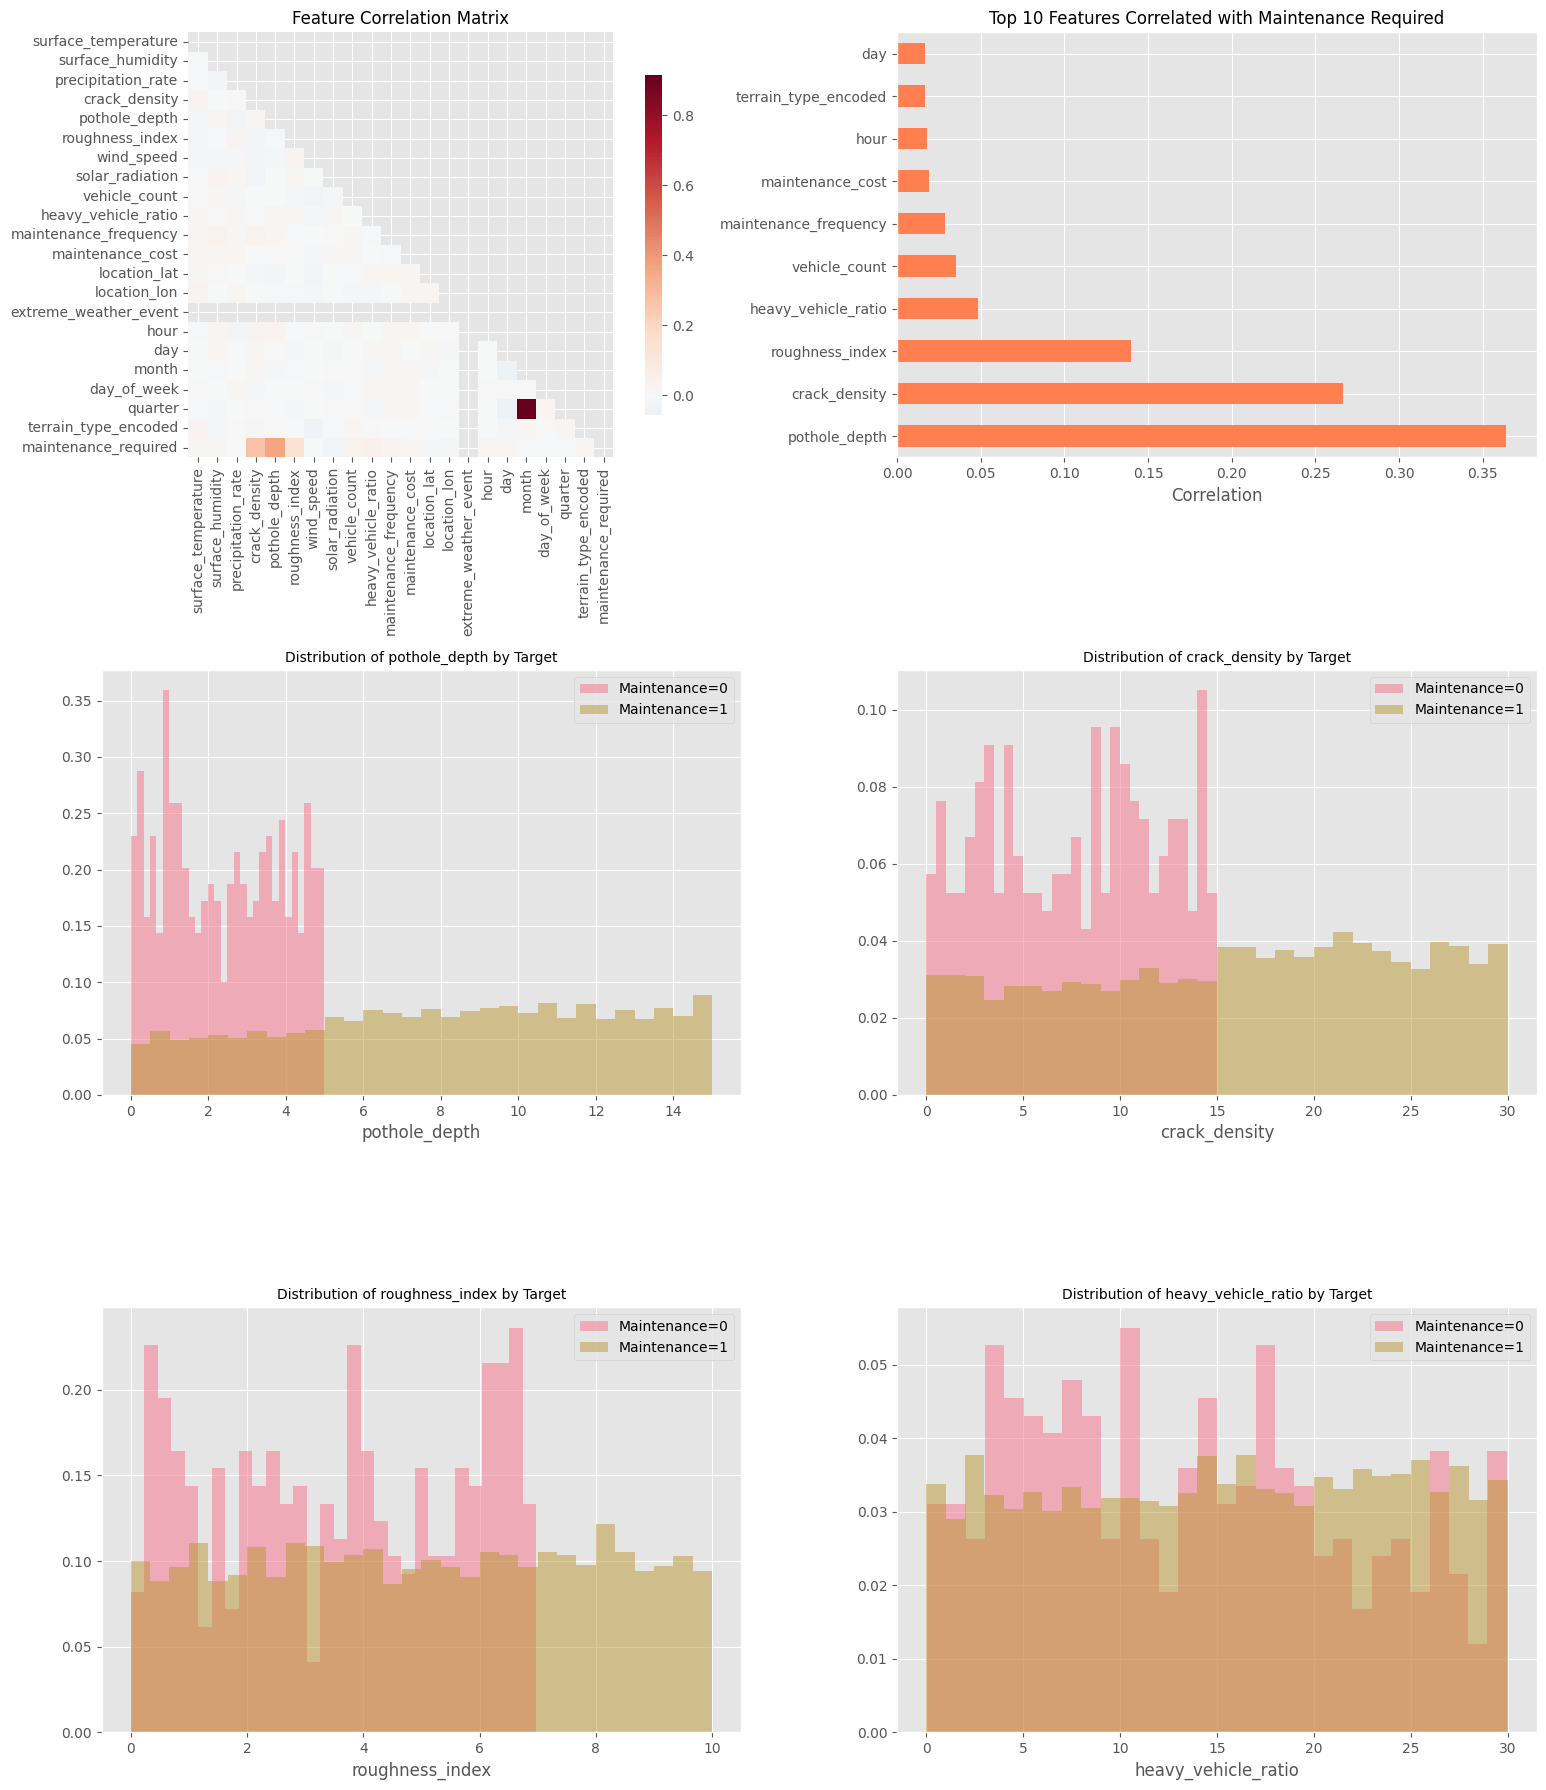

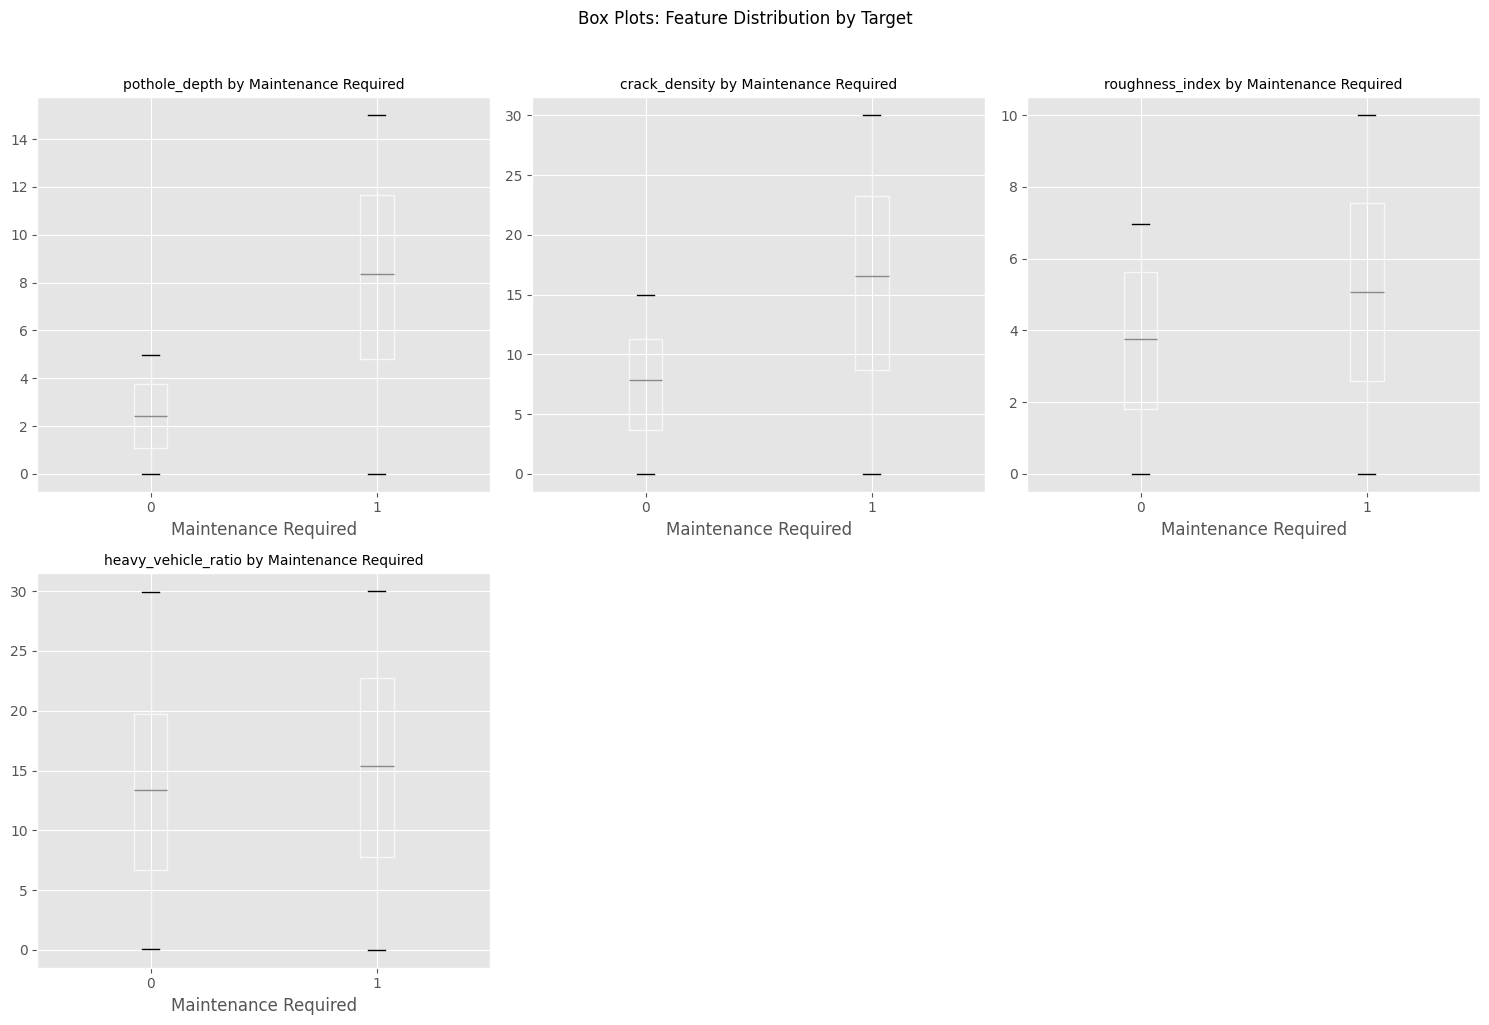

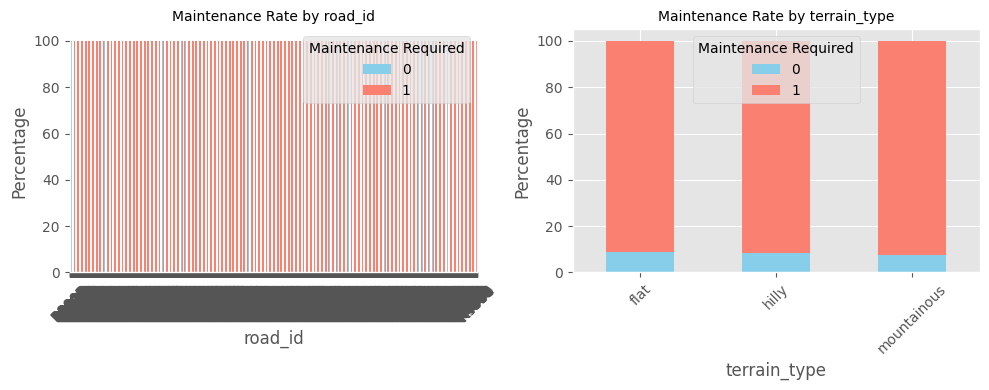

FEATURE ENGINEERING
Features created: 24 new features
Total features now: 48
DATA PREPARATION FOR MODELING
Feature matrix shape: (5000, 44)
Target vector shape: (5000,)

Target distribution:
maintenance_required
1    4581
0     419
Name: count, dtype: int64

Train set: (4000, 44)
Test set: (1000, 44)

Dropping constant columns: ['extreme_weather_event', 'crack_density_std']

Features after scaling: 42
✓ Data preparation complete. No NaN values remaining.
HANDLING CLASS IMBALANCE
Original class distribution: {1: 3665, 0: 335}
Resampled class distribution: {1: 3665, 0: 3665}
Resampled shape: (7330, 42)
MODEL TRAINING AND EVALUATION

----------------------------------------
Training Logistic Regression...
Accuracy: 0.9100
Precision: 0.9928
Recall: 0.9083
F1 Score: 0.9487
AUC-ROC: 0.9728

----------------------------------------
Training Decision Tree...
Accuracy: 0.9740
Precision: 0.9933
Recall: 0.9782
F1 Score: 0.9857
AUC-ROC: 0.9583

----------------------------------------
Training Ran

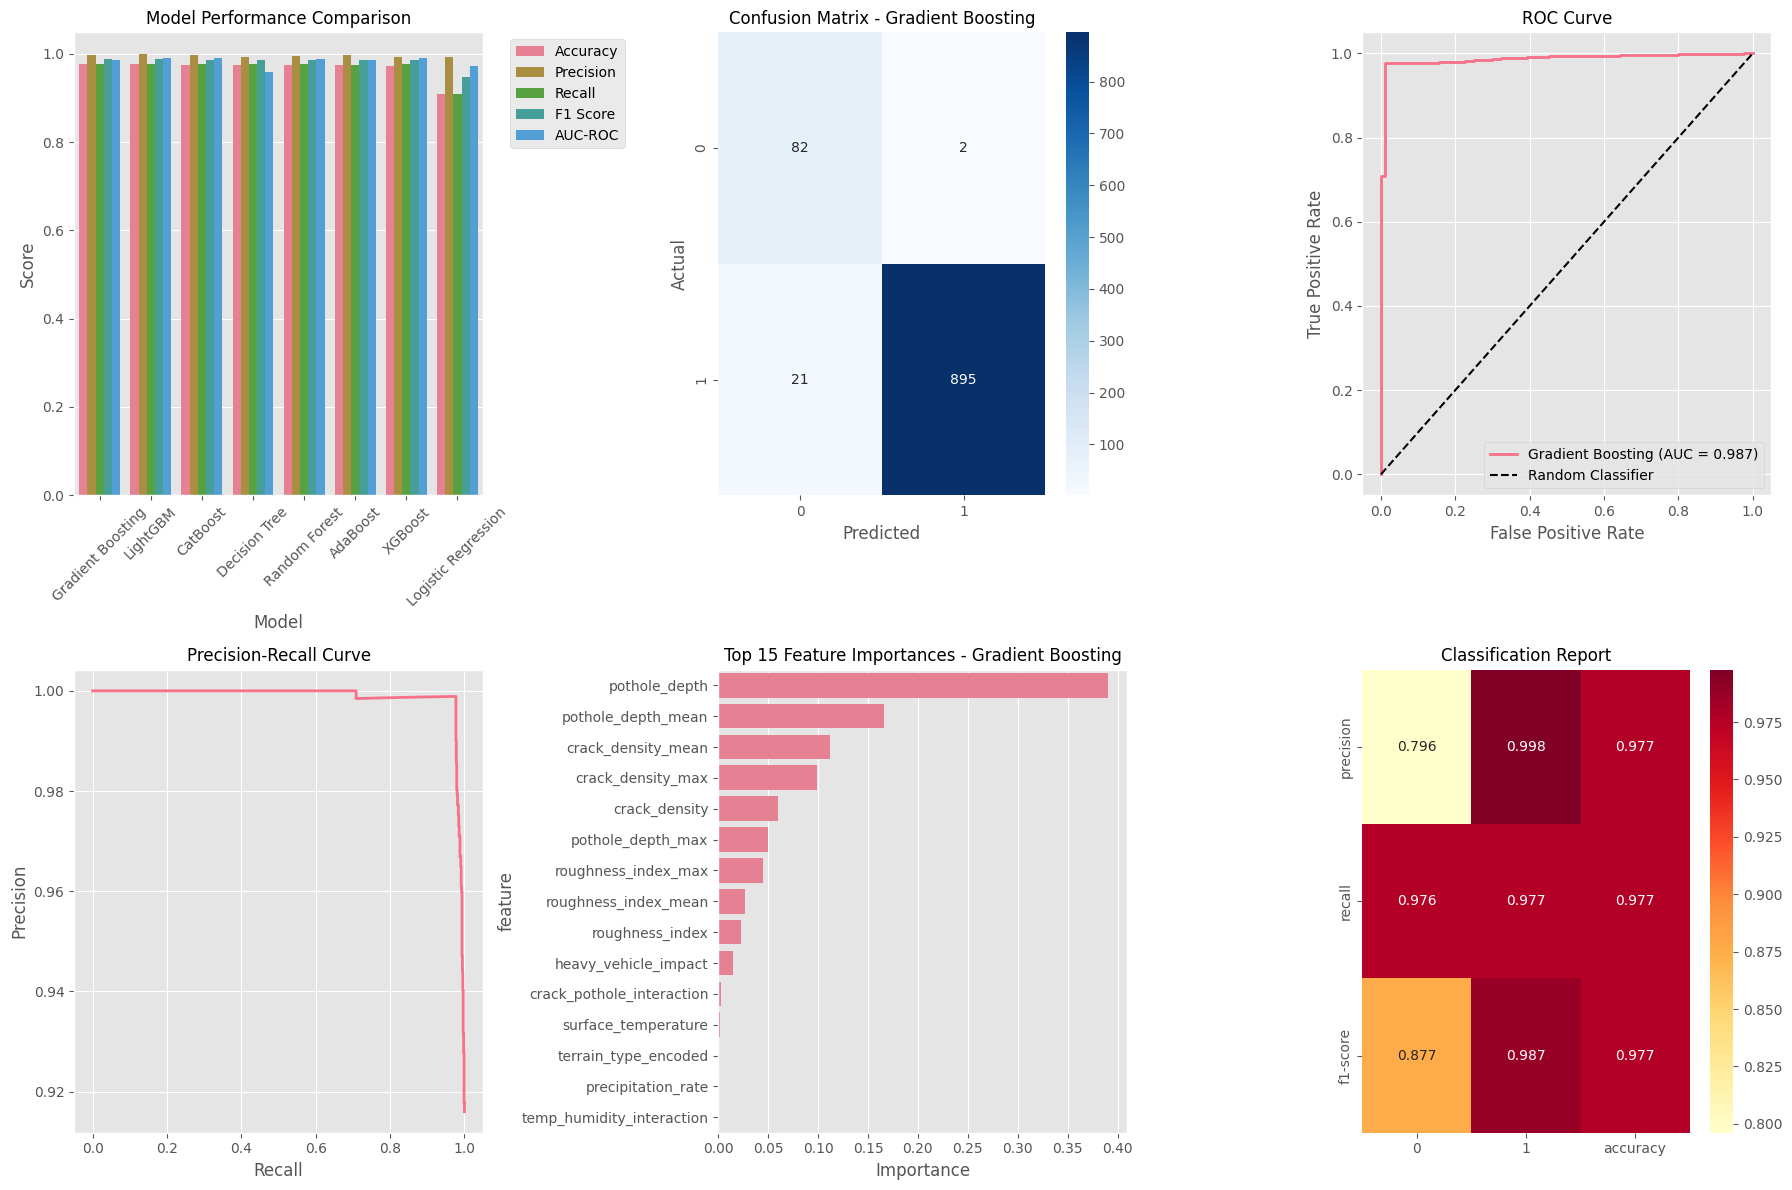

HYPERPARAMETER TUNING FOR Gradient Boosting

Starting Grid Search for Gradient Boosting...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best cross-validation F1 score: 0.9844

Test set performance:
F1 Score: 0.9857
AUC-ROC: 0.9859
SHAP ANALYSIS FOR MODEL INTERPRETABILITY


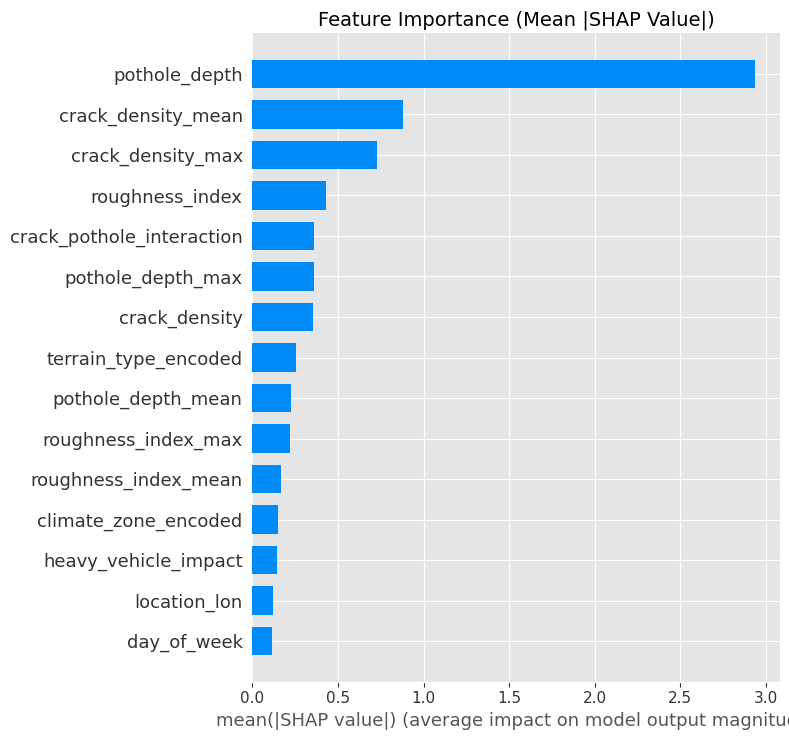

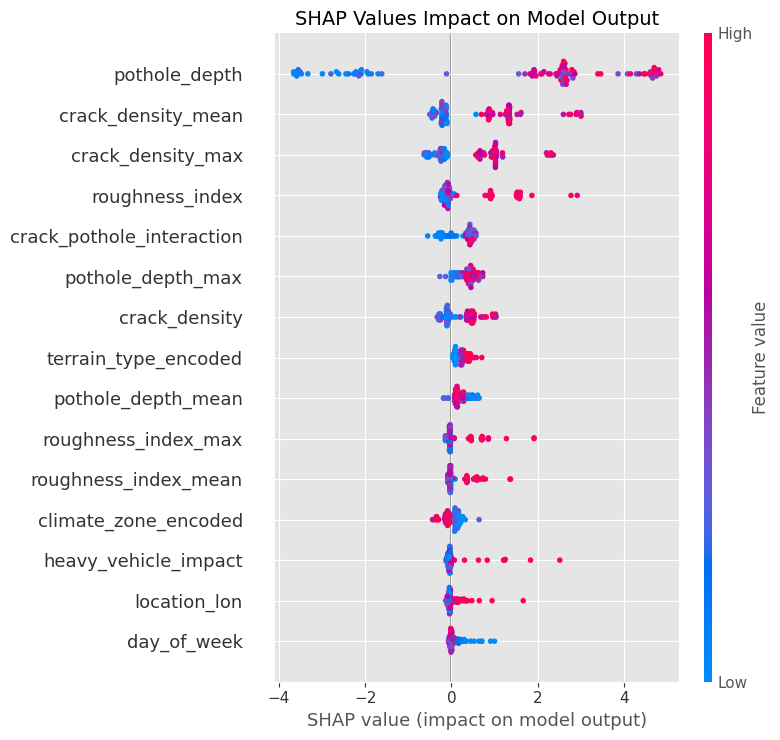

SHAP analysis completed successfully!
FINAL MODEL EVALUATION

Model: Gradient Boosting

Performance Metrics:
Accuracy:  0.9740
Precision: 0.9944
Recall:    0.9771
F1 Score:  0.9857
AUC-ROC:   0.9859

Classification Report:
                      precision    recall  f1-score   support

      No Maintenance       0.79      0.94      0.86        84
Maintenance Required       0.99      0.98      0.99       916

            accuracy                           0.97      1000
           macro avg       0.89      0.96      0.92      1000
        weighted avg       0.98      0.97      0.98      1000


Top 10 Most Important Features:
pothole_depth                  : 0.4478
crack_density_mean             : 0.1235
crack_density_max              : 0.1163
pothole_depth_mean             : 0.0728
pothole_depth_max              : 0.0714
roughness_index_max            : 0.0429
crack_density                  : 0.0287
roughness_index_mean           : 0.0271
roughness_index                : 0.0245
heavy_veh

In [6]:
# -*- coding: utf-8 -*-
"""Road_Maintenance_Prediction.ipynb

Automatically generated by Colaboratory.

# Road Maintenance Prediction Model
## Data Cleaning and Machine Learning Pipeline
"""

# Install all required packages
!pip install -q xgboost lightgbm catboost shap imbalanced-learn

print("=" * 60)
print("SETUP: Installing required packages...")
print("=" * 60)

"""## 0. File Upload and Setup"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from google.colab import files
import io
warnings.filterwarnings('ignore')

# Check if file exists, if not, prompt for upload
if not os.path.exists('climate_resilient_road_maintenance.csv'):
    print("\n" + "=" * 60)
    print("FILE UPLOAD REQUIRED")
    print("=" * 60)
    print("Please upload the 'climate_resilient_road_maintenance.csv' file")
    uploaded = files.upload()

    # Get the uploaded filename
    for filename in uploaded.keys():
        print(f"\nUploaded: {filename}")
        df = pd.read_csv(io.BytesIO(uploaded[filename]))
else:
    print("\nFile found. Loading...")
    df = pd.read_csv('climate_resilient_road_maintenance.csv')

"""## 1. Import Libraries"""

# Data preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             precision_recall_curve, roc_curve)

# Handling imbalance
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# Feature importance
import shap

# Set style
plt.style.use('ggplot')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

"""## 2. Load and Initial Data Exploration"""

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nBasic Statistics:\n{df.describe().T}")

# Check target variable distribution
print("\n" + "=" * 60)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 60)
print(df['maintenance_required'].value_counts())
print(f"\nPercentage:\n{df['maintenance_required'].value_counts(normalize=True) * 100}")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['maintenance_required'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Maintenance Required Distribution')
axes[0].set_xlabel('Maintenance Required')
axes[0].set_ylabel('Count')

df['maintenance_required'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                               colors=['skyblue', 'salmon'], explode=(0.05, 0.05))
axes[1].set_title('Maintenance Required Proportion')
plt.tight_layout()
plt.show()

"""## 3. Data Cleaning"""

def clean_road_data(df):
    """
    Comprehensive data cleaning function
    """
    df_clean = df.copy()

    print("=" * 60)
    print("DATA CLEANING PROCESS")
    print("=" * 60)

    # 1. Check for duplicates
    initial_shape = df_clean.shape
    df_clean = df_clean.drop_duplicates()
    print(f"Duplicates removed: {initial_shape[0] - df_clean.shape[0]}")

    # 2. Handle missing values
    print("\nMissing Values Before Cleaning:")
    missing_before = df_clean.isnull().sum()
    print(missing_before[missing_before > 0] if any(missing_before > 0) else "No missing values found")

    # For numerical columns: fill with median
    numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    if 'maintenance_required' in numerical_cols:
        numerical_cols.remove('maintenance_required')

    for col in numerical_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

    # For categorical columns: fill with mode
    categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
    for col in categorical_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'Unknown', inplace=True)

    print("\nMissing Values After Cleaning:")
    missing_after = df_clean.isnull().sum()
    print(missing_after[missing_after > 0] if any(missing_after > 0) else "No missing values found")

    # 3. Handle infinite values
    for col in numerical_cols:
        df_clean[col] = df_clean[col].replace([np.inf, -np.inf], np.nan)
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

    # 4. Convert timestamp to datetime and extract features
    if 'timestamp' in df_clean.columns:
        df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
        df_clean['hour'] = df_clean['timestamp'].dt.hour
        df_clean['day'] = df_clean['timestamp'].dt.day
        df_clean['month'] = df_clean['timestamp'].dt.month
        df_clean['day_of_week'] = df_clean['timestamp'].dt.dayofweek
        df_clean['quarter'] = df_clean['timestamp'].dt.quarter

        # Drop original timestamp
        df_clean.drop('timestamp', axis=1, inplace=True)
        print("\nTimestamp converted to datetime features")

    # 5. Encode categorical variables
    if 'terrain_type' in df_clean.columns:
        le_terrain = LabelEncoder()
        df_clean['terrain_type_encoded'] = le_terrain.fit_transform(df_clean['terrain_type'].fillna('unknown'))
        print(f"Terrain types: {dict(zip(le_terrain.classes_, le_terrain.transform(le_terrain.classes_)))}")

    # 6. Outlier detection and capping
    print("\nOutlier Analysis (Before Capping):")
    outlier_counts = {}
    for col in numerical_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)].shape[0]
        outlier_counts[col] = outliers

        # Cap outliers
        df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)

    outlier_series = pd.Series(outlier_counts).sort_values(ascending=False)
    if not outlier_series.empty:
        print(outlier_series.head(10))
    else:
        print("No outliers found")

    return df_clean, le_terrain if 'terrain_type' in df_clean.columns else None

# Apply cleaning
df_cleaned, terrain_encoder = clean_road_data(df)

print("\n" + "=" * 60)
print("CLEANED DATASET INFO")
print("=" * 60)
print(f"Shape: {df_cleaned.shape}")
print(f"\nColumns: {df_cleaned.columns.tolist()}")
print(f"\nData Types:\n{df_cleaned.dtypes}")

# Final check for any remaining NaN values
print("\n" + "=" * 60)
print("FINAL CHECK FOR NaN VALUES")
print("=" * 60)
nan_count = df_cleaned.isnull().sum().sum()
if nan_count > 0:
    print(f"WARNING: {nan_count} NaN values still present!")
    print(df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])
    # Force fill any remaining NaNs
    df_cleaned = df_cleaned.fillna(df_cleaned.median(numeric_only=True))
    print("All NaNs filled with median values.")
else:
    print("✓ No NaN values found. Data is clean!")

"""## 4. Exploratory Data Analysis (EDA)"""

def perform_eda(df):
    """
    Comprehensive EDA function
    """
    print("=" * 60)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 60)

    # Separate features and target
    X = df.drop('maintenance_required', axis=1)
    y = df['maintenance_required']

    numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

    print(f"Numerical features: {len(numerical_cols)}")
    print(f"Categorical features: {len(categorical_cols)}")

    # 1. Correlation Matrix
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))

    # Correlation heatmap
    corr_matrix = df[numerical_cols + ['maintenance_required']].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=False, fmt='.2f', cmap='RdBu_r',
                center=0, square=True, ax=axes[0, 0], cbar_kws={"shrink": 0.8})
    axes[0, 0].set_title('Feature Correlation Matrix', fontsize=12)

    # Top correlations with target
    target_corr = corr_matrix['maintenance_required'].drop('maintenance_required').sort_values(ascending=False)
    if not target_corr.empty:
        target_corr.head(10).plot(kind='barh', ax=axes[0, 1], color='coral')
        axes[0, 1].set_title('Top 10 Features Correlated with Maintenance Required', fontsize=12)
        axes[0, 1].set_xlabel('Correlation')

    # 2. Distribution of numerical features by target
    top_features = target_corr.head(4).index.tolist() if len(target_corr) >= 4 else target_corr.index.tolist()
    for i, feature in enumerate(top_features):
        if i >= 4:  # Ensure we don't exceed subplot grid
            break
        row, col = (i // 2) + 1, i % 2
        for target_val in [0, 1]:
            subset = df[df['maintenance_required'] == target_val][feature]
            if len(subset) > 0:
                axes[row, col].hist(subset, bins=30, alpha=0.5, label=f'Maintenance={target_val}', density=True)
        axes[row, col].set_title(f'Distribution of {feature} by Target', fontsize=10)
        axes[row, col].legend()
        axes[row, col].set_xlabel(feature)

    plt.tight_layout()
    plt.show()

    # 3. Box plots for key features
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, feature in enumerate(top_features[:6]):
        if i < len(axes):
            df.boxplot(column=feature, by='maintenance_required', ax=axes[i])
            axes[i].set_title(f'{feature} by Maintenance Required', fontsize=10)
            axes[i].set_xlabel('Maintenance Required')

    # Hide any unused subplots
    for i in range(len(top_features[:6]), len(axes)):
        axes[i].set_visible(False)

    plt.suptitle('Box Plots: Feature Distribution by Target', y=1.02)
    plt.tight_layout()
    plt.show()

    # 4. Categorical feature analysis
    if categorical_cols:
        fig, axes = plt.subplots(1, len(categorical_cols), figsize=(5*len(categorical_cols), 4))
        if len(categorical_cols) == 1:
            axes = [axes]

        for i, col in enumerate(categorical_cols):
            if col in df.columns:
                ct = pd.crosstab(df[col], df['maintenance_required'], normalize='index') * 100
                ct.plot(kind='bar', stacked=True, ax=axes[i], color=['skyblue', 'salmon'])
                axes[i].set_title(f'Maintenance Rate by {col}', fontsize=10)
                axes[i].set_ylabel('Percentage')
                axes[i].legend(title='Maintenance Required')
                axes[i].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

    return target_corr

# Perform EDA
target_correlations = perform_eda(df_cleaned)

"""## 5. Feature Engineering"""

def create_features(df):
    """
    Create new features based on domain knowledge
    """
    df_fe = df.copy()

    print("=" * 60)
    print("FEATURE ENGINEERING")
    print("=" * 60)

    # 1. Road condition indices
    df_fe['crack_pothole_interaction'] = df_fe['crack_density'] * df_fe['pothole_depth']
    df_fe['roughness_condition'] = df_fe['roughness_index'] * df_fe['crack_density']

    # 2. Weather-related features
    df_fe['temp_humidity_interaction'] = df_fe['surface_temperature'] * df_fe['surface_humidity'] / 100
    df_fe['precipitation_wind'] = df_fe['precipitation_rate'] * df_fe['wind_speed']

    # 3. Traffic-related features
    df_fe['heavy_vehicle_impact'] = df_fe['vehicle_count'] * df_fe['heavy_vehicle_ratio'] / 100
    df_fe['traffic_density'] = df_fe['vehicle_count'] / (df_fe['wind_speed'] + 1)  # Avoid division by zero

    # 4. Location-based features (if coordinates exist)
    if 'location_lat' in df_fe.columns and 'location_lon' in df_fe.columns:
        # Distance from equator (absolute latitude)
        df_fe['abs_latitude'] = np.abs(df_fe['location_lat'])

        # Create climate zones based on latitude - FIXED: avoid categorical issues
        df_fe['climate_zone'] = pd.cut(df_fe['abs_latitude'],
                                       bins=[0, 23.5, 35, 45, 66.5, 90],
                                       labels=['Tropical', 'Subtropical', 'Temperate', 'Subpolar', 'Polar'])

        # Convert to string to avoid categorical issues
        df_fe['climate_zone'] = df_fe['climate_zone'].astype(str)

        # Encode climate zone
        le_zone = LabelEncoder()
        df_fe['climate_zone_encoded'] = le_zone.fit_transform(df_fe['climate_zone'])

    # 5. Time-based features
    if all(col in df_fe.columns for col in ['hour', 'day', 'month']):
        # Cyclical encoding for time
        df_fe['hour_sin'] = np.sin(2 * np.pi * df_fe['hour'] / 24)
        df_fe['hour_cos'] = np.cos(2 * np.pi * df_fe['hour'] / 24)
        df_fe['month_sin'] = np.sin(2 * np.pi * df_fe['month'] / 12)
        df_fe['month_cos'] = np.cos(2 * np.pi * df_fe['month'] / 12)

    # 6. Maintenance history features
    if 'maintenance_frequency' in df_fe.columns:
        df_fe['recent_maintenance'] = (df_fe['maintenance_frequency'] > 0).astype(int)
        df_fe['maintenance_cost_per_event'] = df_fe['maintenance_cost'] / (df_fe['maintenance_frequency'] + 1)

    # 7. Rolling averages - Group by road_id and create aggregated features
    if 'road_id' in df_fe.columns:
        road_stats = df_fe.groupby('road_id').agg({
            'crack_density': ['mean', 'std', 'max'],
            'pothole_depth': ['mean', 'max'],
            'roughness_index': ['mean', 'max'],
            'maintenance_frequency': ['mean', 'sum']
        }).round(2)

        # Flatten column names
        road_stats.columns = ['_'.join(col).strip() for col in road_stats.columns.values]
        road_stats = road_stats.reset_index()

        # Merge back
        df_fe = df_fe.merge(road_stats, on='road_id', how='left')

    # 8. Fill any NaN created by feature engineering
    df_fe = df_fe.fillna(0)

    print(f"Features created: {len(df_fe.columns) - len(df.columns)} new features")
    print(f"Total features now: {len(df_fe.columns)}")

    return df_fe

# Apply feature engineering
df_fe = create_features(df_cleaned)

"""## 6. Prepare Data for Modeling"""

def prepare_data_for_modeling(df, target_col='maintenance_required'):
    """
    Prepare data for machine learning models
    """
    print("=" * 60)
    print("DATA PREPARATION FOR MODELING")
    print("=" * 60)

    # Identify columns to drop
    cols_to_drop = [target_col]
    drop_candidates = ['road_id', 'terrain_type', 'climate_zone']
    for col in drop_candidates:
        if col in df.columns:
            cols_to_drop.append(col)

    # Separate features and target
    X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
    y = df[target_col]

    print(f"Feature matrix shape: {X.shape}")
    print(f"Target vector shape: {y.shape}")
    print(f"\nTarget distribution:\n{y.value_counts()}")

    # Check for NaN values in X and fill them
    nan_in_X = X.isnull().sum().sum()
    if nan_in_X > 0:
        print(f"\nWARNING: {nan_in_X} NaN values found in features!")
        print("Filling with 0...")
        X = X.fillna(0)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\nTrain set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")

    # Get numerical columns for scaling
    numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    # Remove any constant columns
    constant_cols = []
    for col in numerical_cols:
        if col in X_train.columns and X_train[col].nunique() == 1:
            constant_cols.append(col)

    if constant_cols:
        print(f"\nDropping constant columns: {constant_cols}")
        X_train = X_train.drop(columns=constant_cols)
        X_test = X_test.drop(columns=constant_cols)
        numerical_cols = [col for col in numerical_cols if col not in constant_cols]

    # Scale numerical features
    scaler = RobustScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    if numerical_cols:
        X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
        X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

    print(f"\nFeatures after scaling: {X_train_scaled.shape[1]}")

    # Final check for NaN values in scaled data
    if X_train_scaled.isnull().sum().sum() > 0:
        print("WARNING: NaN values still present! Filling with 0...")
        X_train_scaled = X_train_scaled.fillna(0)
        X_test_scaled = X_test_scaled.fillna(0)

    print("✓ Data preparation complete. No NaN values remaining.")

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, numerical_cols

# Prepare data
X_train, X_test, y_train, y_test, scaler, numerical_features = prepare_data_for_modeling(df_fe)

"""## 7. Handle Class Imbalance"""

def handle_class_imbalance(X_train, y_train, method='smote'):
    """
    Handle class imbalance using various techniques
    """
    print("=" * 60)
    print("HANDLING CLASS IMBALANCE")
    print("=" * 60)

    print(f"Original class distribution: {pd.Series(y_train).value_counts().to_dict()}")

    # Double-check for NaN values before SMOTE
    if X_train.isnull().sum().sum() > 0:
        print("WARNING: NaN values found before SMOTE! Filling with 0...")
        X_train = X_train.fillna(0)

    try:
        if method == 'smote':
            sampler = SMOTE(random_state=42)
            X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
        elif method == 'adasyn':
            sampler = ADASYN(random_state=42)
            X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
        elif method == 'smote_tomek':
            sampler = SMOTETomek(random_state=42)
            X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
        else:
            return X_train, y_train

        print(f"Resampled class distribution: {pd.Series(y_resampled).value_counts().to_dict()}")
        print(f"Resampled shape: {X_resampled.shape}")

        return X_resampled, y_resampled

    except Exception as e:
        print(f"Error in SMOTE: {e}")
        print("Proceeding with original data...")
        return X_train, y_train

# Apply SMOTE
X_train_resampled, y_train_resampled = handle_class_imbalance(X_train, y_train, method='smote')

"""## 8. Model Training and Evaluation"""

def train_evaluate_models(X_train, y_train, X_test, y_test):
    """
    Train multiple models and evaluate performance
    """
    print("=" * 60)
    print("MODEL TRAINING AND EVALUATION")
    print("=" * 60)

    # Calculate scale_pos_weight for XGBoost
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]) if len(y_train[y_train==1]) > 0 else 1

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10),
        'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
        'AdaBoost': AdaBoostClassifier(random_state=42, n_estimators=100),
        'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss',
                                 scale_pos_weight=scale_pos_weight),
        'LightGBM': LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced'),
        'CatBoost': CatBoostClassifier(random_state=42, verbose=0, auto_class_weights='Balanced')
    }

    results = []
    trained_models = {}
    best_model = None
    best_score = 0
    best_model_name = None

    for name, model in models.items():
        print(f"\n{'-'*40}")
        print(f"Training {name}...")

        try:
            # Train model
            model.fit(X_train, y_train)
            trained_models[name] = model

            # Predictions
            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

            # Metrics
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, zero_division=0)
            recall = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)

            if y_pred_proba is not None:
                auc = roc_auc_score(y_test, y_pred_proba)
            else:
                auc = 0

            # Store results
            results.append({
                'Model': name,
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1 Score': f1,
                'AUC-ROC': auc
            })

            print(f"Accuracy: {accuracy:.4f}")
            print(f"Precision: {precision:.4f}")
            print(f"Recall: {recall:.4f}")
            print(f"F1 Score: {f1:.4f}")
            print(f"AUC-ROC: {auc:.4f}")

            # Track best model based on F1 score
            if f1 > best_score:
                best_score = f1
                best_model = model
                best_model_name = name

        except Exception as e:
            print(f"Error training {name}: {e}")
            continue

    # Create results DataFrame
    if results:
        results_df = pd.DataFrame(results)
        results_df = results_df.sort_values('F1 Score', ascending=False)

        print("\n" + "=" * 60)
        print("MODEL COMPARISON SUMMARY")
        print("=" * 60)
        print(results_df.to_string(index=False))
    else:
        results_df = pd.DataFrame()
        print("No models were successfully trained!")

    return results_df, best_model, best_model_name, trained_models

# Train models
results_df, best_model, best_model_name, trained_models = train_evaluate_models(
    X_train_resampled, y_train_resampled, X_test, y_test
)

"""## 9. Visualize Model Performance"""

def visualize_model_performance(results_df, X_test, y_test, best_model, best_model_name):
    """
    Visualize model performance metrics
    """
    print("=" * 60)
    print("VISUALIZING MODEL PERFORMANCE")
    print("=" * 60)

    if results_df.empty or best_model is None:
        print("No models to visualize!")
        return best_model

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 1. Model comparison bar plot
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
    results_melted = results_df.melt(id_vars=['Model'], value_vars=metrics,
                                      var_name='Metric', value_name='Score')

    sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', ax=axes[0, 0])
    axes[0, 0].set_title('Model Performance Comparison', fontsize=12)
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # 2. Confusion Matrix for best model
    y_pred_best = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_best)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
    axes[0, 1].set_title(f'Confusion Matrix - {best_model_name}', fontsize=12)
    axes[0, 1].set_xlabel('Predicted')
    axes[0, 1].set_ylabel('Actual')

    # 3. ROC Curve
    if hasattr(best_model, 'predict_proba'):
        y_pred_proba = best_model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc = roc_auc_score(y_test, y_pred_proba)

        axes[0, 2].plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc:.3f})', linewidth=2)
        axes[0, 2].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
        axes[0, 2].set_xlabel('False Positive Rate')
        axes[0, 2].set_ylabel('True Positive Rate')
        axes[0, 2].set_title('ROC Curve', fontsize=12)
        axes[0, 2].legend(loc='lower right')
        axes[0, 2].grid(True)

    # 4. Precision-Recall Curve
    if hasattr(best_model, 'predict_proba'):
        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
        axes[1, 0].plot(recall_vals, precision_vals, linewidth=2)
        axes[1, 0].set_xlabel('Recall')
        axes[1, 0].set_ylabel('Precision')
        axes[1, 0].set_title('Precision-Recall Curve', fontsize=12)
        axes[1, 0].grid(True)

    # 5. Feature Importance (for tree-based models)
    if hasattr(best_model, 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'feature': X_test.columns,
            'importance': best_model.feature_importances_
        }).sort_values('importance', ascending=False).head(15)

        if not feature_importance.empty:
            sns.barplot(data=feature_importance, y='feature', x='importance', ax=axes[1, 1])
            axes[1, 1].set_title(f'Top 15 Feature Importances - {best_model_name}', fontsize=12)
            axes[1, 1].set_xlabel('Importance')

    # 6. Classification report as heatmap
    report = classification_report(y_test, y_pred_best, output_dict=True)
    report_df = pd.DataFrame(report).iloc[:-1, :3]  # Remove support row, take first 3 columns

    sns.heatmap(report_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1, 2])
    axes[1, 2].set_title('Classification Report', fontsize=12)

    plt.tight_layout()
    plt.show()

    return best_model

# Visualize performance
if best_model is not None:
    best_model = visualize_model_performance(results_df, X_test, y_test, best_model, best_model_name)
else:
    print("No best model found. Skipping visualization.")

"""## 10. Hyperparameter Tuning for Best Model"""

def tune_best_model(X_train, y_train, X_test, y_test, best_model_name, trained_models):
    """
    Perform hyperparameter tuning for the best performing model
    """
    print("=" * 60)
    print(f"HYPERPARAMETER TUNING FOR {best_model_name}")
    print("=" * 60)

    if best_model_name is None:
        print("No best model to tune.")
        return None, None

    # Define parameter grids for different models
    param_grids = {
        'Random Forest': {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        },
        'XGBoost': {
            'n_estimators': [100, 200],
            'max_depth': [3, 6],
            'learning_rate': [0.01, 0.1],
            'subsample': [0.8, 1.0]
        },
        'LightGBM': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, -1],
            'learning_rate': [0.01, 0.1],
            'num_leaves': [31, 50]
        },
        'Gradient Boosting': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5],
            'learning_rate': [0.01, 0.1]
        },
        'Decision Tree': {
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [2, 5, 10]
        },
        'CatBoost': {
            'iterations': [100, 200],
            'depth': [4, 6],
            'learning_rate': [0.01, 0.1]
        }
    }

    # Find matching model in param_grids
    matching_key = None
    for key in param_grids.keys():
        if key in best_model_name:
            matching_key = key
            break

    if matching_key is None:
        print(f"No tuning defined for {best_model_name}. Using default parameters.")
        return trained_models.get(best_model_name), None

    # Get the model from trained_models
    model = trained_models.get(best_model_name)
    if model is None:
        print(f"Model {best_model_name} not found in trained models.")
        return None, None

    # Perform grid search with cross-validation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # Using 3 folds for speed

    grid_search = GridSearchCV(
        estimator=model.__class__(**model.get_params()),
        param_grid=param_grids[matching_key],
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    print(f"\nStarting Grid Search for {best_model_name}...")
    grid_search.fit(X_train, y_train)

    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best cross-validation F1 score: {grid_search.best_score_:.4f}")

    # Evaluate on test set
    best_tuned_model = grid_search.best_estimator_
    y_pred = best_tuned_model.predict(X_test)
    y_pred_proba = best_tuned_model.predict_proba(X_test)[:, 1]

    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"\nTest set performance:")
    print(f"F1 Score: {test_f1:.4f}")
    print(f"AUC-ROC: {test_auc:.4f}")

    return best_tuned_model, grid_search.best_params_

# Tune the best model
if best_model_name is not None:
    best_tuned_model, best_params = tune_best_model(
        X_train_resampled, y_train_resampled, X_test, y_test, best_model_name, trained_models
    )
    if best_tuned_model is not None:
        best_model = best_tuned_model
else:
    best_params = None

"""## 11. SHAP Analysis for Model Interpretability"""

def shap_analysis(model, X_train, X_test, feature_names):
    """
    Perform SHAP analysis to understand feature importance
    """
    print("=" * 60)
    print("SHAP ANALYSIS FOR MODEL INTERPRETABILITY")
    print("=" * 60)

    if model is None:
        print("No model available for SHAP analysis.")
        return

    try:
        # Use a sample for SHAP if dataset is large
        X_sample = X_test.sample(min(100, len(X_test)), random_state=42)

        # Create SHAP explainer based on model type
        if hasattr(model, 'get_booster'):  # XGBoost
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)
        elif hasattr(model, 'booster_'):  # LightGBM
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)
        elif isinstance(model, (RandomForestClassifier, GradientBoostingClassifier,
                                AdaBoostClassifier, DecisionTreeClassifier)):
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)
        else:
            # For non-tree models, use KernelExplainer (slower)
            explainer = shap.KernelExplainer(model.predict_proba, X_train.sample(50, random_state=42))
            shap_values = explainer.shap_values(X_sample)[1]  # For class 1

        # Summary plot - Bar
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                         plot_type="bar", show=False, max_display=15)
        plt.title('Feature Importance (Mean |SHAP Value|)', fontsize=14)
        plt.tight_layout()
        plt.show()

        # Summary plot - Beeswarm
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                         show=False, max_display=15)
        plt.title('SHAP Values Impact on Model Output', fontsize=14)
        plt.tight_layout()
        plt.show()

        print("SHAP analysis completed successfully!")

    except Exception as e:
        print(f"Error in SHAP analysis: {e}")
        print("Skipping SHAP analysis...")

# Perform SHAP analysis for the best model
if best_model is not None:
    feature_names = X_test.columns.tolist()
    shap_analysis(best_model, X_train_resampled, X_test, feature_names)

"""## 12. Final Model Evaluation and Summary"""

def final_model_evaluation(model, X_test, y_test, feature_names, best_model_name):
    """
    Final comprehensive model evaluation
    """
    print("=" * 60)
    print("FINAL MODEL EVALUATION")
    print("=" * 60)

    if model is None:
        print("No model available for evaluation.")
        return None

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate all metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    print(f"\nModel: {best_model_name}")
    print(f"\nPerformance Metrics:")
    print(f"{'='*40}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")

    print(f"\nClassification Report:")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred, target_names=['No Maintenance', 'Maintenance Required']))

    # Feature importance (if available)
    importance_df = None
    if hasattr(model, 'feature_importances_'):
        print(f"\nTop 10 Most Important Features:")
        print(f"{'='*40}")
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=False).head(10)

        for idx, row in importance_df.iterrows():
            print(f"{row['Feature']:<30} : {row['Importance']:.4f}")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc_roc': auc,
        'model': model,
        'feature_importance': importance_df
    }

# Final evaluation
if best_model is not None:
    final_results = final_model_evaluation(best_model, X_test, y_test, feature_names, best_model_name)
else:
    final_results = None
    print("No best model available for final evaluation.")

"""## 13. Save Model and Preprocessing Objects"""

import joblib
import pickle
from datetime import datetime

def save_model_artifacts(model, scaler, feature_names, best_params, results_df, filename_prefix='road_maintenance_model'):
    """
    Save model and preprocessing objects for future use
    """
    print("=" * 60)
    print("SAVING MODEL ARTIFACTS")
    print("=" * 60)

    if model is None:
        print("No model to save.")
        return None

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Save model
    model_filename = f"{filename_prefix}_{timestamp}.pkl"
    joblib.dump(model, model_filename)
    print(f"Model saved as: {model_filename}")

    # Save scaler
    scaler_filename = f"scaler_{timestamp}.pkl"
    joblib.dump(scaler, scaler_filename)
    print(f"Scaler saved as: {scaler_filename}")

    # Save feature names
    features_filename = f"features_{timestamp}.txt"
    with open(features_filename, 'w') as f:
        for feature in feature_names:
            f.write(f"{feature}\n")
    print(f"Feature names saved as: {features_filename}")

    # Save results summary
    if results_df is not None and not results_df.empty:
        results_filename = f"results_{timestamp}.csv"
        results_df.to_csv(results_filename, index=False)
        print(f"Results saved as: {results_filename}")

    # Save best parameters
    if best_params:
        params_filename = f"best_params_{timestamp}.txt"
        with open(params_filename, 'w') as f:
            for param, value in best_params.items():
                f.write(f"{param}: {value}\n")
        print(f"Best parameters saved as: {params_filename}")

    print("\nAll artifacts saved successfully!")

    return {
        'model_file': model_filename,
        'scaler_file': scaler_filename,
        'features_file': features_filename
    }

# Save the model and artifacts
if best_model is not None:
    saved_files = save_model_artifacts(best_model, scaler, feature_names, best_params, results_df)
else:
    print("No model to save.")

"""## 14. Prediction Function for New Data"""

def predict_maintenance(model, scaler, feature_names, new_data):
    """
    Predict maintenance requirement for new road data
    """
    print("=" * 60)
    print("PREDICTING MAINTENANCE FOR NEW DATA")
    print("=" * 60)

    if model is None:
        print("No model available for prediction.")
        return None

    # Ensure new_data has the same features
    missing_features = set(feature_names) - set(new_data.columns)
    if missing_features:
        print(f"Warning: Missing features: {missing_features}")
        # Add missing features with default values (0)
        for feature in missing_features:
            new_data[feature] = 0

    # Reorder columns to match training data
    new_data = new_data[feature_names]

    # Fill any NaN values
    new_data = new_data.fillna(0)

    # Scale the data
    new_data_scaled = scaler.transform(new_data)

    # Make predictions
    predictions = model.predict(new_data_scaled)
    probabilities = model.predict_proba(new_data_scaled)

    # Create results DataFrame
    results = pd.DataFrame({
        'Prediction': predictions,
        'Prediction_Label': ['Maintenance Required' if p == 1 else 'No Maintenance' for p in predictions],
        'Probability_No_Maintenance': probabilities[:, 0],
        'Probability_Maintenance': probabilities[:, 1]
    })

    print(f"\nPredictions for {len(new_data)} samples:")
    print(results)

    return results

# Example usage (commented out)
# if best_model is not None:
#     new_data_sample = X_test.head(5)
#     predictions = predict_maintenance(best_model, scaler, feature_names, new_data_sample)

"""## 15. Summary Report"""

def generate_summary_report(results_df, final_results, best_model_name, best_params, df):
    """
    Generate a comprehensive summary report
    """
    print("=" * 60)
    print("PROJECT SUMMARY REPORT")
    print("=" * 60)
    print("\n" + "="*60)
    print("ROAD MAINTENANCE PREDICTION MODEL")
    print("="*60)

    print(f"\nDate: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    print(f"\n{'DATASET INFORMATION':^60}")
    print("-"*60)
    print(f"Total samples: {df.shape[0]}")
    print(f"Total features: {df.shape[1] - 1} (excluding target)")
    print(f"Target distribution:")
    print(f"  - No Maintenance: {df['maintenance_required'].value_counts()[0]} ({df['maintenance_required'].value_counts(normalize=True)[0]*100:.1f}%)")
    print(f"  - Maintenance Required: {df['maintenance_required'].value_counts()[1]} ({df['maintenance_required'].value_counts(normalize=True)[1]*100:.1f}%)")

    if final_results:
        print(f"\n{'MODEL PERFORMANCE':^60}")
        print("-"*60)
        print(f"Best Model: {best_model_name}")
        print(f"\nTest Set Performance:")
        print(f"  - Accuracy:  {final_results['accuracy']:.4f}")
        print(f"  - Precision: {final_results['precision']:.4f}")
        print(f"  - Recall:    {final_results['recall']:.4f}")
        print(f"  - F1 Score:  {final_results['f1_score']:.4f}")
        print(f"  - AUC-ROC:   {final_results['auc_roc']:.4f}")

    if best_params:
        print(f"\nBest Hyperparameters:")
        for param, value in best_params.items():
            print(f"  - {param}: {value}")

    if results_df is not None and not results_df.empty:
        print(f"\n{'MODEL COMPARISON':^60}")
        print("-"*60)
        print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']].round(4).to_string(index=False))

    if final_results and final_results['feature_importance'] is not None:
        print(f"\n{'TOP 10 FEATURE IMPORTANCE':^60}")
        print("-"*60)
        for idx, row in final_results['feature_importance'].iterrows():
            print(f"  {row['Feature']:<30} : {row['Importance']:.4f}")

    print(f"\n{'='*60}")
    print("Analysis Complete!")
    print("="*60)

# Generate final summary
generate_summary_report(results_df, final_results, best_model_name, best_params, df)

print("\n" + "=" * 60)
print("NOTEBOOK EXECUTION COMPLETED SUCCESSFULLY!")
print("=" * 60)
print("\nAll analyses, model training, and evaluations are complete.")
print("The best model has been saved and can be used for future predictions.")